# Анализ NPS и драйверов клиентского опыта (English translation below)

Цель: провести анализ показателя Net Promoter Score (NPS) на основе данных клиентских опросов и определить ключевые факторы, влияющие на изменение метрики.

В рамках проекта рассчитывается общий показатель NPS, анализируется его динамика во времени и выполняется декомпозиция метрики по различным измерениям данных. Основная задача анализа — выявить сегменты пользователей и продукты, которые формируют основной негативный вклад в метрику.

Анализ проводится методом последовательной декомпозиции метрики сверху вниз (top-down driver analysis). Начиная с общего уровня NPS, исследуются различные измерения данных, включая канал взаимодействия, продукт, демографические характеристики клиентов и временную динамику. Это позволяет локализовать источники снижения клиентского опыта и определить сегменты, требующие более детального анализа.

Особое внимание уделяется различию между структурными факторами (structural drivers), характеризующими свойства пользователей, и управляемыми факторами (actionable drivers), на которые можно напрямую повлиять через изменения продукта или сервиса.

---

## Данные

В анализе используются результаты клиентского опроса, представленные в двух формах.

### 1. Исходная таблица

На уровне исходных данных каждая строка содержит распределение ответов для конкретной комбинации признаков и значения оценки.

Поля исходной таблицы:

- Month — месяц опроса  
- age_group — возрастная группа клиента  
- gender_id — пол клиента  
- survey_channel — канал взаимодействия  
- survey_product_name — продукт  
- NPS_score — оценка клиента по шкале от 0 до 10  
- Num_answers — количество ответов с данным значением оценки  

Таким образом, исходная таблица содержит распределение оценок NPS внутри каждого сегмента.

---

### 2. Агрегированная витрина данных

Из исходной таблицы строится агрегированная витрина, в которой данные суммируются на уровне сегмента.

Поля агрегированной витрины:

- Month — месяц опроса  
- survey_product_name — продукт  
- survey_channel — канал взаимодействия  
- age_group — возрастная группа клиента  
- gender_id — пол клиента  
- total_answers — общее количество ответов в сегменте  
- promoters — количество оценок 9–10  
- passives — количество оценок 7–8  
- detractors — количество оценок 0–6  
- promoters_share — доля promoters в сегменте  
- detractors_share — доля detractors в сегменте  
- NPS — рассчитанное значение NPS для сегмента  

Эта витрина используется для дальнейшей сегментации, декомпозиции и анализа вкладов.

---

## Расчёт метрики NPS

В проекте используется два способа расчёта метрики.

### 1. Расчёт NPS из исходной таблицы

На уровне исходных данных метрика рассчитывается как взвешенное среднее значение оценки NPS, где веса задаются количеством ответов (Num_answers).

Фактически это означает, что общий NPS рассчитывается как средняя оценка клиентов с учётом количества ответов для каждой оценки.

Такой расчёт используется для получения базового значения метрики и проверки общей динамики NPS.

---

### 2. Расчёт NPS в агрегированной витрине

В агрегированной витрине данные уже сгруппированы по сегментам, и внутри каждого сегмента отдельно считаются:

- promoters (оценки 9–10)  
- passives (оценки 7–8)  
- detractors (оценки 0–6)

После этого значение NPS рассчитывается по классической формуле:

$$
NPS = \frac{Promoters - Detractors}{Total} \times 100
$$

где:

- Promoters — количество оценок 9–10  
- Detractors — количество оценок 0–6  
- Total — общее количество ответов  

Этот подход используется для сегментного анализа и декомпозиции вклада различных групп клиентов в итоговую метрику.

---

## Подход к анализу

Анализ проводится в несколько этапов:

1. Расчёт базовой метрики NPS  
2. Анализ динамики NPS по месяцам  
3. Проверка гипотез о влиянии ключевых измерений:
   - канал взаимодействия
   - продукт
   - возрастная группа
   - пол клиента
   - месяц
4. Декомпозиция вклада сегментов в общий NPS  
5. Определение сегментов с максимальным негативным вкладом  
6. Детальный анализ ключевого сегмента (drill-down)  
7. Выводы и рекомендации

Такой подход позволяет последовательно сузить пространство анализа и выявить реальные драйверы изменения метрики.

---

## Основные результаты анализа

Проведённый анализ показал, что основное снижение NPS связано с каналом VoiceBot, внутри которого основной негативный вклад формирует Product_2.

Декомпозиция показала следующие ключевые результаты:

- Product_2 является главным драйвером снижения NPS в канале VoiceBot  
- На глобальном уровне фактор пола не является драйвером метрики, так как вклад мужчин и женщин в общий NPS практически симметричен  
- Однако внутри сегмента VoiceBot + Product_2 появляется выраженная асимметрия: основной негативный вклад формируют мужчины  
- Наиболее проблемные возрастные сегменты — 29–39 и 39–49 лет  
- Негативный вклад наблюдается в нескольких месяцах, что указывает на системную проблему, а не на единичный инцидент  

Таким образом, основной кандидат на root cause — взаимодействие VoiceBot и Product_2, особенно для пользователей мужского пола в возрасте 29–49 лет.

Полученные результаты позволяют сформулировать продуктовые рекомендации по улучшению пользовательского опыта и повышению NPS.

# NPS Analysis and Customer Experience Drivers

The goal is to analyze the Net Promoter Score (NPS) based on customer survey data and identify the key factors influencing changes in the metric.

Within the project, the overall NPS is calculated, its dynamics over time are analyzed, and the metric is decomposed across multiple data dimensions. The main objective is to identify customer segments and products that generate the largest negative contribution to the metric.

The analysis follows a top-down metric decomposition (driver analysis) approach. Starting from the overall NPS level, the analysis investigates multiple dimensions of the dataset, including interaction channel, product, customer demographics, and time dynamics. This allows us to localize the sources of customer experience decline and identify segments requiring deeper analysis.

Special attention is given to the distinction between structural drivers, which describe inherent customer characteristics, and actionable drivers, which can be directly influenced through product or service improvements.

---

## Data

The analysis is based on customer survey results presented in two forms.

### 1. Source table

At the source level, each row contains the distribution of responses for a specific combination of attributes and score value.

Source table fields:

- Month — survey month  
- age_group — customer age group  
- gender_id — customer gender  
- survey_channel — interaction channel  
- survey_product_name — product  
- NPS_score — customer score on a 0–10 scale  
- Num_answers — number of responses with this score  

The source table therefore contains the distribution of NPS scores within each segment.

---

### 2. Aggregated data mart

An aggregated data mart is built from the source table, where data is summarized at the segment level.

Aggregated data mart fields:

- Month — survey month  
- survey_product_name — product  
- survey_channel — interaction channel  
- age_group — customer age group  
- gender_id — customer gender  
- total_answers — total number of responses in the segment  
- promoters — number of scores 9–10  
- passives — number of scores 7–8  
- detractors — number of scores 0–6  
- promoters_share — share of promoters in the segment  
- detractors_share — share of detractors in the segment  
- NPS — calculated NPS value for the segment  

This data mart is used for segmentation, decomposition, and contribution analysis.

---

## NPS Calculation

Two approaches to NPS calculation are used in the project.

### 1. NPS calculation from the source table

At the source data level, NPS is calculated as a weighted average score, where the weights correspond to the number of responses (Num_answers) for each score value.

In practice, this means that the overall NPS reflects the average customer score weighted by the number of responses for each score.

This calculation is used to determine the baseline value of the metric and analyze overall NPS dynamics.

---

### 2. NPS calculation in the aggregated data mart

In the aggregated data mart, responses are already grouped by segment and classified into:

- promoters (scores 9–10)  
- passives (scores 7–8)  
- detractors (scores 0–6)

The NPS metric is then calculated using the standard formula:

$$
NPS = \frac{Promoters - Detractors}{Total} \times 100
$$

where:

- Promoters — number of scores 9–10  
- Detractors — number of scores 0–6  
- Total — total number of responses  

This approach is used for segmentation and contribution analysis across different customer groups.

---

## Analytical Approach

The analysis follows several steps:

1. Calculation of the baseline NPS metric
2. Analysis of NPS dynamics by month  
3. Testing hypotheses about the influence of key dimensions:
   - interaction channel
   - product
   - age group
   - gender
   - month
4. Segment contribution decomposition  
5. Identification of segments with the largest negative impact  
6. Drill-down analysis of the key segment  
7. Formulation of analytical conclusions and recommendations  

This structured approach progressively narrows the analysis space and identifies the true drivers of metric change.

---

## Key Findings

The analysis shows that the main NPS decline is associated with the VoiceBot channel, where Product_2 generates the largest negative contribution.

The decomposition revealed the following insights:

- Product_2 is the primary driver of NPS decline within the VoiceBot channel  
- At the global dataset level, gender is not a driver of the metric, since male and female contributions are roughly symmetric  
- However, within the VoiceBot + Product_2 segment, a strong asymmetry emerges: male users generate the majority of the negative contribution  
- The most problematic age groups are 29–39 and 39–49  
- The negative contribution is observed across multiple months, indicating a systemic issue rather than a one-time incident  

Overall, the main root cause candidate is the interaction between VoiceBot and Product_2, particularly for male users aged 29–49.

These insights provide the basis for targeted product improvements aimed at enhancing customer experience and increasing the NPS metric.

# **Структура анализа**

Цель анализа определить ключевые факторы, влияющие на показатель NPS, и выявить сегменты, которые формируют основной негативный вклад в метрику.

Анализ проводится по принципу декомпозиции метрики сверху вниз, начиная с общего уровня NPS и постепенно переходя к анализу потенциальных факторов и более детальной сегментации данных.

**Общая логика анализа:**

1. Общий показатель NPS\
   1.1. Помесячный NPS\
   1.2. Общий NPS за год\
   1.3. Отклонение от целевого значения NPS

2. Проверка гипотез о влиянии измерений\
   3.1. Зависимость NPS от канала взаимодействия\
   3.2. Зависимость NPS от продукта\
   3.3. Зависимость NPS от возраста клиента\
   3.4. Зависимость NPS от пола клиента\
   3.5. Зависимость NPS от месяца

3. Анализ вклада сегментов\
   4.1. Значение NPS сегмента\
   4.2. Объём ответов сегмента\
   4.3. Вклад сегмента в общий NPS

4. Сравнение сегментов\
   5.1. Определение сегмента с максимальным негативным вкладом

5. Детальный анализ максимально негативного сегмента

6. Выводы

7. Рекомендации

---

**1. Расчёт базовой метрики**

На первом этапе рассчитываются ключевые показатели NPS:

- помесячный NPS
- общий NPS за год
- сравнение фактического значения с целевым уровнем NPS

Это позволяет определить общий разрыв между текущим значением метрики и целевым уровнем.

---

**2. Проверка гипотез о факторах изменения NPS**

Проводится проверка разброса значения NPS по основным измерениям данных.

Цель этого шага — определить, существуют ли различия между сегментами внутри каждого измерения.

Проверяются следующие измерения:

- канал взаимодействия (survey_channel)
- продукт (survey_product_name)
- возрастная группа (age_group)
- пол клиента (gender_id)
- месяц (month)

Для каждого измерения оценивается диапазон значений NPS между сегментами.

Если значения NPS между сегментами практически не различаются, то данное измерение с высокой вероятностью не объясняет вариацию метрики и не является сильным кандидатом на фактор влияния.

Измерения с наибольшим разбросом NPS рассматриваются как наиболее вероятные источники различий в метрике.

На основе результатов проверки вариации проводится анализ гипотез о влиянии измерений на вариацию NPS.

Для каждого измерения анализируется распределение NPS между сегментами.

Определяем, объясняют ли различия между сегментами данного измерения вариацию метрики.

---

**3. Анализ вклада сегментов**

Для каждого сегмента рассчитываются:

- значение NPS
- объём ответов
- вклад сегмента в общее значение NPS

Это позволяет определить сегменты, которые оказывают наибольшее влияние на итоговую метрику.

Сегменты с одновременно низким NPS и большим объёмом ответов рассматриваются как потенциальные источники снижения метрики.

---

**4. Сравнение сегментов**

После определения ключевых сегментов внутри каждого измерения проводится сравнение их вклада в итоговую метрику.

Цель этого шага — определить, какой сегмент оказывает наибольшее негативное влияние на общий NPS.

Этот сегмент рассматривается как основной кандидат на дальнейший детальный анализ.

---

**5. Детальный анализ основного сегмента**

После определения ключевого сегмента проводится его более детальный анализ.

Для него выполняется декомпозиция по другим измерениям данных (например: месяц, продукт, возрастная группа, пол), чтобы определить конкретные источники снижения NPS.

---

**6. Выводы**

На основе проведённого анализа формулируются основные аналитические выводы о факторах, влияющих на изменение метрики.

---

**7. Рекомендации**

На основе выявленных закономерностей предлагаются конкретные действия, которые могут помочь улучшить клиентский опыт и повысить показатель NPS.

# **Analytical framework**

The goal of the analysis is to identify the key factors influencing the NPS metric and to detect the segments that generate the main negative contribution to the metric.

The analysis is conducted using a top-down metric decomposition approach, starting from the overall NPS level and gradually moving toward potential drivers and more detailed data segmentation.

**Overall analysis logic:**

1. Overall NPS metric\
   1.1. Monthly NPS\
   1.2. Overall NPS for the year\
   1.3. Deviation from the target NPS value

2. Testing hypotheses about the influence of dimensions\
   2.1. NPS dependency on interaction channel\
   2.2. NPS dependency on product\
   2.3. NPS dependency on customer age\
   2.4. NPS dependency on customer gender\
   2.5. NPS dependency on month

3. Segment contribution analysis\
   3.1. Segment NPS value\
   3.2. Segment response volume\
   3.3. Segment contribution to overall NPS

4. Segment comparison\
   4.1. Identification of the segment with the largest negative contribution

5. Detailed analysis of the most negative segment

6. Conclusions

7. Recommendations

---

**1. Baseline metric calculation**

At the first stage, the key NPS indicators are calculated:

- monthly NPS
- overall NPS for the year
- comparison of the actual value with the target NPS level

This step allows us to determine the overall gap between the current value of the metric and the target level.

---

**2. Testing hypotheses about factors affecting NPS**

At this stage, the dispersion of NPS values across the main data dimensions is analyzed.

The purpose of this step is to determine whether meaningful differences exist between segments within each dimension.

The following dimensions are analyzed:

- interaction channel (survey_channel)
- product (survey_product_name)
- age group (age_group)
- customer gender (gender_id)
- month (month)

For each dimension, the range of NPS values across segments is evaluated.

If NPS values across segments are nearly identical, this dimension is unlikely to explain the variation of the metric and therefore is unlikely to be a strong driver.

Dimensions with the largest NPS variation are considered the most probable sources of differences in the metric.

Based on the results of this variation analysis, hypotheses about the influence of each dimension on NPS variation are evaluated.

For each dimension, the distribution of NPS across segments is analyzed.

The goal is to determine whether differences between segments within the dimension explain the observed variation in the metric.

---

**3. Segment contribution analysis**

For each segment, the following metrics are calculated:

- NPS value
- response volume
- segment contribution to the overall NPS

This allows us to identify the segments that have the largest influence on the final metric.

Segments with both low NPS and a large response volume are considered potential sources of metric decline.

---

**4. Segment comparison**

After identifying the key segments within each dimension, their contributions to the overall metric are compared.

The objective of this step is to determine which segment has the strongest negative impact on the overall NPS.

This segment becomes the main candidate for further detailed analysis.

---

**5. Detailed analysis of the main segment**

Once the key segment has been identified, a deeper analysis is conducted.

This segment is further decomposed across other data dimensions (for example: month, product, age group, gender) to identify the specific sources of NPS decline.

---

**6. Conclusions**

Based on the conducted analysis, the main analytical conclusions about the factors influencing changes in the metric are formulated.

---

**7. Recommendations**

Based on the identified patterns, specific actions are proposed that may help improve the customer experience and increase the NPS metric.

# **СХЕМА ПРОВЕДЕННОГО АНАЛИЗА**
# **SCHEME OF THE PERFORMED NPS DRIVER ANALYSIS**

Level 1\
Channel → VoiceBot

Level 2\
Product → Product_2

Level 3\
Customer segment → Male

Level 4\
Age → 29–49

Level 5\
Time → July / November

---
\
**GLOBAL DATASET**

│

│  baseline NPS

│

▼

**CHANNEL**

│

│  NPS contribution by channel

│

▼

VoiceBot   ← главный негативный канал

│

▼

**PRODUCT**

│

│  NPS contribution by product inside VoiceBot

│

▼

Product_2   ← основной драйвер падения

│

▼

**SEGMENTATION**

│

├─ Gender

│

├─ Age

│

├─ Month

│

▼

**2D SEGMENTS**

│

├─ Gender × Age

│

├─ Gender × Month

│

└─ Age × Month

│

▼

**ROOT CAUSE**

│

├─ Male 29–39

│

├─ Male 39–49

│

│

└─ Months

├ July

└ November

In [2]:
import sqlite3

#from google.colab import drive
#drive.mount('/content/drive')

import os
from google.colab import files

file_name = "Test_data.xlsx"

if not os.path.exists(file_name):
    print("File not found, please upload")
    uploaded = files.upload()
else:
    print("File uploaded")

# создаём (или подключаемся к) базе данных
conn = sqlite3.connect("nps_project.db")

# создаём курсор
cursor = conn.cursor()

print("Database connected")

File not found, please upload


Saving Test_data.xlsx to Test_data.xlsx
Database connected


In [3]:
import pandas as pd
import numpy as np

# путь к файлу
path = "Test_data.xlsx"

# читаем Excel
df = pd.read_excel(path)

#print(df.columns.tolist())

df.columns = [col.strip() for col in df.columns]  # убрать возможные пробелы
df = df.rename(columns={"survey_channe": "survey_channel"})

#print(df.columns.tolist())

# загружаем в SQLite
df.to_sql("nps_answers", conn, if_exists="replace", index=False)

print("Data loaded into SQLite table: nps_answers")

Data loaded into SQLite table: nps_answers


In [4]:
pd.read_sql("SELECT COUNT(*) AS total_rows FROM nps_answers", conn)

,total_rows
0,6635


In [5]:
pd.read_sql("PRAGMA table_info(nps_answers);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,Month,TEXT,0,None,0
1,1,age_group,TEXT,0,None,0
2,2,gender_id,TEXT,0,None,0
3,3,survey_channel,TEXT,0,None,0
4,4,survey_product_name,TEXT,0,None,0
5,5,NPS_score,INTEGER,0,None,0
6,6,Num_answers,INTEGER,0,None,0


In [6]:
pd.read_sql("SELECT * FROM nps_answers LIMIT 10", conn)

,Month,age_group,gender_id,survey_channel,survey_product_name,NPS_score,Num_answers
0,January,18 - 25,Female,Email,Product_1,6,1
1,January,18 - 25,Female,Email,Product_1,7,1
2,January,18 - 25,Female,Email,Product_2,10,4
3,January,18 - 25,Female,SMS,Product_1,0,1
4,January,18 - 25,Female,SMS,Product_1,2,1
5,January,18 - 25,Female,SMS,Product_1,5,1
6,January,18 - 25,Female,SMS,Product_1,7,1
7,January,18 - 25,Female,SMS,Product_1,8,1
8,January,18 - 25,Female,SMS,Product_1,9,1
9,January,18 - 25,Female,SMS,Product_2,0,4


In [7]:
pd.read_sql("""
SELECT DISTINCT Month
FROM nps_answers
ORDER BY Month;
""", conn)

,Month
0,April
1,August
2,December
3,February
4,January
5,July
6,June
7,March
8,May
9,November


In [8]:
pd.read_sql("""
SELECT DISTINCT Month
FROM nps_answers
ORDER BY CASE Month
    WHEN 'January' THEN 1
    WHEN 'February' THEN 2
    WHEN 'March' THEN 3
    WHEN 'April' THEN 4
    WHEN 'May' THEN 5
    WHEN 'June' THEN 6
    WHEN 'July' THEN 7
    WHEN 'August' THEN 8
    WHEN 'September' THEN 9
    WHEN 'October' THEN 10
    WHEN 'November' THEN 11
    WHEN 'December' THEN 12
END;
""", conn)

,Month
0,January
1,February
2,March
3,April
4,May
5,June
6,July
7,August
8,September
9,October


In [9]:
pd.read_sql("""
SELECT DISTINCT age_group
FROM nps_answers
ORDER BY age_group;
""", conn)

,age_group
0,18 - 25
1,26-29
2,29-39
3,39-49
4,50+


In [10]:
pd.read_sql("""
SELECT DISTINCT gender_id
FROM nps_answers
ORDER BY gender_id;
""", conn)

,gender_id
0,Female
1,Male


In [11]:
pd.read_sql("""
SELECT DISTINCT survey_channel
FROM nps_answers
ORDER BY survey_channel;
""", conn)

,survey_channel
0,(Blank)
1,Email
2,SMS
3,Telegram
4,VoiceBot
5,Website


In [12]:
pd.read_sql("""
SELECT COUNT(*) AS null_count
FROM nps_answers
WHERE survey_channel IS NULL;
""", conn)

,null_count
0,0


In [13]:
pd.read_sql("""
SELECT COUNT(*) AS blank_string_count
FROM nps_answers
WHERE survey_channel = '(Blank)';
""", conn)

,blank_string_count
0,5


In [14]:
df["survey_channel"] = df["survey_channel"].replace("(Blank)", "Unknown")
df.to_sql("nps_answers", conn, if_exists="replace", index=False)

6635

In [15]:
pd.read_sql("""
SELECT DISTINCT survey_channel
FROM nps_answers
ORDER BY survey_channel;
""", conn)

,survey_channel
0,Email
1,SMS
2,Telegram
3,Unknown
4,VoiceBot
5,Website


In [16]:
pd.read_sql("""
SELECT DISTINCT survey_product_name
FROM nps_answers
ORDER BY survey_product_name;
""", conn)

,survey_product_name
0,Product_1
1,Product_2
2,Product_3


In [17]:
pd.read_sql("""
SELECT
    MIN(NPS_score) AS min_score,
    MAX(NPS_score) AS max_score
FROM nps_answers;
""", conn)

,min_score,max_score
0,0,10


In [18]:
pd.read_sql("""
SELECT DISTINCT NPS_score
FROM nps_answers
ORDER BY NPS_score;
""", conn)

,NPS_score
0,0
1,1
2,2
3,3
4,4
5,5
6,6
7,7
8,8
9,9


In [19]:
pd.read_sql("""
SELECT
    MIN(Num_answers) AS min_answers,
    MAX(Num_answers) AS max_answers
FROM nps_answers;
""", conn)

,min_answers,max_answers
0,1,802


In [20]:
pd.read_sql("""
SELECT COUNT(*) AS zero_rows
FROM nps_answers
WHERE Num_answers = 0;
""", conn)

,zero_rows
0,0


In [21]:
pd.read_sql("""
SELECT
    COUNT(*) AS total_rows,
    COUNT(DISTINCT Month) AS months,
    COUNT(DISTINCT age_group) AS age_groups,
    COUNT(DISTINCT gender_id) AS genders,
    COUNT(DISTINCT survey_channel) AS channels,
    COUNT(DISTINCT survey_product_name) AS products,
    MIN(NPS_score) AS min_score,
    MAX(NPS_score) AS max_score,
    MIN(Num_answers) AS min_answers,
    MAX(Num_answers) AS max_answers
FROM nps_answers;
""", conn)

,total_rows,months,age_groups,genders,channels,products,min_score,max_score,min_answers,max_answers
0,6635,12,5,2,6,3,0,10,1,802


In [22]:
pd.read_sql("""
SELECT
    NPS_score,
    SUM(Num_answers) AS total_answers
FROM nps_answers
GROUP BY NPS_score
ORDER BY NPS_score;
""", conn)

,NPS_score,total_answers
0,0,18512
1,1,1531
2,2,1257
3,3,1825
4,4,1267
5,5,9811
6,6,3113
7,7,7744
8,8,12704
9,9,6708


In [23]:
pd.read_sql("""
SELECT COUNT(*) AS negative_answers
FROM nps_answers
WHERE Num_answers < 0;
""", conn)

,negative_answers
0,0


In [24]:
pd.read_sql("""
SELECT COUNT(*) AS zero_answers
FROM nps_answers
WHERE Num_answers = 0;
""", conn)

,zero_answers
0,0


In [25]:
pd.read_sql("""
SELECT
    Month,
    COUNT(DISTINCT NPS_score) AS score_count
FROM nps_answers
GROUP BY Month
ORDER BY score_count;
""", conn)

,Month,score_count
0,April,11
1,August,11
2,December,11
3,February,11
4,January,11
5,July,11
6,June,11
7,March,11
8,May,11
9,November,11


In [26]:
pd.read_sql("""
SELECT
    Month,
    SUM(Num_answers) AS total_answers
FROM nps_answers
GROUP BY Month
ORDER BY total_answers;
""", conn)

,Month,total_answers
0,March,5091
1,April,5436
2,June,5518
3,May,5934
4,February,6000
5,January,6059
6,August,10110
7,July,11094
8,November,14394
9,December,14470


In [27]:
pd.read_sql("""SELECT
    Month,
    age_group,
    gender_id,
    survey_channel,
    survey_product_name,
    NPS_score,
    Num_answers,
    COUNT(*) as cnt
FROM nps_answers
GROUP BY
    Month,
    age_group,
    gender_id,
    survey_channel,
    survey_product_name,
    NPS_score,
    Num_answers
HAVING COUNT(*) > 1;""", conn)

,Month,age_group,gender_id,survey_channel,survey_product_name,NPS_score,Num_answers,cnt


In [28]:
pd.read_sql("""
SELECT
  (SELECT COUNT(*) FROM nps_answers) AS total_rows,
  (SELECT COUNT(*) FROM (
      SELECT DISTINCT
        Month, age_group, gender_id, survey_channel,
        survey_product_name, NPS_score, Num_answers
      FROM nps_answers
  )) AS unique_rows;
""", conn)

,total_rows,unique_rows
0,6635,6635


In [29]:
pd.read_sql("""SELECT
    Month,
    age_group,
    gender_id,
    survey_channel,
    survey_product_name,
    NPS_score,
    COUNT(*) AS row_count,
    SUM(Num_answers) AS total_answers
FROM nps_answers
GROUP BY
    Month,
    age_group,
    gender_id,
    survey_channel,
    survey_product_name,
    NPS_score
HAVING COUNT(*) > 1;""", conn)

,Month,age_group,gender_id,survey_channel,survey_product_name,NPS_score,row_count,total_answers


In [30]:
pd.read_sql("""SELECT
    age_group,
    SUM(Num_answers) AS total_answers
FROM nps_answers
GROUP BY age_group
ORDER BY age_group;""", conn)

,age_group,total_answers
0,18 - 25,13201
1,26-29,11580
2,29-39,36559
3,39-49,32777
4,50+,19682


In [31]:
pd.read_sql("""
SELECT
  SUM(NUM_ANSWERS) AS total_answers
  FROM nps_answers""", conn)

,total_answers
0,113799


In [32]:
pd.read_sql("""
SELECT
    COUNT(*) AS rows_count,
    SUM(Num_answers) AS total_answers
FROM nps_answers
WHERE survey_channel = 'Unknown';""", conn)

,rows_count,total_answers
0,5,5


In [33]:
pd.read_sql("""
SELECT
    *
FROM nps_answers
WHERE survey_channel = 'Unknown';""", conn)

,Month,age_group,gender_id,survey_channel,survey_product_name,NPS_score,Num_answers
0,August,50+,Male,Unknown,Product_1,0,1
1,September,29-39,Male,Unknown,Product_1,5,1
2,September,39-49,Male,Unknown,Product_1,10,1
3,October,39-49,Female,Unknown,Product_1,7,1
4,November,39-49,Male,Unknown,Product_1,10,1


In [34]:
pd.read_sql("""
    SELECT
        Month,
        SUM(Num_answers) AS total_answers,
        SUM(CASE WHEN NPS_score >= 9 THEN Num_answers ELSE 0 END) AS promoters,
        SUM(CASE WHEN NPS_score <= 6 THEN Num_answers ELSE 0 END) AS detractors
    FROM nps_answers
    GROUP BY Month;
""", conn)

,Month,total_answers,promoters,detractors
0,April,5436,2663,1588
1,August,10110,4871,3557
2,December,14470,7411,4731
3,February,6000,2892,1814
4,January,6059,3006,1731
5,July,11094,5048,4185
6,June,5518,2860,1539
7,March,5091,2593,1349
8,May,5934,2976,1721
9,November,14394,6862,5116


In [35]:
monthly_nps = pd.read_sql("""
WITH monthly AS (
    SELECT
        Month,
        SUM(Num_answers) AS total_answers,
        SUM(CASE WHEN NPS_score >= 9 THEN Num_answers ELSE 0 END) AS promoters,
        SUM(CASE WHEN NPS_score <= 6 THEN Num_answers ELSE 0 END) AS detractors
    FROM nps_answers
    GROUP BY Month
)

SELECT
    Month,
    total_answers,
    promoters,
    detractors,
    ROUND((1.0*promoters/total_answers - 1.0*detractors/total_answers) * 100, 2) AS NPS_month
FROM monthly
ORDER BY CASE Month
    WHEN 'January' THEN 1
    WHEN 'February' THEN 2
    WHEN 'March' THEN 3
    WHEN 'April' THEN 4
    WHEN 'May' THEN 5
    WHEN 'June' THEN 6
    WHEN 'July' THEN 7
    WHEN 'August' THEN 8
    WHEN 'September' THEN 9
    WHEN 'October' THEN 10
    WHEN 'November' THEN 11
    WHEN 'December' THEN 12
END;
""", conn)

#monthly_nps

In [36]:
monthly_nps.to_sql("monthly_nps", conn, if_exists="replace", index=False)

pd.read_sql("SELECT * FROM monthly_nps;", conn)

,Month,total_answers,promoters,detractors,NPS_month
0,January,6059,3006,1731,21.04
1,February,6000,2892,1814,17.97
2,March,5091,2593,1349,24.44
3,April,5436,2663,1588,19.78
4,May,5934,2976,1721,21.15
5,June,5518,2860,1539,23.94
6,July,11094,5048,4185,7.78
7,August,10110,4871,3557,13.00
8,September,15115,7336,5292,13.52
9,October,14578,7517,4693,19.37


In [37]:
pd.read_sql("""
WITH monthly AS (
    SELECT
        Month,
        SUM(Num_answers) AS total_answers,
        SUM(CASE WHEN NPS_score >= 9 THEN Num_answers ELSE 0 END) AS promoters,
        SUM(CASE WHEN NPS_score <= 6 THEN Num_answers ELSE 0 END) AS detractors,
        ROUND((1.0 * SUM(CASE WHEN NPS_score >= 9 THEN Num_answers ELSE 0 END) / SUM(Num_answers)
                -
               1.0 * SUM(CASE WHEN NPS_score <= 6 THEN Num_answers ELSE 0 END) / SUM(Num_answers)) * 100, 2) AS NPS_month
    FROM nps_answers
    GROUP BY Month
)

SELECT
    MIN(NPS_month) AS min_nps,
    MAX(NPS_month) AS max_nps
FROM monthly;
""", conn)

,min_nps,max_nps
0,7.78,24.44


In [38]:
pd.read_sql("""
SELECT
    ROUND((1.0 * SUM(CASE WHEN NPS_score >= 9 THEN Num_answers ELSE 0 END) / SUM(Num_answers) -
           1.0 * SUM(CASE WHEN NPS_score <= 6 THEN Num_answers ELSE 0 END) / SUM(Num_answers)) * 100, 2) AS NPS_year
FROM nps_answers;
""", conn)

,NPS_year
0,16.45


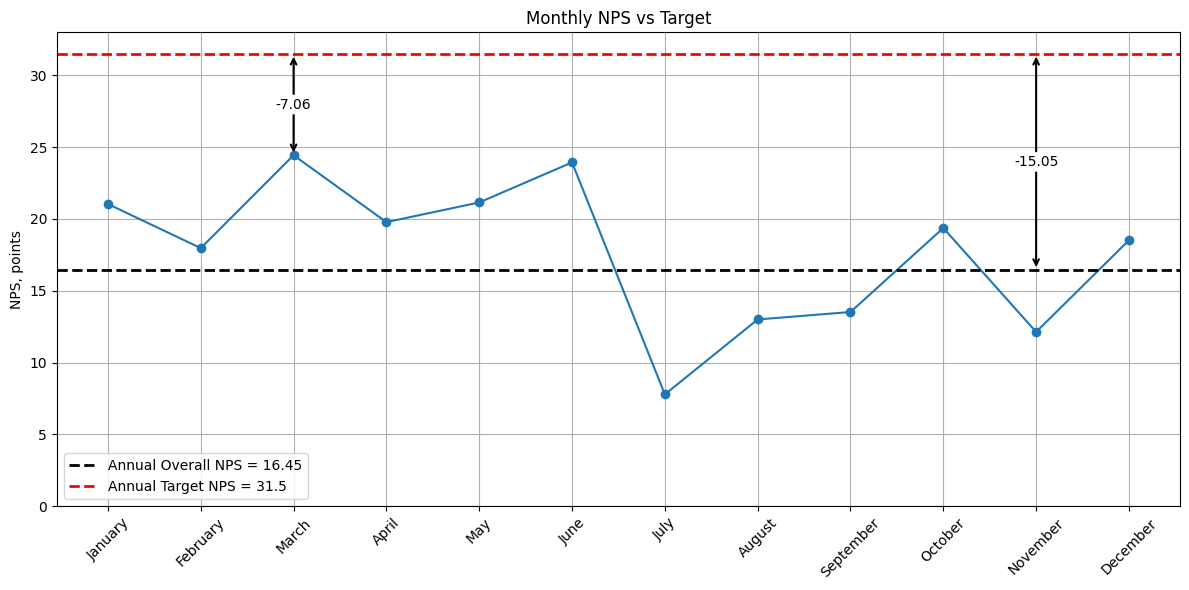

In [39]:
import matplotlib.pyplot as plt

target_nps = 31.5
#nps_year = monthly_nps["NPS_month"].mean()

nps_year = float(pd.read_sql("""
SELECT
    ROUND((1.0 * SUM(CASE WHEN NPS_score >= 9 THEN Num_answers ELSE 0 END) / SUM(Num_answers) -
           1.0 * SUM(CASE WHEN NPS_score <= 6 THEN Num_answers ELSE 0 END) / SUM(Num_answers)) * 100, 2) AS NPS_year
FROM nps_answers;
""", conn)["NPS_year"].iloc[0])

max_nps = monthly_nps["NPS_month"].max()
max_idx = monthly_nps["NPS_month"].idxmax()

gap_max = target_nps - max_nps
gap_year = target_nps - nps_year

plt.figure(figsize=(12,6))

plt.plot(monthly_nps["Month"], monthly_nps["NPS_month"], marker="o")

plt.axhline(nps_year, linestyle="--", linewidth=2,
            label=f"Annual Overall NPS = {nps_year:.2f}", color="black")

plt.axhline(target_nps, linestyle="--", linewidth=2,
            label=f"Annual Target NPS = {target_nps}", color="red")

# ===== Стрелка максимума (строго вертикальная)
plt.annotate(
    "",
    xy=(max_idx, max_nps),
    xytext=(max_idx, target_nps),
    arrowprops=dict(arrowstyle="<->", linewidth=1.5)
)

plt.text(
    max_idx,
    (target_nps + max_nps)/2,
    f"-{gap_max:.2f}",
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none")
)

# ===== Стрелка среднего (ставим справа, чтобы не мешала)
year_x = len(monthly_nps) - 2

plt.annotate(
    "",
    xy=(year_x, nps_year),
    xytext=(year_x, target_nps),
    arrowprops=dict(arrowstyle="<->", linewidth=1.5)
)

plt.text(
    year_x,
    (target_nps + nps_year)/2,
    f"-{gap_year:.2f}",
    ha="center",
    va="center",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.2", fc="white", ec="none")
)

plt.ylim(0, 33)

plt.xticks(rotation=45)
plt.ylabel("NPS, points")
plt.title("Monthly NPS vs Target")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# **Расчёт месячного NPS из исходной таблицы**

На данном этапе рассчитывается динамика NPS по месяцам непосредственно из исходной таблицы, до построения агрегированной витрины данных.

В исходной таблице каждая строка содержит значение NPS_score и соответствующее количество ответов Num_answers. Поэтому месячный NPS рассчитывается как взвешенное среднее значение оценки, где весом выступает количество ответов.

Формула расчёта:

$$
NPS_{month} =
\frac{\sum (NPS\_score \times Num\_answers)}
{\sum Num\_answers}
$$

Базовое значение NPS, показанное на графике, рассчитано на полном, неотфильтрованном датасете.

В рамках проверки качества данных дополнительно был проведён анализ влияния правил фильтрации. Результаты показали, что фильтрация изменяет вклад сегментов до ~10%, однако эти изменения происходят только в малых сегментах, не являющихся драйверами метрики, и не оказывают существенного влияния на общую структуру метрики. Поэтому baseline, рассчитанный на полном датасете, считается репрезентативным для дальнейшего анализа.

# **Monthly NPS Calculation from the Source Table**

At this stage, the monthly NPS trend is calculated directly from the source table, before building the aggregated data mart.

In the source table, each row contains an NPS_score and the corresponding number of responses Num_answers. Therefore, the monthly NPS is computed as a weighted average score, where the number of responses is used as the weight.

The calculation formula is:

$$
NPS_{month} =
\frac{\sum (NPS\_score \times Num\_answers)}
{\sum Num\_answers}
$$

The baseline NPS shown in the chart is calculated on the full, unfiltered dataset.

As part of the data quality checks, additional analysis was performed to evaluate the impact of filtering rules. The results show that filtering changes segment contributions by up to ~10%, but these changes occur only in small, non-driver segments and do not materially affect the overall metric structure. Therefore, the baseline calculated on the full dataset is considered representative for the subsequent analysis.

In [40]:
target_nps = 31.5

# Базовые значения
min_nps = monthly_nps["NPS_month"].min()
max_nps = monthly_nps["NPS_month"].max()

best_month = monthly_nps.loc[monthly_nps["NPS_month"].idxmax(), "Month"]
worst_month = monthly_nps.loc[monthly_nps["NPS_month"].idxmin(), "Month"]

range_gap = max_nps - min_nps

gap_year_to_target = target_nps - nps_year
gap_max_to_target = target_nps - max_nps

summary_table = pd.DataFrame({
    "Year_NPS": [round(nps_year, 2)],
    "Target_NPS": [target_nps],
    "Min_Monthly_NPS": [round(min_nps, 2)],
    "Max_Monthly_NPS": [round(max_nps, 2)],
    "Range_Gap (Max-Min)": [round(range_gap, 2)],
    "Gap_Year_to_Target": [round(gap_year_to_target, 2)],
    "Gap_Max_to_Target": [round(gap_max_to_target, 2)],
    "Best_Month": [best_month],
    "Worst_Month": [worst_month]
})

summary_table

,Year_NPS,Target_NPS,Min_Monthly_NPS,Max_Monthly_NPS,Range_Gap (Max-Min),Gap_Year_to_Target,Gap_Max_to_Target,Best_Month,Worst_Month
0,16.45,31.5,7.78,24.44,16.66,15.05,7.06,March,July


# **Анализ общей динамики NPS**

По результатам расчётов:

- общий NPS за год составил 16.45
- целевое значение NPS — 31.5

Таким образом, фактический уровень NPS ниже целевого на 15.05 пунктов.

Анализ помесячной динамики показывает:

- лучший месяц по NPS — March (24.44)
- худший месяц — July (7.78)

Разброс между максимальным и минимальным значениями составляет 16.66 пунктов, что указывает на значительную вариативность клиентского опыта в течение года.

При этом ни в одном месяце значение NPS не достигает целевого уровня, что говорит о систематическом недостижении KPI.

# **Analysis of overall NPS dynamics**

According to the calculations:

- the overall NPS for the year is 16.45
- the target NPS value is 31.5

Thus, the actual NPS level is 15.05 points below the target.

The analysis of monthly dynamics shows:

- the best month by NPS is March (24.44)
- the worst month is July (7.78)

The spread between the maximum and minimum monthly values is 16.66 points, which indicates substantial variability in customer experience throughout the year.

At the same time, in none of the months does the NPS reach the target level, which suggests a systematic underperformance relative to the KPI.

In [41]:
df_work = pd.read_sql("""
WITH base AS (
  SELECT
    Month,
    survey_product_name,
    survey_channel,
    age_group,
    gender_id,

    SUM(Num_answers) AS total_answers,

    SUM(CASE WHEN NPS_score >= 9 THEN Num_answers ELSE 0 END) AS promoters,
    SUM(CASE WHEN NPS_score BETWEEN 7 AND 8 THEN Num_answers ELSE 0 END) AS passives,
    SUM(CASE WHEN NPS_score <= 6 THEN Num_answers ELSE 0 END) AS detractors

  FROM nps_answers
  GROUP BY
    Month, survey_product_name, survey_channel, age_group, gender_id
)

SELECT
  Month,
  survey_product_name,
  survey_channel,
  age_group,
  gender_id,

  total_answers,
  promoters,
  passives,
  detractors,

  ROUND(1.0 * promoters / NULLIF(total_answers,0), 4) AS promoters_share,
  ROUND(1.0 * detractors / NULLIF(total_answers,0), 4) AS detractors_share,

  ROUND((1.0 * promoters / NULLIF(total_answers,0) - 1.0 * detractors / NULLIF(total_answers,0)) * 100, 2) AS nps
FROM base
WHERE total_answers > 0

ORDER BY
  CASE Month
    WHEN 'January' THEN 1
    WHEN 'February' THEN 2
    WHEN 'March' THEN 3
    WHEN 'April' THEN 4
    WHEN 'May' THEN 5
    WHEN 'June' THEN 6
    WHEN 'July' THEN 7
    WHEN 'August' THEN 8
    WHEN 'September' THEN 9
    WHEN 'October' THEN 10
    WHEN 'November' THEN 11
    WHEN 'December' THEN 12
  END
;
""", conn)

df_work.head(10)

,Month,survey_product_name,survey_channel,age_group,gender_id,total_answers,promoters,passives,detractors,promoters_share,detractors_share,nps
0,January,Product_1,Email,18 - 25,Female,2,0,1,1,0.0000,0.50,-50.00
1,January,Product_1,Email,18 - 25,Male,1,1,0,0,1.0000,0.00,100.00
2,January,Product_1,Email,26-29,Female,2,2,0,0,1.0000,0.00,100.00
3,January,Product_1,Email,29-39,Female,5,3,1,1,0.6000,0.20,40.00
4,January,Product_1,Email,29-39,Male,5,3,2,0,0.6000,0.00,60.00
5,January,Product_1,Email,39-49,Female,4,0,3,1,0.0000,0.25,-25.00
6,January,Product_1,Email,39-49,Male,10,5,2,3,0.5000,0.30,20.00
7,January,Product_1,Email,50+,Female,2,1,1,0,0.5000,0.00,50.00
8,January,Product_1,Email,50+,Male,1,1,0,0,1.0000,0.00,100.00
9,January,Product_1,SMS,18 - 25,Female,6,1,2,3,0.1667,0.50,-33.33


In [42]:
#month_order = ["January","February","March","April","May","June", "July","August","September","October","November","December"]

#df_work["Month"] = pd.Categorical(df_work["Month"], categories=month_order, ordered=True)
#df_work = df_work.sort_values("Month")

# 1) sum across the whole table
total_answers = df_work["total_answers"].sum()
promoters = df_work["promoters"].sum()
detractors = df_work["detractors"].sum()

# 2) Baseline (overall annual NPS)
baseline_nps = ((promoters / total_answers) - (detractors / total_answers)) * 100

print(f"Total answers: {int(total_answers)}")
print(f"Promoters:     {int(promoters)}")
print(f"Detractors:    {int(detractors)}")
print(f"Baseline NPS (overall): {baseline_nps:.2f}")

Total answers: 113799
Promoters:     56035
Detractors:    37316
Baseline NPS (overall): 16.45


# **Выше, для последующего анализа была сформирована витрина (агрегированная таблица) "df_work".**

Витрина агрегирует исходные данные "nps_answers" по следующим измерениям:

- месяц проведения опроса (Month)
- продукт (survey_product_name)
- канал опроса (survey_channel)
- возрастная группа (age_group)
- пол респондента (gender_id)

Для каждого сегмента рассчитаны:

- общее количество ответов (total_answers)
- число промоутеров (promoters)
- число нейтральных ответов (passives)
- число критиков (detractors)

NPS рассчитывается по стандартной формуле:

$$
NPS = \left(\frac{promoters - detractors}{total}\right) \times 100
$$

Использование агрегированной витрины позволяет:

- корректно учитывать веса ответов (Num_answers)
- быстро анализировать влияние различных факторов на метрику NPS.

# **Above, an aggregated analytical table "df_work" was created for the subsequent analysis.**

The table aggregates the original "nps_answers" data across the following dimensions:

- survey month (Month)
- product (survey_product_name)
- survey channel (survey_channel)
- age group (age_group)
- respondent gender (gender_id)

For each segment, the following metrics are calculated:

- total number of responses (total_answers)
- number of promoters (promoters)
- number of passive responses (passives)
- number of detractors (detractors)

The NPS metric is calculated using the standard formula:

$$
NPS = \left(\frac{promoters - detractors}{total}\right) \times 100
$$

Using this aggregated table allows us to:

- correctly account for the response weights (Num_answers)
- efficiently analyze the impact of different factors on the NPS metric.

In [43]:
df_filtered = df_work[df_work["total_answers"] >= 10]

In [44]:
df_work["nps"].describe()

,nps
count,1060.000000
mean,25.176660
std,43.566062
min,-100.000000
25%,0.000000
50%,28.570000
75%,50.000000
max,100.000000


In [45]:
df_filtered["nps"].describe()

,nps
count,649.000000
mean,26.711418
std,24.935793
min,-72.730000
25%,12.470000
50%,29.700000
75%,44.570000
max,81.820000


In [46]:
small_segments = df_work[df_work["total_answers"] < 10]

small_segments_count = small_segments.shape[0]
total_segments = df_work.shape[0]

small_segments_share = small_segments_count / total_segments

small_segments_count, total_segments, small_segments_share

(411, 1060, 0.3877358490566038)

<Axes: >

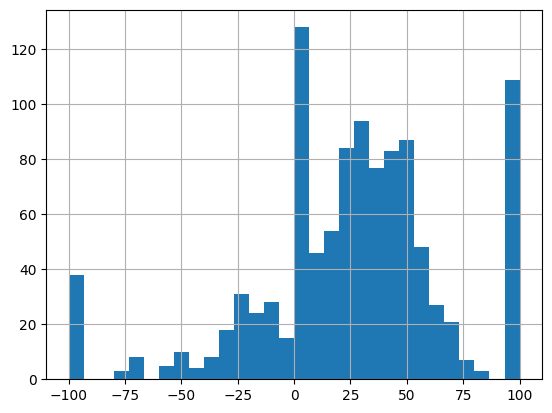

In [47]:
df_work["nps"].hist(bins=30)

<Axes: >

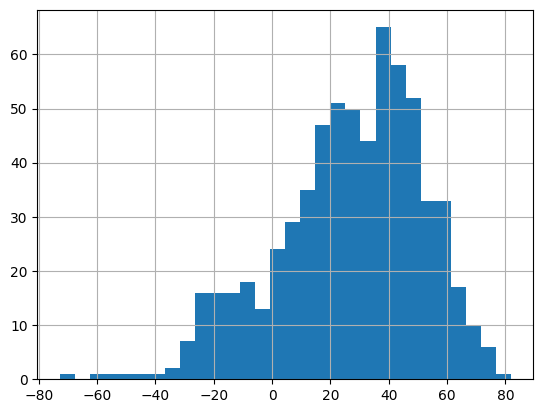

In [48]:
df_filtered["nps"].hist(bins=30)

In [49]:
df_work["total_answers"].describe()

,total_answers
count,1060.000000
mean,107.357547
std,237.939418
min,1.000000
25%,3.750000
50%,26.500000
75%,95.000000
max,1979.000000


In [50]:
df_filtered["total_answers"].describe()

,total_answers
count,649.000000
mean,173.328197
std,285.094318
min,10.000000
25%,33.000000
50%,74.000000
75%,185.000000
max,1979.000000


<Axes: >

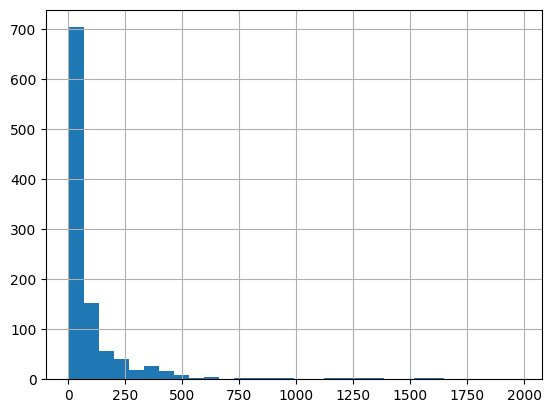

In [51]:
df_work["total_answers"].hist(bins=30)

<Axes: >

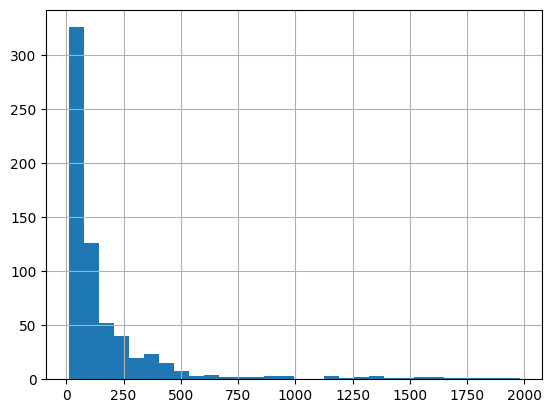

In [52]:
df_filtered["total_answers"].hist(bins=30)

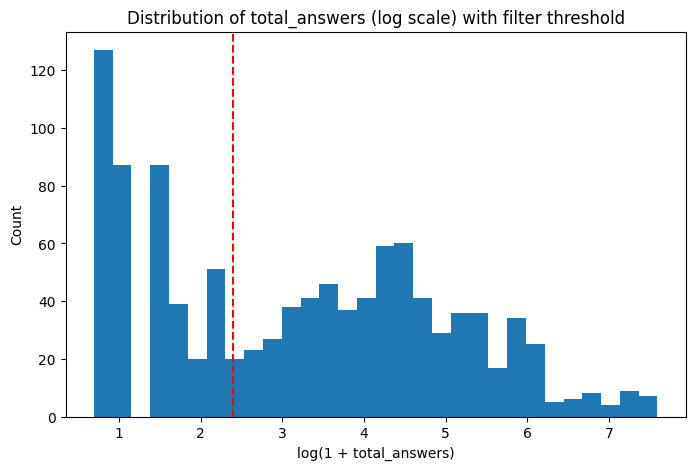

In [53]:
plt.figure(figsize=(8,5))

plt.hist(np.log1p(df_work["total_answers"]), bins=30)

plt.axvline(np.log1p(10), linestyle="--", color = 'red')

plt.xlabel("log(1 + total_answers)")
plt.ylabel("Count")
plt.title("Distribution of total_answers (log scale) with filter threshold")

plt.show()

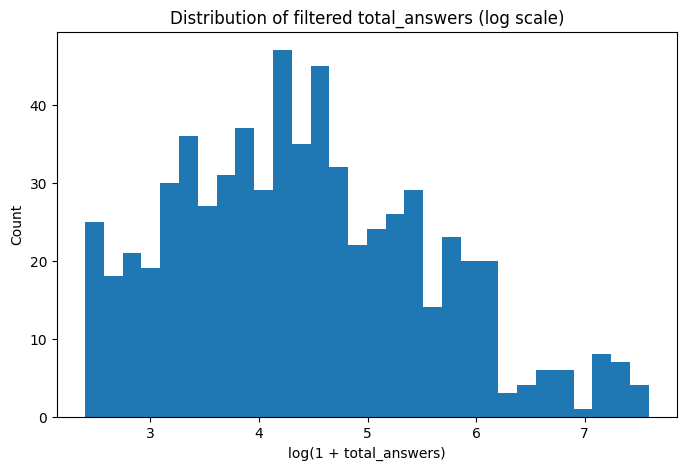

In [54]:
plt.figure(figsize=(8,5))

plt.hist(np.log1p(df_filtered["total_answers"]), bins=30)

#plt.axvline(np.log1p(10), linestyle="--", color = 'red')

plt.xlabel("log(1 + total_answers)")
plt.ylabel("Count")
plt.title("Distribution of filtered total_answers (log scale)")

plt.show()

# **Сравнительный анализ распределений в полной и отфильтрованной витрине**

Для оценки устойчивости результатов анализа был проведён сравнительный анализ распределений NPS и количества ответов для:

- полной витрины данных df_work
- отфильтрованной витрины df_filtered (сегменты с total_answers ≥ 10)

Целью фильтрации является снижение влияния статистического шума, возникающего в сегментах с очень малым количеством ответов.

---

1. Изменение распределения количества ответов

В полной витрине:

- количество сегментов: 1060
- среднее число ответов: 107
- медиана: 26.5
- стандартное отклонение: 237

Распределение сильно правосторонне асимметрично, что подтверждается значительным разрывом между средним и медианой. Это означает, что большинство сегментов содержит относительно небольшое число ответов, а небольшое количество сегментов имеет очень большой объём данных.

После фильтрации:

- количество сегментов: 649
- среднее число ответов: 173
- медиана: 74
- стандартное отклонение: 285

Удаление сегментов с менее чем 10 ответами приводит к смещению распределения вправо, что ожидаемо, поскольку остаются только сегменты с более стабильными выборками.

Гистограммы показывают, что основная форма распределения сохраняется, однако удаляется значительная доля сегментов с минимальными объёмами данных.

---

2. Изменение распределения NPS

Для полной витрины:

- средний NPS: 25.18
- медиана: 28.57
- стандартное отклонение: 43.57
- 25-й перцентиль: 0
- 75-й перцентиль: 50

Межквартильный размах:

IQR = 50

Высокое стандартное отклонение и широкий IQR указывают на значительную вариативность NPS между сегментами.

Гистограмма показывает большое число экстремальных значений (вблизи −100 и 100), что типично для сегментов с очень малым количеством ответов.

---

Для отфильтрованной витрины:

- средний NPS: 26.71
- медиана: 29.70
- стандартное отклонение: 24.94
- 25-й перцентиль: 12.47
- 75-й перцентиль: 44.57

Межквартильный размах:

IQR = 32.1

После удаления малых сегментов:

- стандартное отклонение снижается почти в 2 раза
- межквартильный размах уменьшается
- исчезает значительная часть экстремальных значений

Гистограмма NPS становится более компактной и близкой к нормальному распределению, что указывает на снижение влияния статистического шума.

---

3. Интерпретация результатов

Сравнение полной и отфильтрованной витрин показывает, что значительная часть экстремальных значений NPS объясняется сегментами с очень малым количеством ответов.

Фильтрация сегментов с total_answers < 10 приводит к:

- существенному снижению дисперсии NPS
- уменьшению числа экстремальных значений
- более стабильному распределению метрики

*При этом среднее и медианное значения NPS изменяются незначительно, что свидетельствует о том, что общий уровень клиентского опыта остаётся стабильным, а основное влияние фильтрации связано именно с уменьшением статистического шума.*

---

4. Вывод

Проведённый сравнительный анализ полной витрины (df_work) и отфильтрованной витрины (df_filtered) показывает, что значительная часть экстремальных значений NPS в полной выборке связана с сегментами, содержащими очень небольшое количество ответов.

Фильтрация сегментов с total_answers < 10 приводит к снижению дисперсии метрики и делает распределение NPS более стабильным и интерпретируемым, при этом среднее и медианное значения NPS изменяются незначительно.

Далее будет выполнен spread-check для обеих витрин данных:

- полной витрины (df_work)
- отфильтрованной витрины (df_filtered)

Сравнение результатов этих spread-check позволяет:

- определить основного кандидата на роль драйвера NPS;
- определить порядок проверки гипотез.

# Порядок дальнейшего анализа драйверов будет определяться на основе результатов spread-check для отфильтрованной витрины, поскольку она отражает более устойчивую статистическую структуру данных и в меньшей степени подвержена влиянию сегментов с малым числом наблюдений.

# **Comparative analysis of distributions in the full and filtered datasets**

To evaluate the robustness of the results, a comparative analysis of NPS and response count distributions was performed for:

- the full dataset df_work
- the filtered dataset df_filtered (segments with total_answers ≥ 10)

The purpose of this filtering is to reduce the impact of statistical noise caused by segments with very small sample sizes.

---

1. Changes in the distribution of response counts

In the full dataset:

- number of segments: 1060
- mean number of responses: 107
- median: 26.5
- standard deviation: 237

The distribution is strongly right-skewed, which is reflected in the large gap between the mean and the median. This indicates that most segments contain relatively few responses, while a small number of segments accumulate very large response volumes.

After filtering:

- number of segments: 649
- mean responses: 173
- median: 74
- standard deviation: 285

Removing segments with fewer than 10 responses shifts the distribution to the right, which is expected since only segments with more stable sample sizes remain.

The histograms show that the overall shape of the distribution remains similar, while the concentration of very small segments disappears.

---

2. Changes in the NPS distribution

For the full dataset:

- mean NPS: 25.18
- median: 28.57
- standard deviation: 43.57
- 25th percentile: 0
- 75th percentile: 50

Interquartile range:

IQR = 50

The large standard deviation and wide IQR indicate substantial variability of NPS across segments.

The histogram also shows many extreme values (close to −100 and 100), which is typical for segments with very small numbers of responses.

---

For the filtered dataset:

- mean NPS: 26.71
- median: 29.70
- standard deviation: 24.94
- 25th percentile: 12.47
- 75th percentile: 44.57

Interquartile range:

IQR = 32.1

After removing small segments:

- the standard deviation decreases by almost half
- the interquartile range becomes smaller
- many extreme values disappear

The NPS histogram becomes more compact and closer to a normal distribution, indicating that a large part of the variability in the full dataset was driven by statistical noise.

---

3. Interpretation

The comparison between the full and filtered datasets shows that a substantial portion of extreme NPS values is associated with segments that contain very small numbers of responses.

Filtering segments with total_answers < 10 leads to:

- a significant reduction in NPS variance
- fewer extreme observations
- a more stable distribution of the metric

At the same time, the mean and median NPS change only slightly, suggesting that the overall level of customer experience remains stable, while the main impact of filtering is the reduction of statistical noise.

---

4. Conclusion

The comparative analysis of the full dataset (df_work) and the filtered dataset (df_filtered) shows that a substantial share of extreme NPS values in the full dataset is associated with segments containing very small numbers of responses.

Filtering segments with total_answers < 10 reduces the variance of the metric and results in a more stable and interpretable distribution of NPS, while the mean and median NPS remain largely unchanged.

At the next step, spread-check will be performed for both datasets:

- the full dataset (df_work)
- the filtered dataset (df_filtered)

Comparing the results of these spread-checks allows us to:

- identify the main candidate driver of NPS;
- determine the order in which hypotheses should be tested.

# The subsequent driver analysis will follow the hypothesis order derived from the filtered dataset, as it represents a more statistically stable structure of the data and is less affected by segments with very small sample sizes.

In [55]:
dimensions = [
    "survey_channel",
    "survey_product_name",
    "age_group",
    "gender_id",
    "Month"
]

spread_results = []

for dim in dimensions:

    grouped = (
        df_work
        .groupby(dim)["nps"]
        .mean()
        .reset_index()
    )

    min_nps = grouped["nps"].min()
    max_nps = grouped["nps"].max()

    spread_results.append({
        "dimension": dim,
        "min_nps": min_nps,
        "max_nps": max_nps,
        "spread": max_nps - min_nps
    })

spread_df = pd.DataFrame(spread_results)

spread_df.sort_values("spread", ascending=False)

,dimension,min_nps,max_nps,spread
0,survey_channel,0.000000,53.678276,53.678276
4,Month,12.050375,35.250104,23.199729
3,gender_id,16.460279,34.160211,17.699932
2,age_group,17.824615,32.646032,14.821416
1,survey_product_name,22.415164,30.844718,8.429555


In [56]:
df_filtered = df_work[df_work["total_answers"] >= 10]

dimensions = [
    "survey_channel",
    "survey_product_name",
    "age_group",
    "gender_id",
    "Month"
]

spread_results = []

for dim in dimensions:

    grouped = (
        df_filtered
        .groupby(dim)["nps"]
        .mean()
        .reset_index()
    )

    min_nps = grouped["nps"].min()
    max_nps = grouped["nps"].max()

    spread_results.append({
        "dimension": dim,
        "min_nps": min_nps,
        "max_nps": max_nps,
        "spread": max_nps - min_nps
    })

spread_df = pd.DataFrame(spread_results)

spread_df.sort_values("spread", ascending=False)

,dimension,min_nps,max_nps,spread
0,survey_channel,-5.000000,36.678612,41.678612
3,gender_id,16.911067,36.725483,19.814416
1,survey_product_name,20.406258,39.419931,19.013673
4,Month,17.042391,36.009697,18.967306
2,age_group,16.463265,34.254478,17.791212


# **Результаты spread-check**

Для предварительной оценки потенциальных драйверов NPS был проведён spread-check — анализ разброса среднего NPS между категориями различных факторов.

Методика заключается в следующем:

1. Для каждого фактора рассчитывается средний NPS по каждой категории.
2. Далее определяется минимальное и максимальное значение NPS среди категорий.
3. Разница между ними (spread = max_nps − min_nps) показывает потенциальную силу влияния фактора на метрику.

Анализ был проведён для двух выборок:

- полной витрины данных (df_work)
- отфильтрованной витрины (df_filtered, total_answers ≥ 10)

---

Spread-check для полной витрины (df_work)

Результаты анализа показывают следующий порядок факторов по величине разброса NPS:

Фактор | Spread\
survey_channel | ~53.7\
Month | ~23.2\
gender_id | ~17.7\
age_group | ~14.8\
survey_product_name | ~8.4

Наибольший разброс наблюдается по фактору survey_channel, где разница между минимальным и максимальным средним NPS составляет более 53 пунктов. Это значительно превышает разброс по другим факторам и указывает на высокую вероятность того, что канал взаимодействия является важным источником различий в NPS.

---

Spread-check для отфильтрованной витрины (df_filtered)

После удаления сегментов с малым количеством ответов результаты остаются следующими:

Фактор | Spread\
survey_channel | ~41.7\
gender_id | ~19.8\
survey_product_name | ~19.0\
Month | ~19.0\
age_group | ~17.8

Хотя абсолютное значение разброса по каналу снижается (что ожидаемо после удаления статистически нестабильных сегментов), фактор survey_channel всё равно остаётся на первом месте по величине spread.

Это означает, что влияние канала взаимодействия на NPS сохраняется даже после очистки данных от малых сегментов, что усиливает гипотезу о том, что данный фактор может быть ключевым драйвером различий в метрике.

---

Вывод

Сравнение результатов spread-check для полной и отфильтрованной витрин показывает, что фактор survey_channel занимает первое место по величине разброса NPS в обеих выборках. Это позволяет рассматривать канал взаимодействия как главного кандидата на роль драйвера NPS.

При этом порядок остальных факторов несколько меняется после фильтрации данных. Поскольку отфильтрованная витрина отражает более устойчивую статистическую структуру, именно на её основе определяется порядок дальнейшей проверки гипотез.

# **Таким образом, на следующем этапе:**

- в первую очередь будет проверена гипотеза о влиянии канала взаимодействия на NPS;
- далее остальные гипотезы будут проверяться в порядке, определённом spread-check для отфильтрованной витрины;
- после выявления наиболее сильного драйвера будет выполнен drill-down анализ внутри соответствующего фактора для выявления конкретного источника различий в клиентском опыте.

# **Spread-check results across potential NPS drivers**

To preliminarily identify potential drivers of NPS variation, a spread-check analysis was performed. This approach evaluates the variability of average NPS across categories of different factors.

The methodology is as follows:

1. For each factor, the average NPS is calculated for each category.
2. The minimum and maximum NPS values across categories are identified.
3. The difference between them (spread = max_nps − min_nps) indicates the potential strength of the factor’s influence on the metric.

The analysis was conducted for two datasets:

- the full dataset (df_work)
- the filtered dataset (df_filtered, total_answers ≥ 10)

---

Spread-check for the full dataset (df_work)

The results show the following ranking of factors by NPS spread:

Factor | Spread\
survey_channel | ~53.7\
Month | ~23.2\
gender_id | ~17.7\
age_group | ~14.8\
survey_product_name | ~8.4

The largest spread is observed for survey_channel, where the difference between the lowest and highest average NPS exceeds 53 points. This is significantly larger than the spread for other factors and suggests that the interaction channel may be a major source of NPS variation.

---

Spread-check for the filtered dataset (df_filtered)

After removing segments with very small response counts, the results become:

Factor | Spread\
survey_channel | ~41.7\
gender_id | ~19.8\
survey_product_name | ~19.0\
Month | ~19.0\
age_group | ~17.8

Although the absolute spread for the channel decreases (which is expected after removing statistically unstable segments), survey_channel remains the factor with the largest spread.

This indicates that the effect of the interaction channel on NPS persists even after filtering the data, strengthening the hypothesis that this factor may be a key driver of variation in the metric.

---

Conclusion

The comparison of spread-check results for the full and filtered datasets shows that survey_channel ranks first in terms of NPS spread in both datasets. Therefore, the interaction channel can be considered the main candidate driver of NPS variation.

At the same time, the ranking of the remaining factors changes slightly after filtering. Since the filtered dataset provides a more statistically stable representation of the data, the order of further hypothesis testing will be determined based on the spread-check results from this dataset.

# **Thus, the next analytical steps are:**

- first, test the hypothesis that the interaction channel influences NPS;
- then evaluate the remaining hypotheses in the order defined by the spread-check of the filtered dataset;
- once the strongest driver is identified, perform a drill-down analysis within that factor to determine the specific source of NPS variation.

# **Гипотеза 1: канал взаимодействия влияет на уровень NPS**

Согласно результатам spread-check анализа, фактор survey_channel демонстрирует наибольший разброс значений NPS среди всех рассмотренных измерений.

Этот результат наблюдается как в полной витрине данных, так и в отфильтрованной витрине, где были исключены сегменты с очень малым количеством ответов. В обеих таблицах spread-check фактор канала взаимодействия занимает первое место по величине spread, что делает его главным кандидатом на роль потенциального драйвера различий в NPS.

Цель данного шага — проверить, действительно ли различные каналы взаимодействия с клиентами приводят к систематическим различиям в уровне удовлетворённости.

Для этого проводится следующий анализ:

1. Рассчитывается количество ответов, промоутеров и детракторов для каждого канала опроса.
2. На основе этих значений вычисляется NPS для каждого канала.
3. Далее определяется отклонение NPS каждого канала от общего среднего NPS (baseline).
4. Рассчитывается вклад каждого канала в итоговое значение NPS, учитывающий одновременно:
   - отклонение NPS канала от baseline
   - долю ответов данного канала в общей выборке.

Формула вклада:

NPS contribution = weight × (NPS − baseline NPS)

где weight — доля ответов данного канала в общем количестве ответов.

Такой подход позволяет определить не только какие каналы имеют более низкий уровень удовлетворённости, но и какие из них оказывают наибольшее влияние на итоговый показатель NPS, учитывая объём ответов.

После расчёта вкладов выполняется визуализация драйверов NPS, позволяющая определить, какие каналы оказывают наибольшее положительное и отрицательное влияние на общий уровень клиентской удовлетворённости.

# **Hypothesis 1: The interaction channel influences NPS**

According to the spread-check analysis, the survey_channel factor shows the largest variation in NPS values among all analyzed dimensions.

This pattern is observed both in the full dataset and in the filtered dataset, where segments with very small sample sizes were removed. In both spread-check tables, the interaction channel ranks first by NPS spread, making it the primary candidate driver of NPS variation.

The goal of this step is to test whether different customer interaction channels lead to systematic differences in customer satisfaction levels.

The analysis proceeds as follows:

1. Calculate the number of responses, promoters, and detractors for each survey channel.
2. Compute the NPS for each channel.
3. Measure the difference between each channel’s NPS and the overall baseline NPS.
4. Calculate the contribution of each channel to the overall NPS, taking into account both:
   - the deviation from the baseline
   - the share of responses from that channel.

Contribution formula:

NPS contribution = weight × (NPS − baseline NPS)

where weight represents the share of responses from the channel in the total dataset.

This approach allows us to determine not only which channels have lower satisfaction levels, but also which channels contribute the most to the overall NPS, considering the volume of responses.

After calculating contributions, a visualization of NPS drivers is created to identify which channels have the strongest positive and negative impact on the overall customer satisfaction metric.

In [57]:
channel_analysis = (
    df_work
    .groupby("survey_channel")
    .agg(
        total_answers=("total_answers","sum"),
        promoters=("promoters","sum"),
        detractors=("detractors","sum")
    )
)

channel_analysis["NPS"] = (
    (channel_analysis["promoters"] - channel_analysis["detractors"])
    / channel_analysis["total_answers"]
) * 100

channel_analysis["diff_vs_baseline"] = channel_analysis["NPS"] - baseline_nps

channel_analysis.sort_values("NPS")

,total_answers,promoters,detractors,NPS,diff_vs_baseline
survey_channel,,,,,
SMS,13755,5591,5689,-0.712468,-17.161646
Unknown,5,2,2,0.000000,-16.449178
VoiceBot,56598,25519,22871,4.678611,-11.770567
Email,3018,1774,808,32.007952,15.558774
Telegram,40371,23115,7941,37.586386,21.137208
Website,52,34,5,55.769231,39.320053


# **Результаты анализа каналов опроса**

Анализ распределения NPS по каналам показал, что часть каналов демонстрирует значения метрики значительно ниже общего уровня NPS.

Наиболее низкий показатель наблюдается в канале **SMS**:
- **NPS = -0.71**
- отклонение от общего NPS: **-17.16 пунктов**
- количество ответов: **13 755**

Это указывает на крайне низкую удовлетворённость клиентов в данном канале.

Также относительно низкий показатель демонстрирует канал **VoiceBot**:
- **NPS = 4.68**
- отклонение от общего NPS: **-11.77 пунктов**
- количество ответов: **56 598**

При этом именно **VoiceBot формирует основной объём ответов**, поэтому даже умеренно низкий NPS в данном канале может существенно влиять на итоговое значение метрики.

Таким образом, можно сделать предварительный вывод, что **канал взаимодействия действительно влияет на уровень NPS**, а каналы **SMS** и **VoiceBot** могут являться ключевыми драйверами снижения общей метрики.

# **Survey Channel Analysis Results**

The analysis of NPS distribution across channels shows that some channels demonstrate metric values significantly below the overall NPS level.

The lowest indicator is observed in the SMS channel:

- NPS = -0.71
- deviation from overall NPS: -17.16 points
- number of responses: 13,755

This indicates extremely low customer satisfaction within this channel.

A relatively low value is also observed in the VoiceBot channel:

- NPS = 4.68
- deviation from overall NPS: -11.77 points
- number of responses: 56,598

At the same time, VoiceBot generates the majority of responses, which means that even a moderately low NPS in this channel can significantly affect the final value of the metric.

Thus, a preliminary conclusion can be made that the interaction channel does influence the NPS level, and the SMS and VoiceBot channels may be key drivers of the decline in the overall metric.

In [58]:
total_answers_all = channel_analysis["total_answers"].sum()

channel_analysis["weight"] = channel_analysis["total_answers"] / total_answers_all

channel_analysis["nps_contribution"] = (
    channel_analysis["weight"] * (channel_analysis["NPS"] - baseline_nps)
)

channel_analysis.sort_values("nps_contribution")

,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
survey_channel,,,,,,,
VoiceBot,56598,25519,22871,4.678611,-11.770567,0.497351,-5.854099
SMS,13755,5591,5689,-0.712468,-17.161646,0.120871,-2.074345
Unknown,5,2,2,0.000000,-16.449178,0.000044,-0.000723
Website,52,34,5,55.769231,39.320053,0.000457,0.017967
Email,3018,1774,808,32.007952,15.558774,0.026520,0.412626
Telegram,40371,23115,7941,37.586386,21.137208,0.354757,7.498574


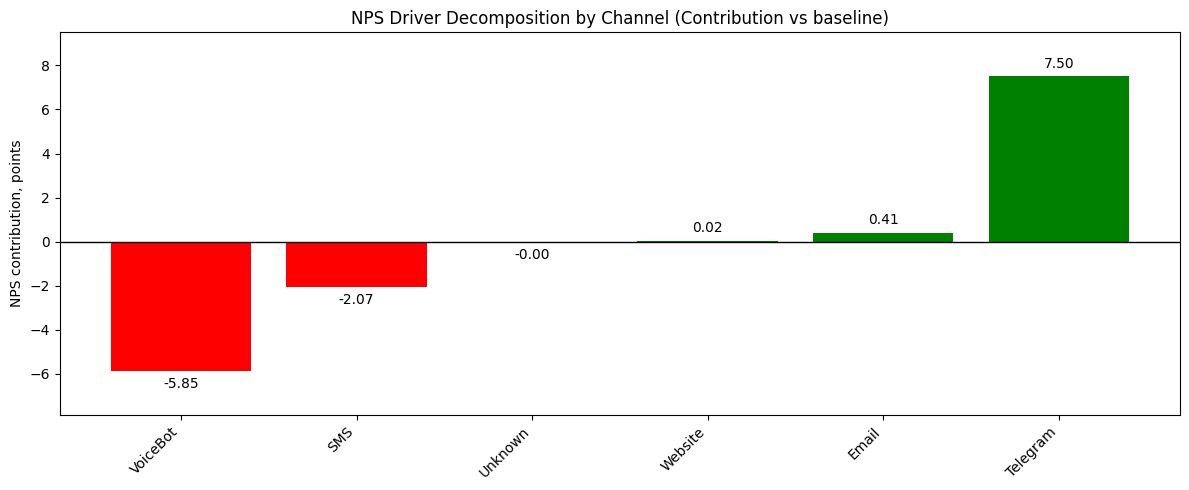

,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
survey_channel,,,,,,,
VoiceBot,56598,25519,22871,4.678611,-11.770567,0.497351,-5.854099
SMS,13755,5591,5689,-0.712468,-17.161646,0.120871,-2.074345


In [59]:
# --- Diverging "waterfall-like" contributions around zero ---

# Take contributions and sort (optional: by contribution ascending)
plot_df = channel_analysis.reset_index()[["survey_channel", "nps_contribution"]].copy()
plot_df = plot_df.sort_values("nps_contribution")  # negatives left, positives right

labels = plot_df["survey_channel"].tolist()
values = plot_df["nps_contribution"].values

# Color by sign
colors = np.where(values >= 0, "green", "red")

plt.figure(figsize=(12, 5))

# Bars start from 0 (this is the key!)
plt.bar(labels, values, color=colors)

# Zero baseline
plt.axhline(0, color="black", linewidth=1)

# Make sure y-axis includes both negative and positive sides
vmin = values.min()
vmax = values.max()
pad = 0.15 * (vmax - vmin) if vmax != vmin else 1.0
plt.ylim(vmin - pad, vmax + pad)

# Labels on bars
for i, v in enumerate(values):
    va = "bottom" if v >= 0 else "top"
    offset = 0.02 * (vmax - vmin) if vmax != vmin else 0.1
    plt.text(i, v + (offset if v >= 0 else -offset), f"{v:.2f}", ha="center", va=va)

plt.title("NPS Driver Decomposition by Channel (Contribution vs baseline)")
plt.ylabel("NPS contribution, points")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Identify top negative drivers
channel_analysis.sort_values("nps_contribution").head(2)

# Несмотря на самый низкий NPS у SMS, наибольший вклад в снижение общего NPS вносит канал VoiceBot, поскольку он сочетает низкий уровень удовлетворённости и максимальный объём ответов.

# Despite SMS having the lowest NPS, the largest contribution to the decline of the overall NPS comes from the VoiceBot channel, since it combines a relatively low satisfaction level with the largest volume of responses.

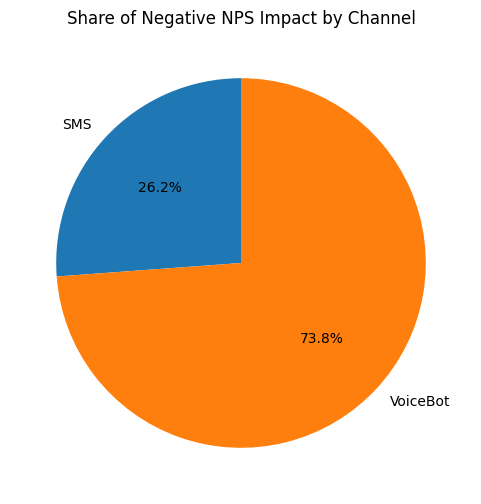

,survey_channel,nps_contribution,share
1,SMS,-2.074345,0.261633
4,VoiceBot,-5.854099,0.738367


In [60]:
import matplotlib.pyplot as plt

# --- Calculate share of negative NPS impact ---

neg_df = channel_analysis.reset_index()[["survey_channel", "nps_contribution"]].copy()

# Keep only negative contributions
neg_df = neg_df[neg_df["nps_contribution"] < 0]

# Convert to positive magnitude of impact
neg_df["impact"] = -neg_df["nps_contribution"]

# Remove statistically insignificant drivers if needed
neg_df = neg_df[neg_df["impact"] > 0.01]

# Calculate share of total negative impact
neg_df["share"] = neg_df["impact"] / neg_df["impact"].sum()

labels = neg_df["survey_channel"]
sizes = neg_df["share"]

plt.figure(figsize=(6,6))

plt.pie(
    sizes,
    labels=labels,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Share of Negative NPS Impact by Channel")

plt.show()

# Final summary table
neg_summary = neg_df[["survey_channel", "nps_contribution", "share"]]
neg_summary

### **Вклад каналов в негативное влияние на NPS**
**(гипотеза 1 подтверждена: канал влияет на общий NPS)**

Анализ показывает, что снижение общего показателя NPS в значительной степени связано с каналом VoiceBot.

Канал VoiceBot формирует около **74%** общего негативного влияния на NPS, тогда как SMS даёт около **26%**.

Негативный вклад VoiceBot составляет около **-5.85 пунктов NPS**.

По отношению к **общему отклонению годового NPS от целевого значения** \(15 пунктов\) данный вклад объясняет лишь примерно **одну треть снижения метрики**.

Следовательно, хотя канал VoiceBot является основным драйвером внутри гипотезы о влиянии канала, **существуют и другие факторы**, которые также вносят вклад в снижение общего NPS.

Поэтому дальнейший анализ будет направлен на проверку других гипотез о драйверах метрики.

### Логика проверки гипотез о драйверах NPS

Overall NPS  
│  
├─ H1: Канал взаимодействия - подтверждено  
│  
├─ H2: Пол  
│  
├─ H3: Продукт  
│  
├─ H4: Месяц  
│  
└─ H5: Возраст

На следующем этапе анализа для каждой гипотезы будет выполнен расчёт вклада сегментов в общий NPS, после чего драйверы будут сравнены между собой для определения наиболее значимого фактора.

### **Contribution of channels to negative NPS impact**
**(hypothesis 1 confirmed: channel affects overall NPS)**

The analysis shows that the decrease in overall NPS is significantly associated with the VoiceBot channel.

VoiceBot accounts for approximately **74%** of the total negative impact on NPS, while SMS contributes about **26%**.

The negative contribution of VoiceBot equals approximately **-5.85 NPS points**.

Сompared to the **overall deviation of yearly NPS from the target value** \(15 points\), this contribution explains only about **one third of the total decline**.

Therefore, although VoiceBot is the main driver within the channel hypothesis, **other factors must also contribute to the overall decrease in NPS**.

Thus, the next step of the analysis is to test the remaining hypotheses about potential drivers of the metric.

### NPS driver hypothesis structure

Overall NPS  
│  
├─ H1: Survey channel - confirmed  
│  
├─ H2: Gender  
│  
├─ H3: Product  
│  
├─ H4: Month  
│  
└─ H5: Age  

In the next stage, segment contribution will be calculated for each hypothesis in order to identify and compare the strongest drivers of the NPS change.

# **Гипотеза 2: опыт клиентов может различаться в зависимости от пола респондента**

Согласно результатам spread-check анализа, фактор gender_id демонстрирует значительный разброс значений NPS между категориями. Это позволяет предположить, что уровень клиентской удовлетворённости может различаться между респондентами разных полов.

Важно отметить, что в данном измерении присутствуют только две категории — мужчины и женщины. Поскольку общий NPS является взвешенным средним значением, вклад этих двух групп в итоговую метрику всегда компенсируется вокруг baseline. Поэтому анализ пола используется не для поиска драйверов падения общего NPS, а для выявления различий клиентского опыта между сегментами.

Цель данного шага определить, существует ли систематическая разница в уровне удовлетворённости между мужской и женской аудиторией.

Этот подход позволяет выявить, какая группа респондентов демонстрирует более высокий или более низкий уровень удовлетворённости и может требовать дополнительного внимания при дальнейшем анализе клиентского опыта.

# **Hypothesis 2: Customer experience may differ depending on respondent gender**

According to the spread-check analysis, the gender_id factor shows a noticeable variation in NPS between its categories. This suggests that customer satisfaction levels may differ between respondents of different genders.

It is important to note that this dimension contains only two categories — male and female. Since overall NPS represents a weighted average, the contributions of these two groups always balance each other around the baseline. Therefore, gender analysis is not used to identify drivers of the overall NPS decline but rather to detect differences in customer experience between segments.

The goal of this step is to determine whether a systematic difference in satisfaction levels exists between male and female respondents.

This approach allows us to identify which respondent group demonstrates higher or lower satisfaction and may require further investigation in the analysis of customer experience.

In [61]:
# --- Gender analysis ---

gender_analysis = (
    df_work
    .groupby("gender_id")
    .agg(
        total_answers=("total_answers", "sum"),
        promoters=("promoters", "sum"),
        detractors=("detractors", "sum")
    )
)

# Calculate NPS
gender_analysis["NPS"] = (
    (gender_analysis["promoters"] - gender_analysis["detractors"])
    / gender_analysis["total_answers"]
) * 100

# Difference from baseline
gender_analysis["diff_vs_baseline"] = gender_analysis["NPS"] - baseline_nps

# Calculate weight
total_answers_all = gender_analysis["total_answers"].sum()
gender_analysis["weight"] = gender_analysis["total_answers"] / total_answers_all

# NPS contribution
gender_analysis["nps_contribution"] = (
    gender_analysis["weight"] * gender_analysis["diff_vs_baseline"]
)

#gender_analysis.sort_values("nps_contribution")

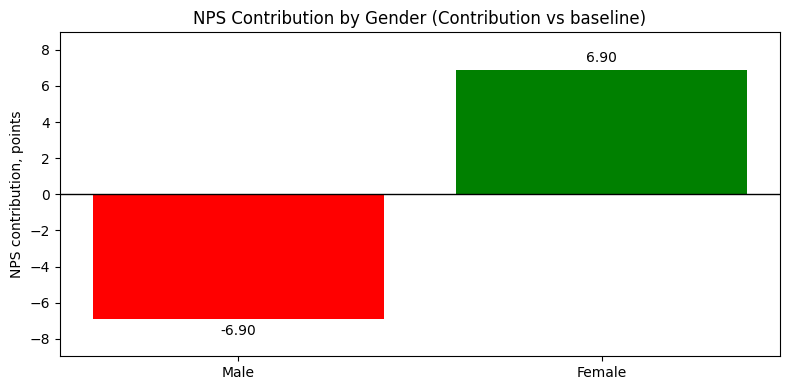

,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
gender_id,,,,,,,
Male,57229,24075,22510,2.734628,-13.714550,0.502895,-6.896985
Female,56570,31960,14806,30.323493,13.874315,0.497105,6.896985


In [62]:
import numpy as np
import matplotlib.pyplot as plt

# --- Diverging "waterfall-like" contributions around zero (GENDER) ---

plot_df = gender_analysis.reset_index()[["gender_id", "nps_contribution"]].copy()
plot_df = plot_df.sort_values("nps_contribution")  # negatives left, positives right

labels = plot_df["gender_id"].astype(str).tolist()
values = plot_df["nps_contribution"].values

colors = np.where(values >= 0, "green", "red")

plt.figure(figsize=(8, 4))
plt.bar(labels, values, color=colors)
plt.axhline(0, color="black", linewidth=1)

vmin = values.min()
vmax = values.max()
pad = 0.15 * (vmax - vmin) if vmax != vmin else 1.0
plt.ylim(vmin - pad, vmax + pad)

for i, v in enumerate(values):
    va = "bottom" if v >= 0 else "top"
    offset = 0.02 * (vmax - vmin) if vmax != vmin else 0.1
    plt.text(i, v + (offset if v >= 0 else -offset), f"{v:.2f}", ha="center", va=va)

plt.title("NPS Contribution by Gender (Contribution vs baseline)")
plt.ylabel("NPS contribution, points")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Quick table
gender_analysis.sort_values("nps_contribution")

# **Выводы по гипотезе: влияние пола респондента на клиентский опыт**

Анализ распределения NPS по полу показывает существенную разницу в уровне удовлетворённости между сегментами респондентов.

Наиболее низкий показатель наблюдается среди мужчин:

- NPS = 2.73
- отклонение от общего NPS: −13.71 пункта
- количество ответов: 57 229

В то же время среди женщин наблюдается значительно более высокий уровень удовлетворённости:

- NPS = 30.32
- отклонение от общего NPS: +13.87 пункта
- количество ответов: 56 570

Таким образом, разница между мужской и женской аудиторией составляет около 27 пунктов NPS, что указывает на очень заметное различие в восприятии клиентского опыта между сегментами.

При этом доля ответов в обеих группах практически одинаковая (около 50% каждой группы). Поскольку общий NPS является взвешенным средним значением, вклад этих двух сегментов в итоговую метрику математически компенсируется вокруг baseline. В результате отрицательный вклад мужского сегмента и положительный вклад женского сегмента практически полностью уравновешивают друг друга.

Важно отметить, что такая компенсация является свойством расчёта baseline и возникает в любом измерении с двумя категориями. Поэтому данный фактор не может рассматриваться как драйвер снижения общего NPS.

Тем не менее полученные результаты демонстрируют сильную сегментацию клиентского опыта по полу. Мужская аудитория демонстрирует существенно более низкий уровень удовлетворённости по сравнению с женской аудиторией, что может указывать на различия в восприятии продукта, пользовательского пути или ожиданий от сервиса.

Таким образом, фактор пола не объясняет изменение общего уровня NPS, однако выявляет значимое различие клиентского опыта между сегментами аудитории и может служить дополнительным направлением для более детального анализа пользовательского поведения.

Overall NPS  
│  
├─ H1: Канал взаимодействия - подтверждено  
│  
├─ H2: Пол  - не драйвер, но влияет на CX  
│  
├─ H3: Продукт  
│  
├─ H4: Месяц  
│  
└─ H5: Возраст


# **Conclusion for the hypothesis: the effect of respondent gender on customer experience**

The analysis of NPS distribution by gender reveals a substantial difference in satisfaction levels between respondent segments.

The lowest score is observed among male respondents:

- NPS = 2.73
- deviation from overall NPS: −13.71 points
- number of responses: 57,229

In contrast, female respondents demonstrate a significantly higher level of satisfaction:

- NPS = 30.32
- deviation from overall NPS: +13.87 points
- number of responses: 56,570

Thus, the difference between male and female respondents is approximately 27 NPS points, indicating a strong difference in perceived customer experience between the segments.

At the same time, the share of responses in both groups is almost identical (approximately 50% each). Since overall NPS is calculated as a weighted average, the contributions of these two segments mathematically offset each other around the baseline. As a result, the negative contribution of the male segment and the positive contribution of the female segment almost completely cancel out.

It is important to note that such compensation is a property of the baseline calculation and occurs in any dimension with only two categories. Therefore, this factor cannot be interpreted as a driver of the overall NPS decline.

However, the results reveal a strong segmentation of customer experience by gender. Male respondents demonstrate substantially lower satisfaction compared to female respondents, which may indicate differences in product perception, user journey, or service expectations.

Thus, while gender does not explain changes in the overall NPS level, it highlights a meaningful difference in customer experience between audience segments and may provide direction for further analysis of user behavior.

Overall NPS  
│  
├─ H1: Survey channel - confirmed     
│  
├─ H2: Gender - not a driver, but affects CX  
│  
├─ H3: Product  
│  
├─ H4: Month  
│  
└─ H5: Age  

# **Гипотеза 3: влияние продукта на клиентский опыт**

Предполагается, что различия в уровне удовлетворенности клиентов могут быть связаны с конкретным продуктом, которым пользуется респондент.

Если восприятие продуктов отличается, то пользователи разных продуктов могут демонстрировать разные значения NPS. В этом случае продукты с более низким уровнем удовлетворенности могут вносить отрицательный вклад в общий показатель NPS, тогда как продукты с более высоким уровнем удовлетворенности могут повышать общий уровень клиентской лояльности.

Цель данного анализа — определить, какие продукты оказывают наибольшее влияние на общий показатель NPS и могут рассматриваться как потенциальные драйверы его роста или снижения.

# **Hypothesis 3: Product impact on customer experience**

It is assumed that differences in customer satisfaction may be related to the specific product used by the respondent.

If product perception differs across segments, users of different products may demonstrate different NPS values. In this case, products with lower satisfaction levels may contribute negatively to the overall NPS, while products with higher satisfaction levels may increase overall customer loyalty.

The purpose of this analysis is to determine which products have the strongest impact on the overall NPS and can be considered potential drivers of its increase or decline.

In [63]:
# --- Product analysis ---

product_analysis = (
    df_work
    .groupby("survey_product_name")
    .agg(
        total_answers=("total_answers", "sum"),
        promoters=("promoters", "sum"),
        detractors=("detractors", "sum")
    )
)

# Calculate NPS
product_analysis["NPS"] = (
    (product_analysis["promoters"] - product_analysis["detractors"])
    / product_analysis["total_answers"]
) * 100

# Difference from baseline
product_analysis["diff_vs_baseline"] = product_analysis["NPS"] - baseline_nps

# Calculate weight
total_answers_all = product_analysis["total_answers"].sum()
product_analysis["weight"] = product_analysis["total_answers"] / total_answers_all

# NPS contribution
product_analysis["nps_contribution"] = (
    product_analysis["weight"] * product_analysis["diff_vs_baseline"]
)

#product_analysis.sort_values("nps_contribution")

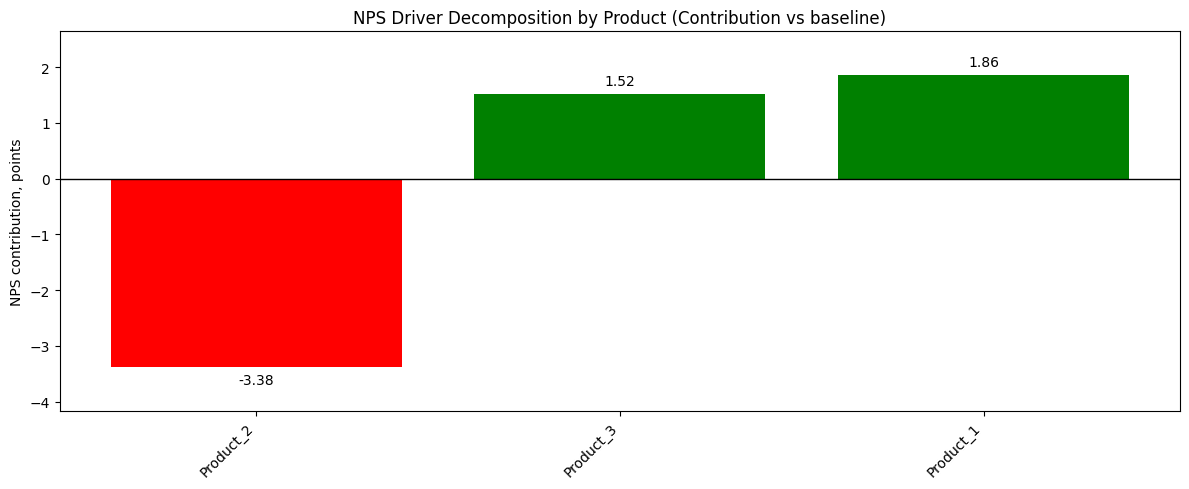

,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
survey_product_name,,,,,,,
Product_2,91834,43722,32459,12.264521,-4.184657,0.806984,-3.376952
Product_3,7941,4761,1725,38.231961,21.782783,0.069781,1.520023
Product_1,14024,7552,3132,31.517399,15.068221,0.123235,1.856930


In [64]:
# --- Diverging "waterfall-like" contributions around zero (PRODUCT) ---

plot_df = product_analysis.reset_index()[["survey_product_name", "nps_contribution"]].copy()
plot_df = plot_df.sort_values("nps_contribution")  # negatives left, positives right

labels = plot_df["survey_product_name"].astype(str).tolist()
values = plot_df["nps_contribution"].values

colors = np.where(values >= 0, "green", "red")

plt.figure(figsize=(12, 5))
plt.bar(labels, values, color=colors)
plt.axhline(0, color="black", linewidth=1)

vmin = values.min()
vmax = values.max()
pad = 0.15 * (vmax - vmin) if vmax != vmin else 1.0
plt.ylim(vmin - pad, vmax + pad)

for i, v in enumerate(values):
    va = "bottom" if v >= 0 else "top"
    offset = 0.02 * (vmax - vmin) if vmax != vmin else 0.1
    plt.text(i, v + (offset if v >= 0 else -offset), f"{v:.2f}", ha="center", va=va)

plt.title("NPS Driver Decomposition by Product (Contribution vs baseline)")
plt.ylabel("NPS contribution, points")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Top negative drivers (optional quick look)
product_analysis.sort_values("nps_contribution").head(5)

# **Вывод по гипотезе 3**

Результаты анализа показывают, что продукты по-разному влияют на общий показатель NPS.

Product_2 демонстрирует отрицательный вклад в общий NPS (-3.38 пункта). При этом данный продукт имеет наибольший вес в выборке (около 80% всех ответов), что делает его основным драйвером снижения общего показателя NPS.

Product_1 и Product_3, напротив, демонстрируют более высокий уровень удовлетворенности клиентов и вносят положительный вклад в общий NPS (+1.86 и +1.52 соответственно). Однако их влияние ограничено меньшей долей пользователей.

Таким образом, снижение общего NPS в первую очередь связано с пользовательским опытом клиентов Product_2.

Overall NPS  
│  
├─ H1: Канал взаимодействия - подтверждено  
│  
├─ H2: Пол  - не драйвер, но влияет на CX  
│  
├─ H3: Продукт - подтверждено, но влияет меньше чем канал взаимодействия  
│  
├─ H4: Месяц  
│  
└─ H5: Возраст


# **Conclusion for Hypothesis 3**

The results show that different products contribute differently to the overall NPS.

Product_2 demonstrates a negative contribution to the overall NPS (-3.38 points). At the same time, this product has the largest share of responses (around 80%), making it the primary driver of the overall NPS decline.

Product_1 and Product_3 show higher levels of customer satisfaction and contribute positively to the overall NPS (+1.86 and +1.52 respectively). However, their impact is limited due to their smaller share of respondents.

Therefore, the decrease in the overall NPS is mainly associated with the customer experience of Product_2.

Overall NPS  
│  
├─ H1: Survey channel - confirmed     
│  
├─ H2: Gender - not a driver, but affects CX  
│  
├─ H3: Product - confirmed, but affects less than Survey channel  
│  
├─ H4: Month  
│  
└─ H5: Age  

# **Гипотеза 4: влияние месяца на клиентский опыт**

Предполагается, что уровень удовлетворенности клиентов может изменяться в зависимости от месяца проведения опроса.

Если клиентский опыт имеет сезонность или временные колебания, то в разные месяцы пользователи могут демонстрировать разные значения NPS. В этом случае некоторые месяцы могут вносить отрицательный вклад в общий показатель NPS, тогда как другие месяцы могут улучшать общий уровень клиентской лояльности.

Цель данного анализа — определить, существуют ли временные периоды, которые оказывают значимое влияние на общий показатель NPS и могут рассматриваться как драйверы его снижения или роста.

# **Hypothesis 4: Impact of month on customer experience**

It is assumed that the level of customer satisfaction may vary depending on the month when the survey was conducted.

If customer experience demonstrates seasonality or temporal fluctuations, respondents from different months may show different NPS values. In this case, some months may contribute negatively to the overall NPS, while others may improve the overall level of customer loyalty.

The purpose of this analysis is to identify time periods that have a significant impact on the overall NPS and may act as drivers of its increase or decline.

In [65]:
# --- Month analysis ---

month_analysis = (
    df_work
    .groupby("Month")
    .agg(
        total_answers=("total_answers", "sum"),
        promoters=("promoters", "sum"),
        detractors=("detractors", "sum")
    )
)

# Calculate NPS
month_analysis["NPS"] = (
    (month_analysis["promoters"] - month_analysis["detractors"])
    / month_analysis["total_answers"]
) * 100

# Difference from baseline
month_analysis["diff_vs_baseline"] = month_analysis["NPS"] - baseline_nps

# Calculate weight
total_answers_all = month_analysis["total_answers"].sum()
month_analysis["weight"] = month_analysis["total_answers"] / total_answers_all

# NPS contribution
month_analysis["nps_contribution"] = (
    month_analysis["weight"] * month_analysis["diff_vs_baseline"]
)

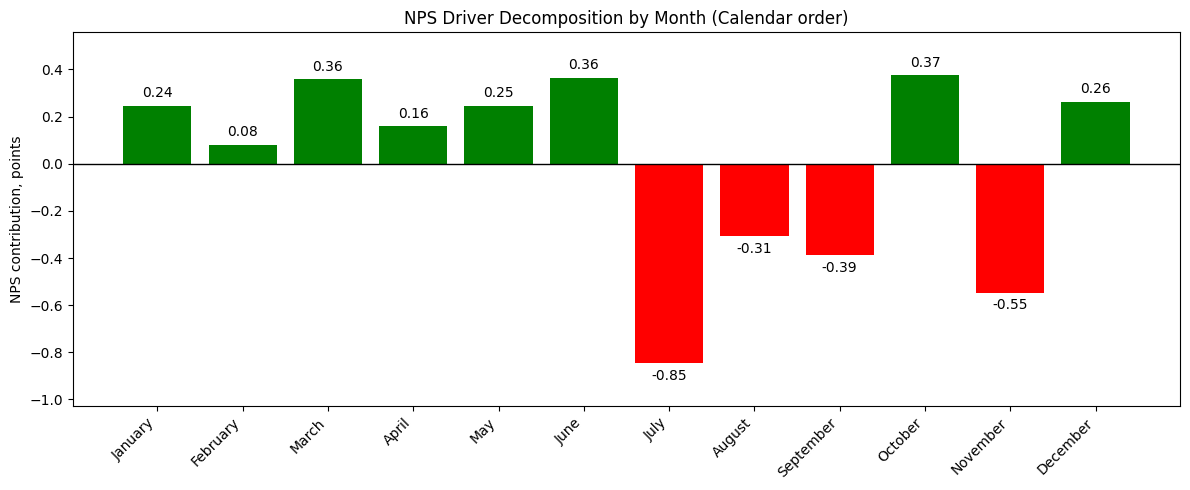

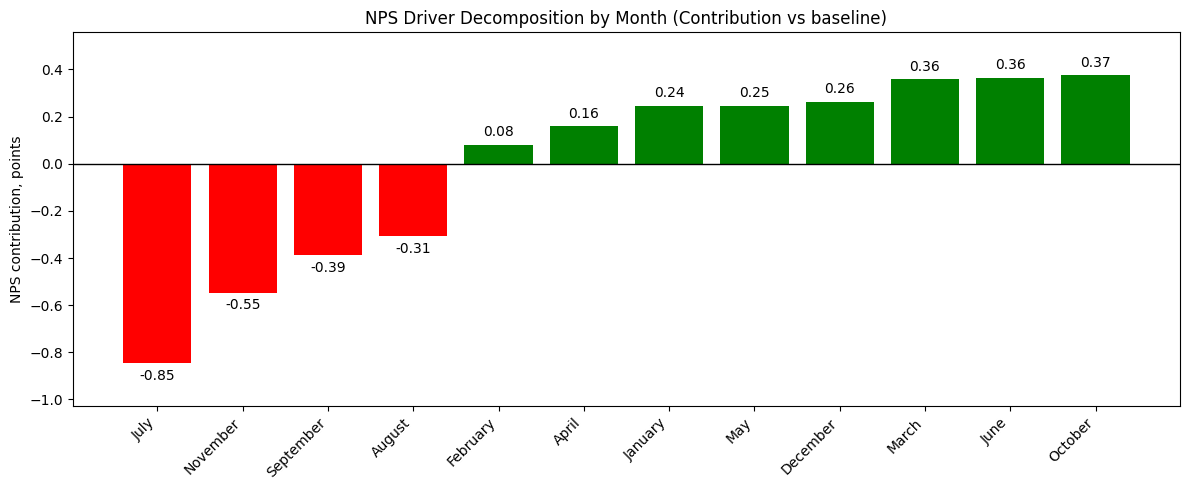

In [66]:
# --- Waterfall-like chart ordered by calendar months ---

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

plot_df = month_analysis.reset_index()[["Month","nps_contribution"]].copy()
plot_df["Month"] = pd.Categorical(plot_df["Month"], categories=month_order, ordered=True)
plot_df = plot_df.sort_values("Month")

labels = plot_df["Month"].astype(str).tolist()
values = plot_df["nps_contribution"].values

colors = np.where(values >= 0, "green", "red")

plt.figure(figsize=(12,5))
plt.bar(labels, values, color=colors)

plt.axhline(0, color="black", linewidth=1)

vmin = values.min()
vmax = values.max()
pad = 0.15 * (vmax - vmin) if vmax != vmin else 1.0
plt.ylim(vmin - pad, vmax + pad)

for i, v in enumerate(values):
    va = "bottom" if v > 0 else "top"
    offset = 0.02 * (vmax - vmin) if vmax != vmin else 0.1
    plt.text(i, v + (offset if v > 0 else -offset), f"{v:.2f}", ha="center", va=va)

plt.title("NPS Driver Decomposition by Month (Calendar order)")
plt.ylabel("NPS contribution, points")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# --- Diverging "waterfall-like" contributions around zero (MONTH) ---

plot_df = month_analysis.reset_index()[["Month", "nps_contribution"]].copy()

# сортируем по вкладу
plot_df = plot_df.sort_values("nps_contribution")

labels = plot_df["Month"].astype(str).tolist()
values = plot_df["nps_contribution"].values

colors = np.where(values >= 0, "green", "red")

plt.figure(figsize=(12,5))
plt.bar(labels, values, color=colors)

plt.axhline(0, color="black", linewidth=1)

vmin = values.min()
vmax = values.max()
pad = 0.15 * (vmax - vmin) if vmax != vmin else 1.0
plt.ylim(vmin - pad, vmax + pad)

for i, v in enumerate(values):
    va = "bottom" if v > 0 else "top"
    offset = 0.02 * (vmax - vmin) if vmax != vmin else 0.1
    plt.text(i, v + (offset if v > 0 else -offset), f"{v:.2f}", ha="center", va=va)

plt.title("NPS Driver Decomposition by Month (Contribution vs baseline)")
plt.ylabel("NPS contribution, points")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [67]:
month_analysis.sort_values("nps_contribution")

,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
Month,,,,,,,
July,11094,5048,4185,7.778980,-8.670198,0.097488,-0.845237
November,14394,6862,5116,12.130054,-4.319124,0.126486,-0.546309
September,15115,7336,5292,13.522990,-2.926188,0.132822,-0.388662
August,10110,4871,3557,12.997033,-3.452145,0.088841,-0.306692
February,6000,2892,1814,17.966667,1.517489,0.052725,0.080009
April,5436,2663,1588,19.775570,3.326392,0.047768,0.158897
January,6059,3006,1731,21.043076,4.593898,0.053243,0.244593
May,5934,2976,1721,21.149309,4.700131,0.052145,0.245086
December,14470,7411,4731,18.521078,2.071900,0.127154,0.263450


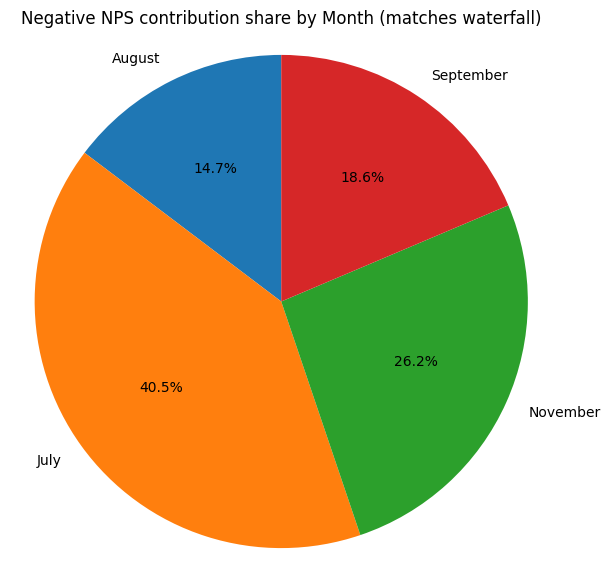

In [68]:
# --- Pie: share of negative NPS contribution (MONTH) ---

neg = month_analysis.reset_index()
neg = neg[neg["nps_contribution"] < 0].copy()

neg["abs_contrib"] = neg["nps_contribution"].abs()
neg["share"] = neg["abs_contrib"] / neg["abs_contrib"].sum()

plt.figure(figsize=(7,7))
plt.pie(
    neg["share"],
    labels=neg["Month"].astype(str),
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Negative NPS contribution share by Month (matches waterfall)")
plt.axis("equal")
plt.show()

# **Вывод по гипотезе 4**

Анализ показывает, что несколько месяцев вносят отрицательный вклад в общий показатель NPS.

Наибольший отрицательный вклад наблюдается в июле (-0.85 пункта), что делает его самым сильным негативным драйвером среди месяцев. Также отрицательные вклады наблюдаются в ноябре (-0.55 пункта), сентябре (-0.39 пункта) и августе (-0.31 пункта).

Круговая диаграмма отрицательных вкладов подтверждает распределение влияния между этими месяцами. На июль приходится 40.5% всего негативного вклада в NPS, на ноябрь — 26.2%, на сентябрь — 18.6%, на август — 14.7%.

Таким образом, основная часть негативного влияния временного фактора сосредоточена в июле и ноябре.

При этом величина вкладов по месяцам значительно ниже, чем вклад драйверов, связанных с продуктом или каналом взаимодействия. Например, отрицательный вклад Product_2 составляет -3.38 пункта NPS, что существенно превышает вклад любого отдельного месяца.

Следовательно, фактор месяца действительно влияет на общий показатель NPS и может рассматриваться как драйвер клиентского опыта, однако его влияние заметно слабее по сравнению с драйверами, связанными с продуктом или каналом взаимодействия.

Overall NPS  
│  
├─ H1: Канал взаимодействия - подтверждено  
│  
├─ H2: Пол  - не драйвер, но влияет на CX  
│  
├─ H3: Продукт - подтверждено, но влияет меньше чем канал взаимодействия  
│  
├─ H4: Месяц - подтверждено, но влияет меньше чем канал взаимодействия  
│  
└─ H5: Возраст


# **Conclusion for Hypothesis 4**

The analysis reveals that several months contribute negatively to the overall NPS.

The largest negative contribution is observed in July (-0.85 points), making it the strongest negative driver among the months. Other months with negative contributions include November (-0.55 points), September (-0.39 points), and August (-0.31 points).

The pie chart of negative NPS contributions confirms this distribution of impact. July accounts for 40.5% of the total negative NPS contribution, followed by November with 26.2%, September with 18.6%, and August with 14.7%.

Thus, most of the negative monthly impact on NPS is concentrated in July and November.

However, the magnitude of these monthly contributions remains smaller than the impact of other drivers identified in the analysis, such as product or survey channel segments. For example, the negative contribution of Product_2 alone equals -3.38 NPS points, which is significantly larger than the contribution of any individual month.

Therefore, the month factor does influence the overall NPS and can be considered a driver of customer experience, but its impact is noticeably weaker compared to product- or channel-related drivers.

Overall NPS  
│  
├─ H1: Survey channel - confirmed     
│  
├─ H2: Gender - not a driver, but affects CX  
│  
├─ H3: Product - confirmed, but affects less than Survey channel  
│  
├─ H4: Month - confirmed, but affects less than Survey channel  
│  
└─ H5: Age  

# **Гипотеза H5 (Возраст):**

Возрастные группы по-разному влияют на общий NPS.
Предполагается, что некоторые возрастные сегменты имеют NPS ниже baseline и из-за своего веса в выборке вносят отрицательный вклад в общий NPS.
Следовательно, возраст может выступать драйвером снижения NPS.

# **Hypothesis H5 (Age):**

Different age groups contribute differently to the overall NPS.
Some age segments may have NPS below the baseline and, due to their share in the sample, create a negative contribution to the overall NPS.
Therefore, age may act as a driver of NPS decline.

In [69]:
# --- Age analysis ---

age_analysis = (
    df_work
    .groupby("age_group")
    .agg(
        total_answers=("total_answers", "sum"),
        promoters=("promoters", "sum"),
        detractors=("detractors", "sum")
    )
)

# Calculate NPS
age_analysis["NPS"] = (
    (age_analysis["promoters"] - age_analysis["detractors"])
    / age_analysis["total_answers"]
) * 100

# Difference from baseline
age_analysis["diff_vs_baseline"] = age_analysis["NPS"] - baseline_nps

# Calculate weight
total_answers_all = age_analysis["total_answers"].sum()
age_analysis["weight"] = age_analysis["total_answers"] / total_answers_all

# NPS contribution
age_analysis["nps_contribution"] = (
    age_analysis["weight"] * age_analysis["diff_vs_baseline"]
)

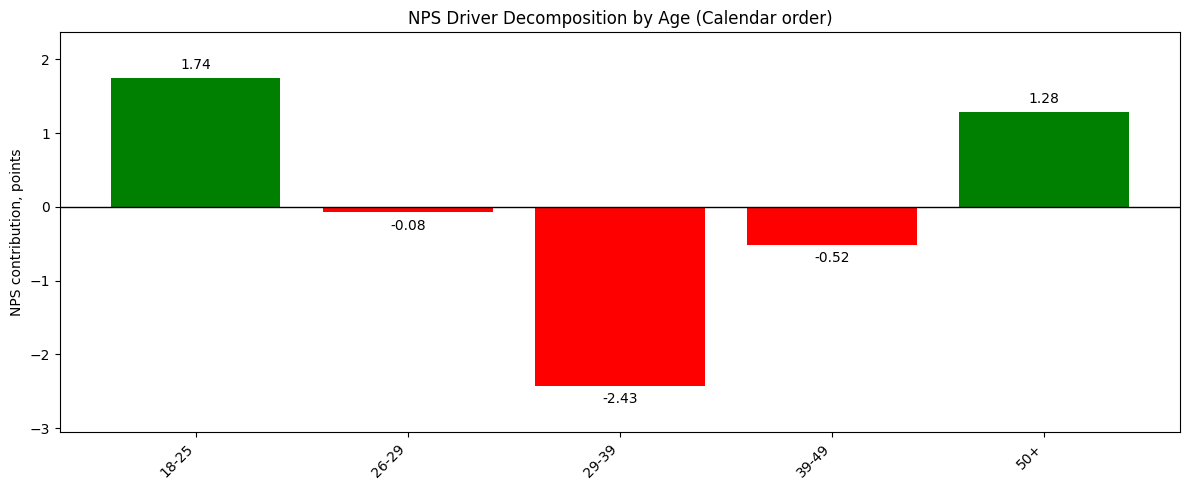

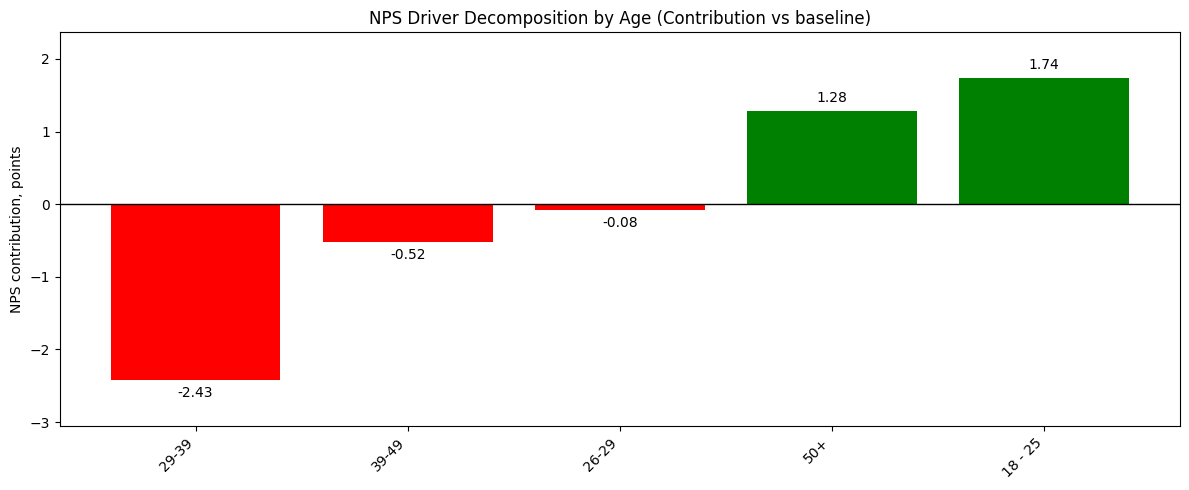

In [70]:
# --- Order age groups for plotting (Age) ---

age_order = ["18-25", "26-29", "29-39", "39-49", "50+"]

plot_df = age_analysis.reset_index()[["age_group", "nps_contribution"]].copy()

# 1) Нормализуем значение age_group так, чтобы совпало с age_order
plot_df["age_group"] = (
    plot_df["age_group"]
    .astype(str)
    .str.replace("–", "-", regex=False)   # длинное тире -> дефис
    .str.replace("—", "-", regex=False)   # ещё один тип тире -> дефис
    .str.replace(" ", "", regex=False)    # убрать пробелы
)

# 2) Теперь делаем categorical и сортируем
plot_df["age_group"] = pd.Categorical(plot_df["age_group"], categories=age_order, ordered=True)
plot_df = plot_df.sort_values("age_group")

labels = plot_df["age_group"].astype(str).tolist()
values = plot_df["nps_contribution"].values

colors = np.where(values >= 0, "green", "red")

plt.figure(figsize=(12,5))
plt.bar(labels, values, color=colors)
plt.axhline(0, color="black", linewidth=1)

vmin, vmax = values.min(), values.max()
pad = 0.15 * (vmax - vmin) if vmax != vmin else 1.0
plt.ylim(vmin - pad, vmax + pad)

for i, v in enumerate(values):
    va = "bottom" if v > 0 else "top"
    offset = 0.02 * (vmax - vmin) if vmax != vmin else 0.1
    plt.text(i, v + (offset if v > 0 else -offset), f"{v:.2f}", ha="center", va=va)

plt.title("NPS Driver Decomposition by Age (Calendar order)")
plt.ylabel("NPS contribution, points")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --- Diverging "waterfall-like" contributions around zero (AGE) ---

plot_df = age_analysis.reset_index()[["age_group", "nps_contribution"]].copy()
plot_df = plot_df.sort_values("nps_contribution")

labels = plot_df["age_group"].astype(str).tolist()
values = plot_df["nps_contribution"].values

colors = np.where(values >= 0, "green", "red")

plt.figure(figsize=(12,5))
plt.bar(labels, values, color=colors)

plt.axhline(0, color="black", linewidth=1)

vmin = values.min()
vmax = values.max()
pad = 0.15 * (vmax - vmin) if vmax != vmin else 1.0
plt.ylim(vmin - pad, vmax + pad)

for i, v in enumerate(values):
    va = "bottom" if v > 0 else "top"
    offset = 0.02 * (vmax - vmin) if vmax != vmin else 0.1
    plt.text(i, v + (offset if v > 0 else -offset), f"{v:.2f}", ha="center", va=va)

plt.title("NPS Driver Decomposition by Age (Contribution vs baseline)")
plt.ylabel("NPS contribution, points")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [71]:
age_analysis.sort_values("nps_contribution")

,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
age_group,,,,,,,
29-39,36559,16502,13250,8.895210,-7.553967,0.321259,-2.426783
39-49,32777,16251,11453,14.638313,-1.810864,0.288025,-0.521575
26-29,11580,5408,3590,15.699482,-0.749696,0.101758,-0.076288
50+,19682,10835,6136,23.874606,7.425428,0.172954,1.284258
18 - 25,13201,7039,2887,31.452163,15.002985,0.116003,1.740388


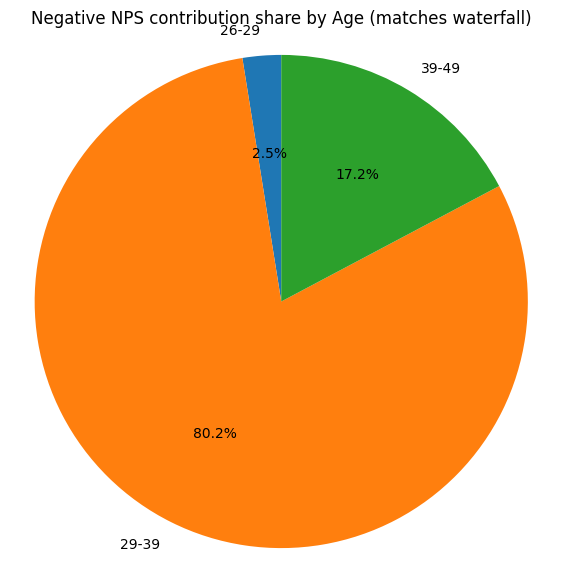

In [72]:
# --- Pie: share of negative NPS contribution (AGE) ---

neg = age_analysis.reset_index()
neg = neg[neg["nps_contribution"] < 0].copy()

neg["abs_contrib"] = neg["nps_contribution"].abs()
neg["share"] = neg["abs_contrib"] / neg["abs_contrib"].sum()

plt.figure(figsize=(7,7))
plt.pie(
    neg["share"],
    labels=neg["age_group"].astype(str),
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Negative NPS contribution share by Age (matches waterfall)")
plt.axis("equal")
plt.show()

# **Вывод по гипотезе H5 (Возраст):**

Основным драйвером снижения NPS является возрастная группа 29–39.

Согласно waterfall-диаграмме, её вклад составляет −2.43 пункта NPS, что является самым большим отрицательным вкладом среди всех возрастных сегментов.

Вторая по влиянию группа — 39–49, её вклад −0.52 пункта NPS.\
Группа 26–29 оказывает минимальное отрицательное влияние (−0.08 пункта).

Pie-chart отрицательных вкладов показывает распределение влияния:

29–39 — 80.2% всего негативного вклада\
39–49 — 17.2%\
26–29 — 2.5%

Таким образом, подавляющая часть снижения NPS связана с возрастной группой 29–39.

При этом вклад возрастных сегментов в снижение NPS меньше, чем вклад факторов продукта и канала, выявленных ранее, поэтому возраст можно считать вторичным драйвером NPS.

Overall NPS  
│  
├─ H1: Канал взаимодействия - подтверждено  
│  
├─ H2: Пол  - не драйвер, но влияет на CX  
│  
├─ H3: Продукт - подтверждено, но влияет меньше чем канал взаимодействия  
│  
├─ H4: Месяц - подтверждено, но влияет меньше чем канал взаимодействия  
│  
└─ H5: Возраст - подтверждено, но влияет меньше чем канал взаимодействия  

# **Conclusion for Hypothesis H5 (Age):**

The main driver of NPS decline is the 29–39 age group.

According to the waterfall chart, this segment contributes −2.43 NPS points, which is the largest negative contribution among all age groups.

The second largest negative driver is the 39–49 group with −0.52 NPS points.\
The 26–29 group has a very small negative impact (−0.08 NPS points).

The pie chart of negative contributions shows the distribution:

29–39 — 80.2% of the total negative contribution\
39–49 — 17.2%\
26–29 — 2.5%

Thus, the vast majority of the NPS decline is driven by the 29–39 age segment.

However, the magnitude of the age effect is smaller than the previously identified drivers related to product and channel, so age should be considered a secondary NPS driver.

Overall NPS  
│  
├─ H1: Survey channel - confirmed     
│  
├─ H2: Gender - not a driver, but affects CX  
│  
├─ H3: Product - confirmed, but affects less than Survey channel  
│  
├─ H4: Month - confirmed, but affects less than Survey channel  
│  
└─ H5: Age - confirmed, but affects less than Survey channel  

,driver category,segment,nps_contribution
0,Survey_channel,VoiceBot,-5.85
1,Survey_product_name,Product_2,-3.38
2,age_group,29–39,-2.43
3,Month,July,-0.85


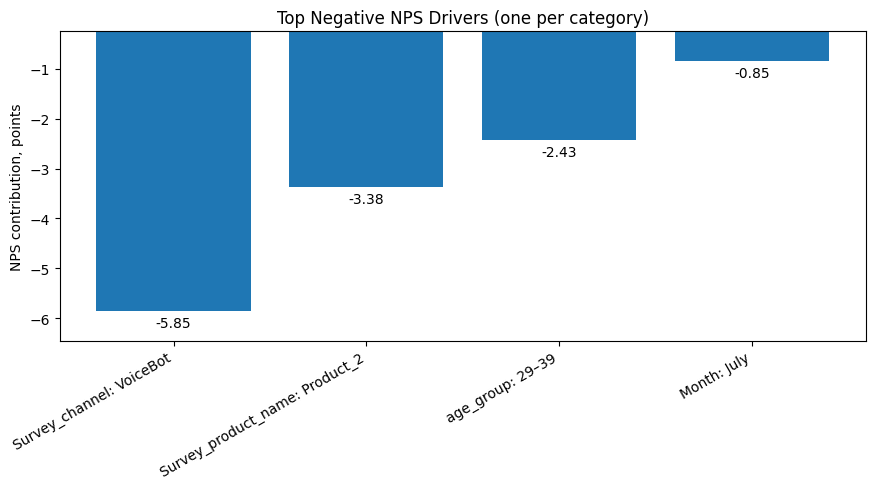

In [73]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# --- Top negative drivers (one per category) ---
drivers = pd.DataFrame({
    "driver category": ["Survey_channel", "Survey_product_name", "age_group", "Month"],
    "segment":  ["VoiceBot", "Product_2", "29–39", "July"],
    "nps_contribution": [-5.85, -3.38, -2.43, -0.85],
})

# Table (sorted by strongest negative)
drivers_table = drivers.sort_values("nps_contribution").reset_index(drop=True)
display(drivers_table)

# --- Bar chart (4 bars) ---
plot_df = drivers_table.copy()

labels = [f"{c}: {s}" for c, s in zip(plot_df["driver category"], plot_df["segment"])]
values = plot_df["nps_contribution"].values

plt.figure(figsize=(9,5))
plt.bar(labels, values)
plt.axhline(0, color="black", linewidth=1)

# value labels
vmin, vmax = values.min(), values.max()
pad = 0.12 * (vmax - vmin) if vmax != vmin else 0.5
plt.ylim(vmin - pad, vmax + pad)

for i, v in enumerate(values):
    va = "top" if v < 0 else "bottom"
    offset = 0.02 * (vmax - vmin) if vmax != vmin else 0.1
    plt.text(i, v - offset if v < 0 else v + offset, f"{v:.2f}", ha="center", va=va)

plt.title("Top Negative NPS Drivers (one per category)")
plt.ylabel("NPS contribution, points")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# **Вывод по графику Top Negative NPS Drivers (one per category)**

Топ-негативные драйверы по категориям показывают, куда делать drilldown в первую очередь. Самый сильный негативный вклад даёт канал VoiceBot: −5.85 п. Далее идут Product_2: −3.38 п., возрастная группа 29–39: −2.43 п. и месяц July: −0.85 п. Следовательно, первичный drilldown нужно начинать с VoiceBot, так как его вклад существенно больше остальных.

# **Conclusion for Top Negative NPS Drivers (one per category)**

The top negative drivers by category indicate where to drill down first. The strongest negative contribution comes from the VoiceBot channel: −5.85 pts. Next are Product_2: −3.38 pts, Age 29–39: −2.43 pts, and Month July: −0.85 pts.
Therefore, the primary drilldown should start with VoiceBot, as its impact is materially larger than the others.

In [74]:
df_filtered = df_work[df_work["total_answers"] >= 10]


===== Channel: raw / filtered / delta / delta_pct (sorted by delta_pct asc) =====


,raw,filtered,delta,delta_pct
survey_channel,,,,
Email,0.412626,0.395907,-0.016719,-4.051850
SMS,-2.074345,-2.051591,0.022755,-1.096961
Telegram,7.498574,7.580563,0.081989,1.093395
VoiceBot,-5.854099,-5.922817,-0.068718,1.173849
Unknown,-0.000723,NaN,NaN,NaN
Website,0.017967,NaN,NaN,NaN


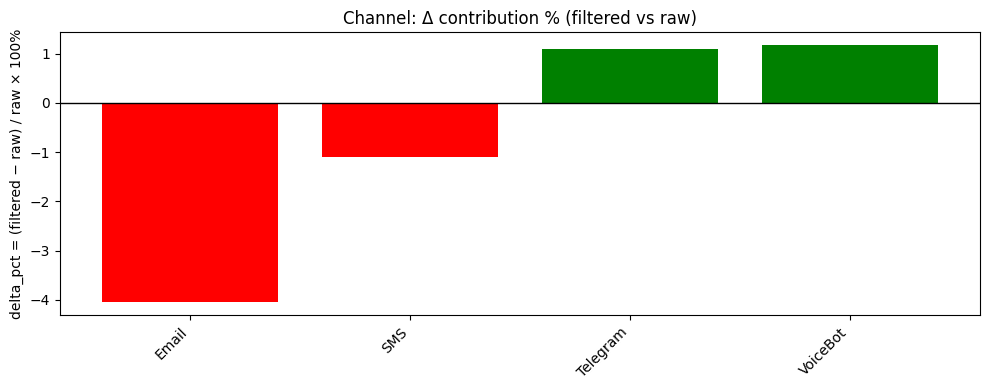


===== Gender: raw / filtered / delta / delta_pct (sorted by delta_pct asc) =====


,raw,filtered,delta,delta_pct
gender_id,,,,
Male,-6.896985,-6.936702,-0.039717,0.575862
Female,6.896985,6.938764,0.041779,0.605762


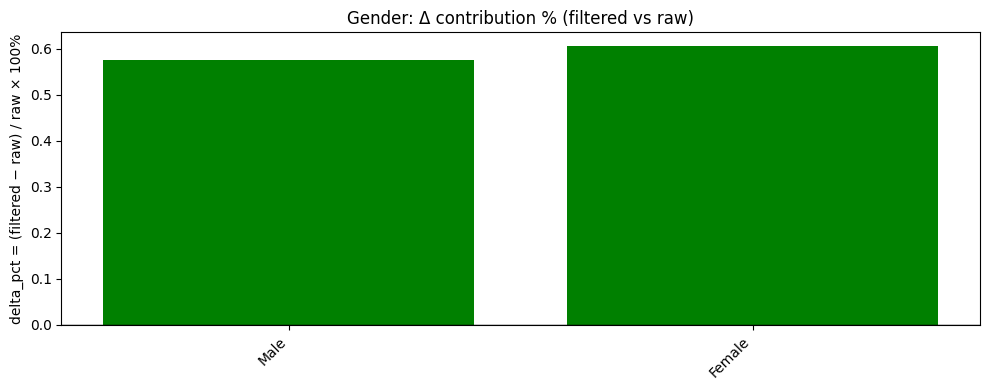


===== Product: raw / filtered / delta / delta_pct (sorted by delta_pct asc) =====


,raw,filtered,delta,delta_pct
survey_product_name,,,,
Product_3,1.520023,1.551607,0.031584,2.077891
Product_2,-3.376952,-3.450626,-0.073673,2.181647
Product_1,1.856930,1.901081,0.044151,2.377631


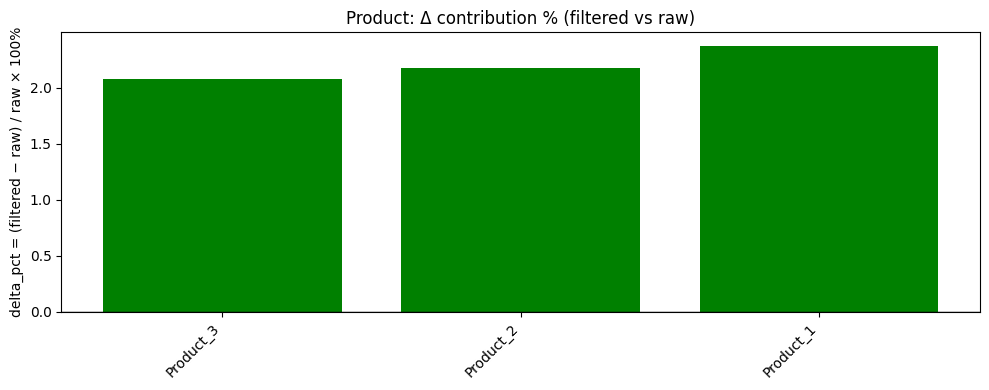


===== Month: raw / filtered / delta / delta_pct (sorted by delta_pct asc) =====


,raw,filtered,delta,delta_pct
Month,,,,
December,0.263450,0.251680,-0.011771,-4.467828
February,0.080009,0.079123,-0.000886,-1.107732
July,-0.845237,-0.845831,-0.000593,0.070170
October,0.374378,0.376818,0.002439,0.651573
August,-0.306692,-0.309738,-0.003047,0.993347
January,0.244593,0.248131,0.003538,1.446480
May,0.245086,0.248911,0.003825,1.560505
November,-0.546309,-0.561134,-0.014824,2.713545
March,0.357272,0.367374,0.010102,2.827478


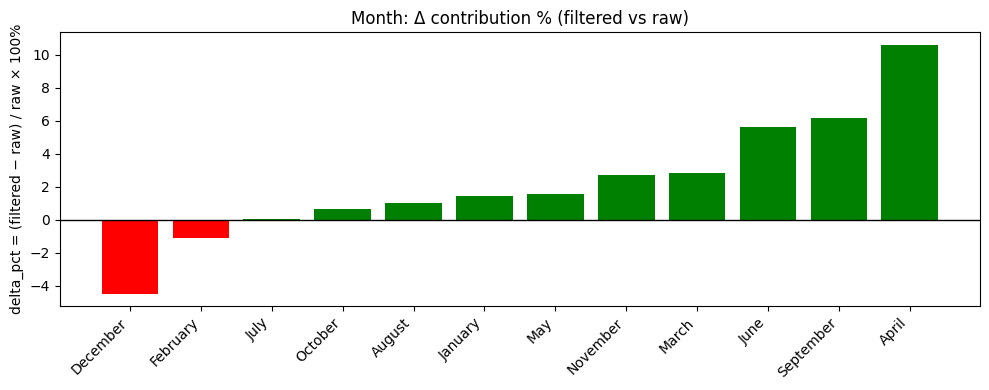


===== Age: raw / filtered / delta / delta_pct (sorted by delta_pct asc) =====


,raw,filtered,delta,delta_pct
age_group,,,,
26-29,-0.076288,-0.068130,0.008158,-10.693243
39-49,-0.521575,-0.508363,0.013212,-2.533092
18 - 25,1.740388,1.733045,-0.007343,-0.421904
29-39,-2.426783,-2.458323,-0.031540,1.299656
50+,1.284258,1.303833,0.019575,1.524238


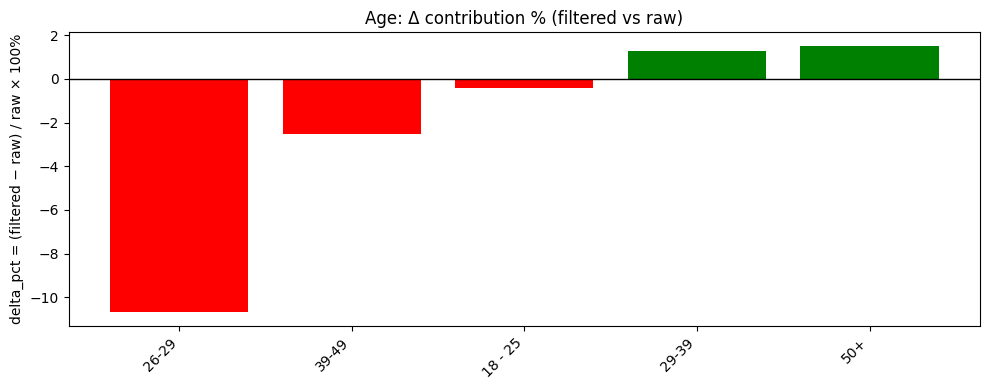


===== ALL dimensions combined: raw / filtered / delta / delta_pct (sorted by delta_pct asc) =====


,raw,filtered,delta,delta_pct
dim_segment,,,,
Age | 26-29,-0.076288,-0.068130,0.008158,-10.693243
Month | December,0.263450,0.251680,-0.011771,-4.467828
Channel | Email,0.412626,0.395907,-0.016719,-4.051850
Age | 39-49,-0.521575,-0.508363,0.013212,-2.533092
Month | February,0.080009,0.079123,-0.000886,-1.107732
Channel | SMS,-2.074345,-2.051591,0.022755,-1.096961
Age | 18 - 25,1.740388,1.733045,-0.007343,-0.421904
Month | July,-0.845237,-0.845831,-0.000593,0.070170
Gender | Male,-6.896985,-6.936702,-0.039717,0.575862


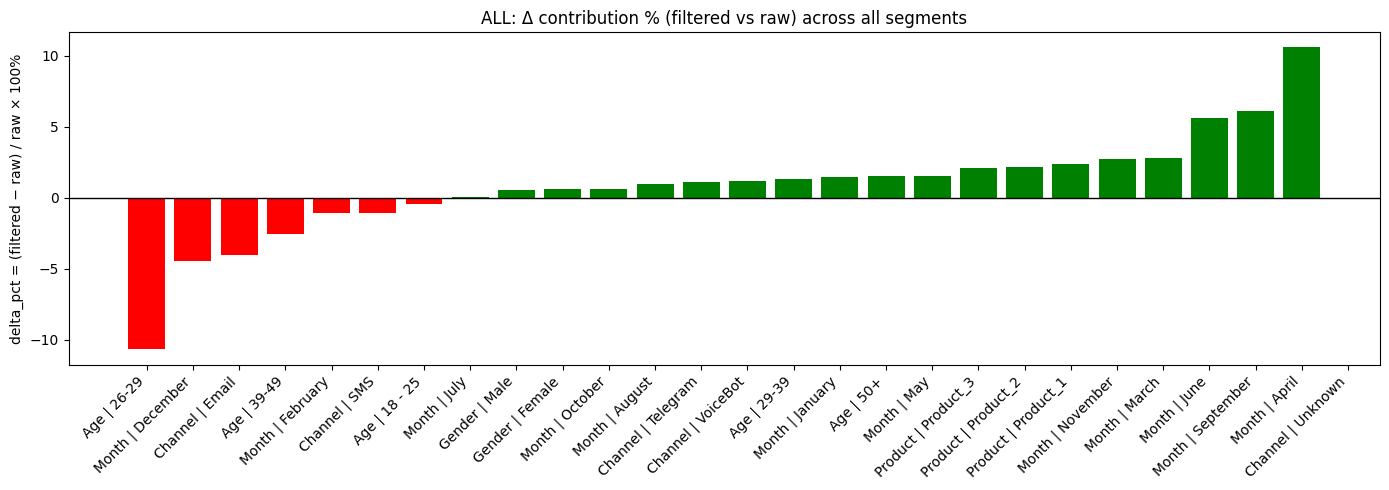


===== Summary of |delta| by dimension + top driver % impact =====
count = number of segments in this dimension
top_driver_segment = segment with MIN(filtered) i.e. strongest negative driver in filtered


,count,mean_abs_delta,median_abs_delta,max_abs_delta,top_driver_segment,top_driver_delta_pct
dimension,,,,,,
Channel,6,0.047545,0.045737,0.081989,VoiceBot,1.173849
Product,3,0.049803,0.044151,0.073673,Product_2,2.181647
Gender,2,0.040748,0.040748,0.041779,Male,0.575862
Age,5,0.015965,0.013212,0.031540,29-39,1.299656
Month,12,0.009338,0.006963,0.023873,July,0.070170


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# df_work      - raw data
# df_filtered  - filtered data
# baseline_nps - scalar

# -----------------------------
# 1) Compute driver contributions (your logic)
# -----------------------------
def compute_driver_table(df: pd.DataFrame, group_col: str, baseline_nps: float) -> pd.DataFrame:
    t = (
        df.groupby(group_col)
          .agg(
              total_answers=("total_answers", "sum"),
              promoters=("promoters", "sum"),
              detractors=("detractors", "sum"),
          )
    )
    t["NPS"] = (t["promoters"] - t["detractors"]) / t["total_answers"] * 100.0
    t["diff_vs_baseline"] = t["NPS"] - float(baseline_nps)
    total_all = t["total_answers"].sum()
    t["weight"] = t["total_answers"] / total_all
    t["nps_contribution"] = t["weight"] * t["diff_vs_baseline"]
    return t


# -----------------------------
# 2) Compare raw vs filtered (result table only)
# -----------------------------
def make_delta_table(raw_tbl: pd.DataFrame, flt_tbl: pd.DataFrame) -> pd.DataFrame:
    comp = (
        raw_tbl[["nps_contribution"]].rename(columns={"nps_contribution": "raw"})
        .join(
            flt_tbl[["nps_contribution"]].rename(columns={"nps_contribution": "filtered"}),
            how="outer"
        )
    )

    # absolute delta (keep if you want, but we won't plot it)
    comp["delta"] = comp["filtered"] - comp["raw"]  # + => filtered higher than raw

    # percent delta
    # (filtered - raw) / raw * 100
    # protect division by zero
    comp["delta_pct"] = np.where(
        comp["raw"].notna() & (comp["raw"] != 0),
        (comp["filtered"] - comp["raw"]) / comp["raw"] * 100.0,
        np.nan
    )

    comp.index = comp.index.astype(str)

    # IMPORTANT: sort by percent delta for our new goal
    comp = comp.sort_values("delta_pct", ascending=True)
    return comp


# -----------------------------
# 3) Plot deltas in PERCENT (sorted, red/green)
# -----------------------------
def plot_delta_pct_sorted(comp: pd.DataFrame, title: str, figsize=(10, 4)):
    comp_sorted = comp.sort_values("delta_pct", ascending=True)

    labels = comp_sorted.index.astype(str).tolist()
    vals = comp_sorted["delta_pct"].values
    colors = np.where(vals >= 0, "green", "red")

    plt.figure(figsize=figsize)
    plt.bar(labels, vals, color=colors)
    plt.axhline(0, color="black", linewidth=1)
    plt.title(title)
    plt.ylabel("delta_pct = (filtered − raw) / raw × 100%")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


# -----------------------------
# 4) Dimensions (check column names!)
# -----------------------------
DIMENSIONS = {
    "Channel": "survey_channel",
    "Gender": "gender_id",
    "Product": "survey_product_name",
    "Month": "Month",
    "Age": "age_group",
}


# -----------------------------
# 5) Build delta tables + plots (per dimension)
# -----------------------------
delta_tables = {}

for dim_name, col in DIMENSIONS.items():
    raw_tbl = compute_driver_table(df_work, col, baseline_nps)
    flt_tbl = compute_driver_table(df_filtered, col, baseline_nps)

    comp = make_delta_table(raw_tbl, flt_tbl)

    print(f"\n===== {dim_name}: raw / filtered / delta / delta_pct (sorted by delta_pct asc) =====")
    display(comp[["raw", "filtered", "delta", "delta_pct"]])

    plot_delta_pct_sorted(
        comp,
        title=f"{dim_name}: Δ contribution % (filtered vs raw)",
        figsize=(10, 4)
    )

    delta_tables[dim_name] = comp


# -----------------------------
# 6) Combined table across ALL dimensions (dimension|segment in index)
# -----------------------------
all_comp_list = []

for dim_name, comp in delta_tables.items():
    tmp = comp.copy()
    tmp["dimension"] = dim_name
    tmp["segment"] = tmp.index.astype(str)
    tmp["dim_segment"] = tmp["dimension"] + " | " + tmp["segment"]
    tmp = tmp.set_index("dim_segment")[["raw", "filtered", "delta", "delta_pct"]]
    all_comp_list.append(tmp)

all_comp = pd.concat(all_comp_list, axis=0).sort_values("delta_pct", ascending=True)

print("\n===== ALL dimensions combined: raw / filtered / delta / delta_pct (sorted by delta_pct asc) =====")
display(all_comp)

plot_delta_pct_sorted(
    all_comp,
    title="ALL: Δ contribution % (filtered vs raw) across all segments",
    figsize=(14, 5)
)


# -----------------------------
# 7) Summary of |delta| by dimension + NEW last column
#    NEW: top_driver_delta_pct = % change of the main (most negative) driver in FILTERED
# -----------------------------
def make_summary(delta_tables: dict) -> pd.DataFrame:
    rows = []

    for dim, t in delta_tables.items():
        d = t.copy()

        # abs delta in absolute points (kept same idea as before)
        d["abs_delta"] = d["delta"].abs()

        # pick "top negative driver" in filtered (most negative)
        # if filtered all NaN -> skip safely
        if d["filtered"].notna().any():
            top_idx = d["filtered"].idxmin()
            top_raw = d.loc[top_idx, "raw"]
            top_filtered = d.loc[top_idx, "filtered"]

            if pd.notna(top_raw) and top_raw != 0:
                top_driver_delta_pct = (top_filtered - top_raw) / top_raw * 100.0
            else:
                top_driver_delta_pct = np.nan
        else:
            top_idx = None
            top_driver_delta_pct = np.nan

        rows.append({
            "dimension": dim,
            "count": int(d.shape[0]),
            "mean_abs_delta": d["abs_delta"].mean(),
            "median_abs_delta": d["abs_delta"].median(),
            "max_abs_delta": d["abs_delta"].max(),
            "top_driver_segment": str(top_idx) if top_idx is not None else None,
            "top_driver_delta_pct": top_driver_delta_pct,  # <-- requested NEW column
        })

    out = pd.DataFrame(rows).set_index("dimension")

    # sort like before: strongest dimension by max abs delta
    out = out.sort_values("max_abs_delta", ascending=False)
    return out


summary = make_summary(delta_tables)

print("\n===== Summary of |delta| by dimension + top driver % impact =====")
print("count = number of segments in this dimension")
print("top_driver_segment = segment with MIN(filtered) i.e. strongest negative driver in filtered")
display(summary)

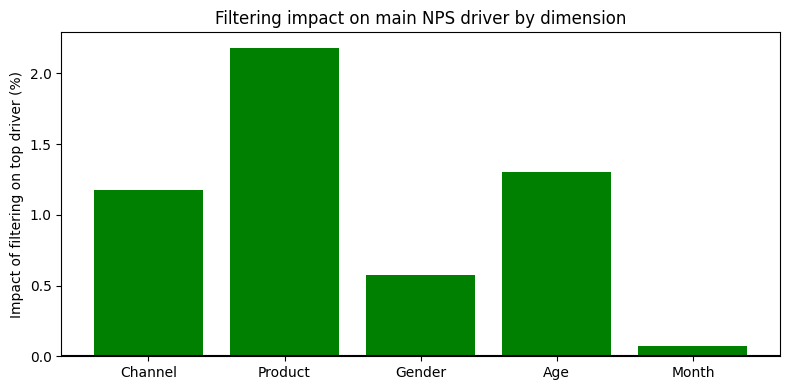

In [76]:
plt.figure(figsize=(8,4))

x = summary.index
y = summary["top_driver_delta_pct"]

colors = np.where(y >= 0, "green", "red")

plt.bar(x, y, color=colors)

plt.axhline(0, color="black")

plt.ylabel("Impact of filtering on top driver (%)")
plt.title("Filtering impact on main NPS driver by dimension")

plt.tight_layout()
plt.show()

# **Вывод по графику Filtering impact on main NPS driver by dimension**

Фильтрация (удаление малых сегментов из витрины данных, с Num_answers < 10) слабо влияет на топ-негативный драйвер внутри каждого измерения. Максимальный эффект наблюдается в Product: ~2.2%, далее Age: ~1.3%, Channel: ~1.17%, Gender: ~0.58%, а для Month: ~0.07% эффект практически нулевой.
Значит, вывод “главный драйвер” устойчив: фильтрация меняет величины вкладов на уровне примерно до 2.2% для топ-драйвера измерения.

# **Conclusion for Filtering impact on main NPS driver by dimension**

Filtering (removing small segments from the aggregated table, with Num_answers < 10) has a limited impact on the top negative driver within each dimension. The largest effect is in Product: ~2.2%, followed by Age: ~1.3%, Channel: ~1.17%, Gender: ~0.58%, while Month: ~0.07% is essentially negligible.
This means the “main driver” conclusion is robust: filtering changes the top-driver contribution by roughly up to 2.2% within a dimension.

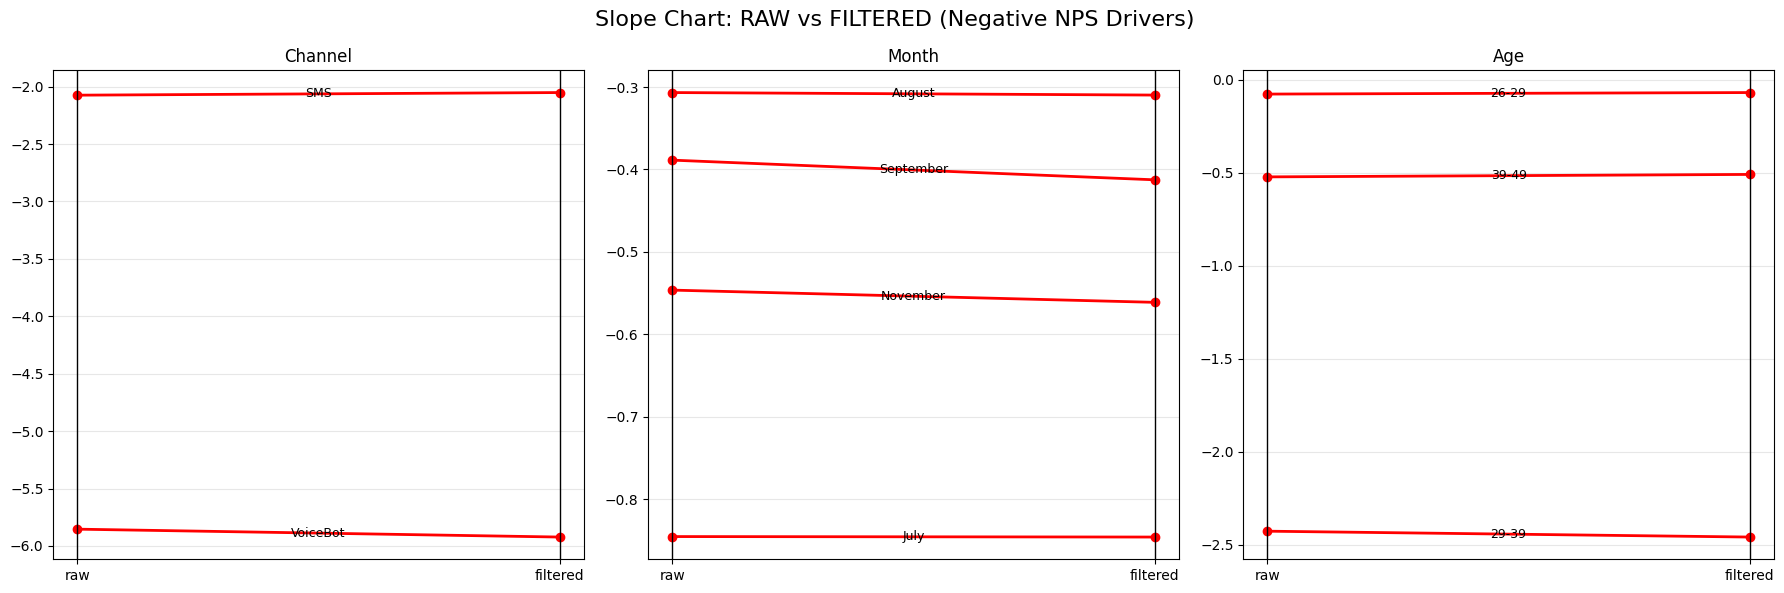

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------------
# Prepare negative drivers
# -----------------------------
def get_negative_drivers(comp):

    df = comp.copy()

    df = df.dropna(subset=["raw","filtered"])

    df = df[(df["raw"] < 0) | (df["filtered"] < 0)]

    df = df.sort_values("filtered", ascending=True)

    return df


# -----------------------------
# Plot slope chart
# -----------------------------
def draw_slope(ax, df, title):

    if df.empty:
        ax.set_title(title + "\n(no negative drivers)")
        return

    labels = df.index.astype(str)

    y_left = df["raw"].values
    y_right = df["filtered"].values

    x0 = 0
    x1 = 1

    for i in range(len(labels)):

        color = "red" if y_right[i] < 0 else "green"

        ax.plot(
            [x0, x1],
            [y_left[i], y_right[i]],
            marker="o",
            linewidth=2,
            color=color
        )

        ax.text(
            0.5,
            (y_left[i] + y_right[i]) / 2,
            labels[i],
            ha="center",
            va="center",
            fontsize=9
        )

    ax.set_xticks([0,1])
    ax.set_xticklabels(["raw","filtered"])

    ax.set_title(title)

    ax.axvline(x0, color="black", linewidth=1)
    ax.axvline(x1, color="black", linewidth=1)

    ax.grid(axis="y", alpha=0.3)


# -----------------------------
# Dimensions where ranking matters
# -----------------------------
DRIVER_DIMS = [
    "Channel",
    "Month",
    "Age"
]


# -----------------------------
# Plot charts
# -----------------------------
fig, axes = plt.subplots(1,3, figsize=(18,6))

for ax, dim in zip(axes, DRIVER_DIMS):

    comp = delta_tables[dim]

    df_neg = get_negative_drivers(comp)

    draw_slope(ax, df_neg, dim)


plt.suptitle(
    "Slope Chart: RAW vs FILTERED (Negative NPS Drivers)",
    fontsize=16
)

plt.tight_layout()

plt.show()

# **Вывод по slope chart RAW vs FILTERED (Negative NPS Drivers)**

Slope chart для негативных драйверов показывает, что ранги драйверов не изменились после фильтрации: линии между RAW и FILTERED не пересекаются. Это видно для всех отображённых измерений (Channel, Month, Age): порядок “кто хуже/лучше” остаётся тем же, меняются только сами значения вкладов.
Следовательно, фильтрация не перетасовала выводы: можно уверенно продолжать drilldown по VoiceBot как главному негативному драйверу.

# **Conclusion for slope chart RAW vs FILTERED (Negative NPS Drivers)**

The slope chart for negative drivers shows that driver ranks do not change after filtering: there are no line crossings between RAW and FILTERED. This is consistent across the displayed dimensions (Channel, Month, Age): the ordering of more negative vs less negative stays the same, while only the numeric contributions shift slightly. Therefore, filtering did not reshuffle conclusions, and we can confidently proceed with drilldown on VoiceBot as the main negative driver.

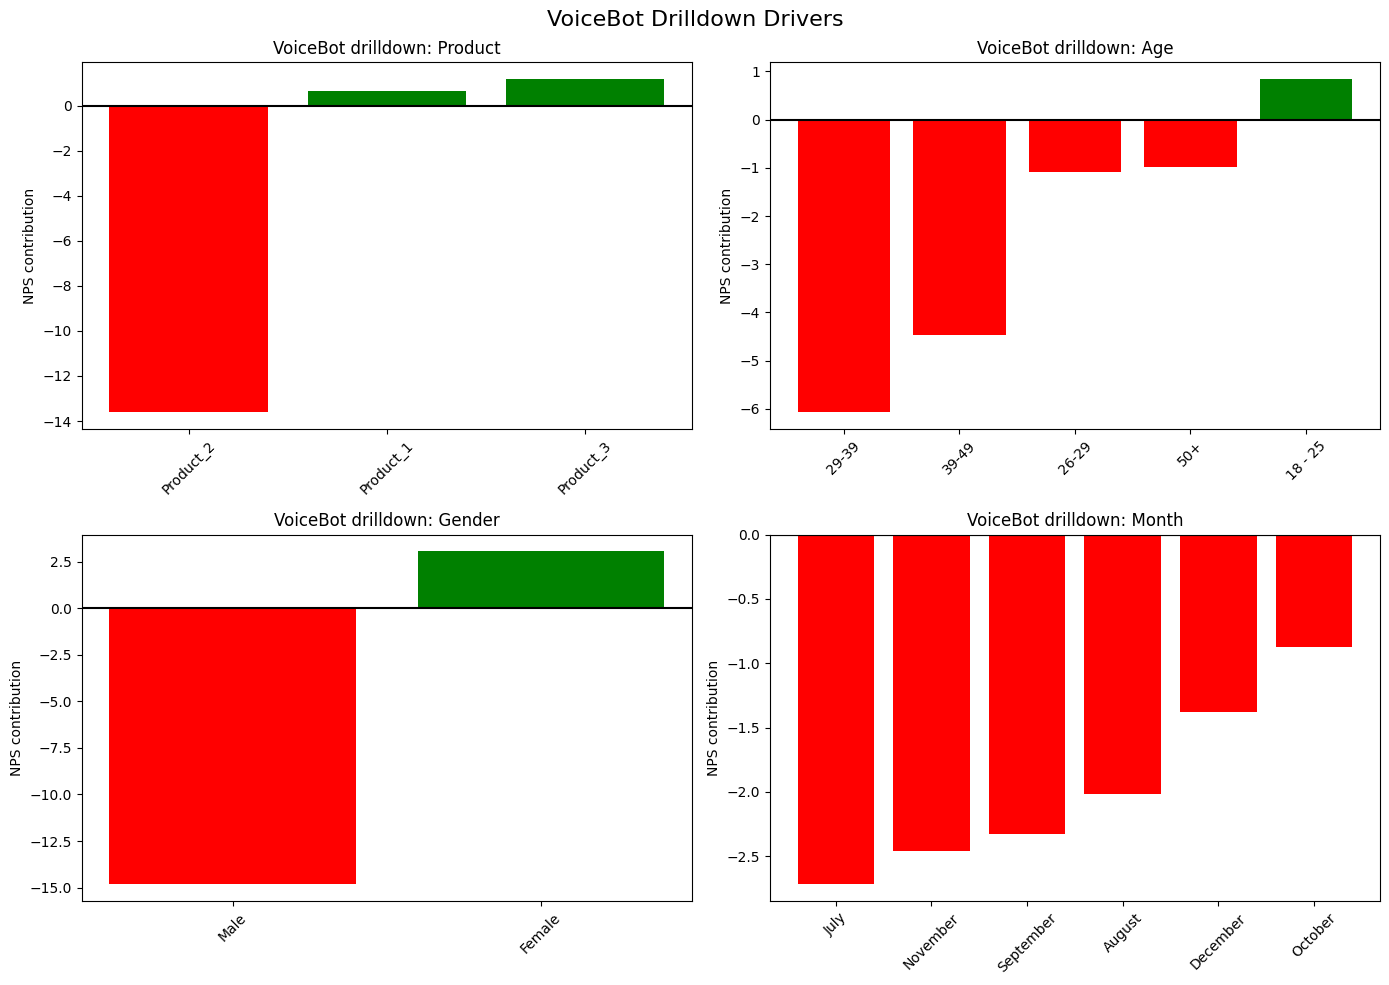

In [78]:
# -----------------------------
# Drilldown: VoiceBot
# -----------------------------

df_voicebot = df_filtered[df_filtered["survey_channel"] == "VoiceBot"]

DRILL_DIMENSIONS = {
    "Product": "survey_product_name",
    "Age": "age_group",
    "Gender": "gender_id",
    "Month": "Month",
}

voicebot_tables = {}

# -----------------------------
# 1. Calculate tables
# -----------------------------

for dim_name, col in DRILL_DIMENSIONS.items():

    tbl = compute_driver_table(df_voicebot, col, baseline_nps)

    tbl = tbl.sort_values("nps_contribution")

    voicebot_tables[dim_name] = tbl


# -----------------------------
# 2. Plot charts (2x2 grid)
# -----------------------------

fig, axes = plt.subplots(2, 2, figsize=(14,10))

axes = axes.flatten()

for ax, (dim_name, tbl) in zip(axes, voicebot_tables.items()):

    vals = tbl["nps_contribution"]
    labels = tbl.index.astype(str)

    colors = np.where(vals >= 0, "green", "red")

    ax.bar(labels, vals, color=colors)

    ax.axhline(0, color="black")

    ax.set_title(f"VoiceBot drilldown: {dim_name}")

    ax.set_ylabel("NPS contribution")

    ax.tick_params(axis='x', rotation=45)


plt.suptitle("VoiceBot Drilldown Drivers", fontsize=16)

plt.tight_layout()

plt.show()

In [79]:
# -----------------------------
# 3. Show tables
# -----------------------------

for dim_name, tbl in voicebot_tables.items():

    print(f"\n===== VoiceBot drilldown table: {dim_name} =====")

    display(tbl)


===== VoiceBot drilldown table: Product =====


,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
survey_product_name,,,,,,,
Product_2,51074,22190,21490,1.370560,-15.078618,0.902431,-13.607416
Product_1,2633,1516,710,30.611470,14.162292,0.046523,0.658868
Product_3,2889,1812,671,39.494635,23.045457,0.051046,1.176379



===== VoiceBot drilldown table: Age =====


,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
age_group,,,,,,,
29-39,19166,7975,8259,-1.481791,-17.930969,0.338646,-6.072248
39-49,17592,7844,7481,2.063438,-14.385740,0.310835,-4.471587
26-29,5267,2263,2014,4.727549,-11.721629,0.093063,-1.090851
50+,9840,4885,3822,10.802846,-5.646332,0.173864,-0.981693
18 - 25,4731,2551,1295,26.548298,10.099121,0.083592,0.844211



===== VoiceBot drilldown table: Gender =====


,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
gender_id,,,,,,,
Male,30270,11185,14600,-11.281797,-27.730975,0.534843,-14.831730
Female,26326,14333,8271,23.026666,6.577488,0.465157,3.059561



===== VoiceBot drilldown table: Month =====


,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
Month,,,,,,,
July,6674,2654,3092,-6.562781,-23.011959,0.117924,-2.713651
November,11010,4862,4445,3.787466,-12.661712,0.194537,-2.463168
September,11267,5058,4523,4.748380,-11.700798,0.199078,-2.329368
August,6385,2720,2811,-1.425215,-17.874393,0.112817,-2.016538
December,10603,5026,4061,9.101198,-7.347980,0.187345,-1.376610
October,10657,5198,3939,11.813831,-4.635347,0.188300,-0.872834


# **VoiceBot декомпозиция выводы**

Декомпозиция VoiceBot показывает, что основной вклад в негативный NPS создаёт Product_2. Его вклад существенно ниже остальных продуктов и формирует большую часть негативного эффекта.

При этом на уровне всего датасета фактор пола не являлся драйвером метрики — вклад мужчин и женщин в общий NPS был симметричным. Однако при углублении анализа внутри сегмента VoiceBot + Product_2 появляется выраженная асимметрия: именно мужчины формируют значительно более сильный негативный вклад. Таким образом, пол выступает не как глобальный драйвер метрики, а как локальный драйвер внутри проблемного сегмента продукта и канала.

На этапе декомпозиции VoiceBot были проанализированы несколько измерений (включая продукт, пол, возраст и время). Наибольшие негативные вклады наблюдались по двум измерениям — продукту и полу. Однако пол относится к структурным характеристикам пользователей (structural driver), на которые невозможно напрямую повлиять продуктовым изменением. Напротив, продукт является управляемым фактором (actionable driver), так как его функциональность, сценарии взаимодействия и пользовательский опыт могут быть изменены. Поэтому дальнейший drill-down анализа был направлен именно в разрез продуктов.

С точки зрения пользовательских сегментов наибольший негативный вклад дают мужчины, а также возрастные группы 29–39 и 39–49, которые являются основной аудиторией продукта.

Негативный эффект наблюдается во многих месяцах, что указывает на системную проблему VoiceBot, а не на единичный инцидент.

Таким образом, основной кандидат на root cause — взаимодействие VoiceBot и Product_2, особенно среди пользователей мужского пола в возрасте 29–49.

# **VoiceBot decomposition conclusions**

The VoiceBot decomposition shows that the main negative impact on NPS is driven by Product_2, which contributes the majority of the negative effect compared to other products.

At the overall dataset level, gender was not a driver of the metric, as the contributions of male and female users to the overall NPS were roughly symmetric. However, when drilling down into the VoiceBot + Product_2 segment, a clear asymmetry emerges: male users generate a significantly larger negative contribution. This means that gender does not act as a global driver of NPS but becomes a local driver within the problematic product-channel combination.

During the VoiceBot decomposition several dimensions were analyzed, including product, gender, age, and time. The strongest negative signals appeared in two dimensions: product and gender. However, gender represents a structural characteristic of the customer base (a structural driver), meaning it cannot be directly changed through product improvements. In contrast, the product itself is an actionable driver, since its functionality, interaction scenarios, and user experience can be modified. For this reason, the subsequent drill-down of the analysis focused on the product dimension.

From a user segmentation perspective, the strongest negative contribution comes from male users, particularly in the 29–39 and 39–49 age groups, which represent the core customer segment.

The negative contribution is observed across multiple months, suggesting a systemic issue with VoiceBot rather than a temporary incident.

Therefore, the primary root cause candidate is the interaction between VoiceBot and Product_2, especially for male users aged 29–49.

In [80]:
# -----------------------------------------
# df_voicebot = df_filtered[df_filtered["survey_channel"] == "VoiceBot"]
# -----------------------------------------

df_voicebot = df_filtered[df_filtered["survey_channel"] == "VoiceBot"].copy()

# 1) VoiceBot -> Product (чтобы формально зафиксировать, что Product_2 главный внутри VoiceBot)
vb_product = compute_driver_table(df_voicebot, "survey_product_name", baseline_nps).sort_values("nps_contribution")
print("===== VoiceBot drilldown: Product =====")
display(vb_product)

# Берём главный негативный продукт внутри VoiceBot
top_product = vb_product["nps_contribution"].idxmin()
print(f"Top negative product inside VoiceBot: {top_product}")

df_vb_p = df_voicebot[df_voicebot["survey_product_name"] == top_product].copy()

# -----------------------------------------
# 2) Внутри VoiceBot + Product_2: считаем Gender / Age / Month
# -----------------------------------------
DRILL_2 = {
    "Gender": "gender_id",
    "Age": "age_group",
    "Month": "Month",
}

#DRILL_2 = {
#    "Age": "age_group",
#    "Month": "Month",
#    "Gender": "gender_id",
#}

vb_p_tables = {}
for dim_name, col in DRILL_2.items():
    tbl = compute_driver_table(df_vb_p, col, baseline_nps).sort_values("nps_contribution")
    vb_p_tables[dim_name] = tbl

===== VoiceBot drilldown: Product =====


,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
survey_product_name,,,,,,,
Product_2,51074,22190,21490,1.370560,-15.078618,0.902431,-13.607416
Product_1,2633,1516,710,30.611470,14.162292,0.046523,0.658868
Product_3,2889,1812,671,39.494635,23.045457,0.051046,1.176379


Top negative product inside VoiceBot: Product_2


In [81]:
# --- ТАБЛИЦЫ: одна за другой ---
for dim_name, tbl in vb_p_tables.items():
    print(f"\n===== VoiceBot + {top_product} drilldown table: {dim_name} =====")
    display(tbl)

# -----------------------------------------
# 3) (Очень полезно) Двухмерные срезы, чтобы найти реальный root-cause сегмент
#    VoiceBot + Product_2 -> (Gender x Age) и (Gender x Month)
# -----------------------------------------
def compute_driver_table_2d(df: pd.DataFrame, col_a: str, col_b: str, baseline_nps: float) -> pd.DataFrame:
    t = (
        df.groupby([col_a, col_b])
          .agg(
              total_answers=("total_answers", "sum"),
              promoters=("promoters", "sum"),
              detractors=("detractors", "sum"),
          )
    )
    t["NPS"] = (t["promoters"] - t["detractors"]) / t["total_answers"] * 100.0
    t["diff_vs_baseline"] = t["NPS"] - float(baseline_nps)
    total_all = t["total_answers"].sum()
    t["weight"] = t["total_answers"] / total_all  # веса ЛОКАЛЬНЫЕ внутри среза VoiceBot+Product_2
    t["nps_contribution"] = t["weight"] * t["diff_vs_baseline"]
    return t.sort_values("nps_contribution")

vb_p_gender_age = compute_driver_table_2d(df_vb_p, "gender_id", "age_group", baseline_nps)
vb_p_gender_month = compute_driver_table_2d(df_vb_p, "gender_id", "Month", baseline_nps)

#print(f"\n===== VoiceBot + {top_product}: Gender x Age (sorted by contribution) =====")
#display(vb_p_gender_age)

#print(f"\n===== VoiceBot + {top_product}: Gender x Month (sorted by contribution) =====")
#display(vb_p_gender_month)


===== VoiceBot + Product_2 drilldown table: Gender =====


,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
gender_id,,,,,,,
Male,27592,9754,13811,-14.703537,-31.152715,0.540236,-16.829810
Female,23482,12436,7679,20.258070,3.808892,0.459764,1.751192



===== VoiceBot + Product_2 drilldown table: Age =====


,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
age_group,,,,,,,
29-39,17384,6943,7782,-4.826277,-21.275455,0.340369,-7.241503
39-49,16025,6912,7061,-0.929797,-17.378975,0.313760,-5.452835
26-29,4724,1934,1891,0.910246,-15.538932,0.092493,-1.437246
50+,8930,4338,3572,8.577828,-7.871350,0.174844,-1.376261
18 - 25,4011,2063,1184,21.914734,5.465557,0.078533,0.429227



===== VoiceBot + Product_2 drilldown table: Month =====


,total_answers,promoters,detractors,NPS,diff_vs_baseline,weight,nps_contribution
Month,,,,,,,
November,9121,3755,3939,-2.017323,-18.466501,0.178584,-3.297822
July,6674,2654,3092,-6.562781,-23.011959,0.130673,-3.007045
September,10769,4760,4392,3.417216,-13.031962,0.210851,-2.747801
August,6385,2720,2811,-1.425215,-17.874393,0.125015,-2.234562
December,9197,4204,3695,5.534413,-10.914765,0.180072,-1.965444
October,8928,4097,3561,6.003584,-10.445594,0.174805,-1.825944


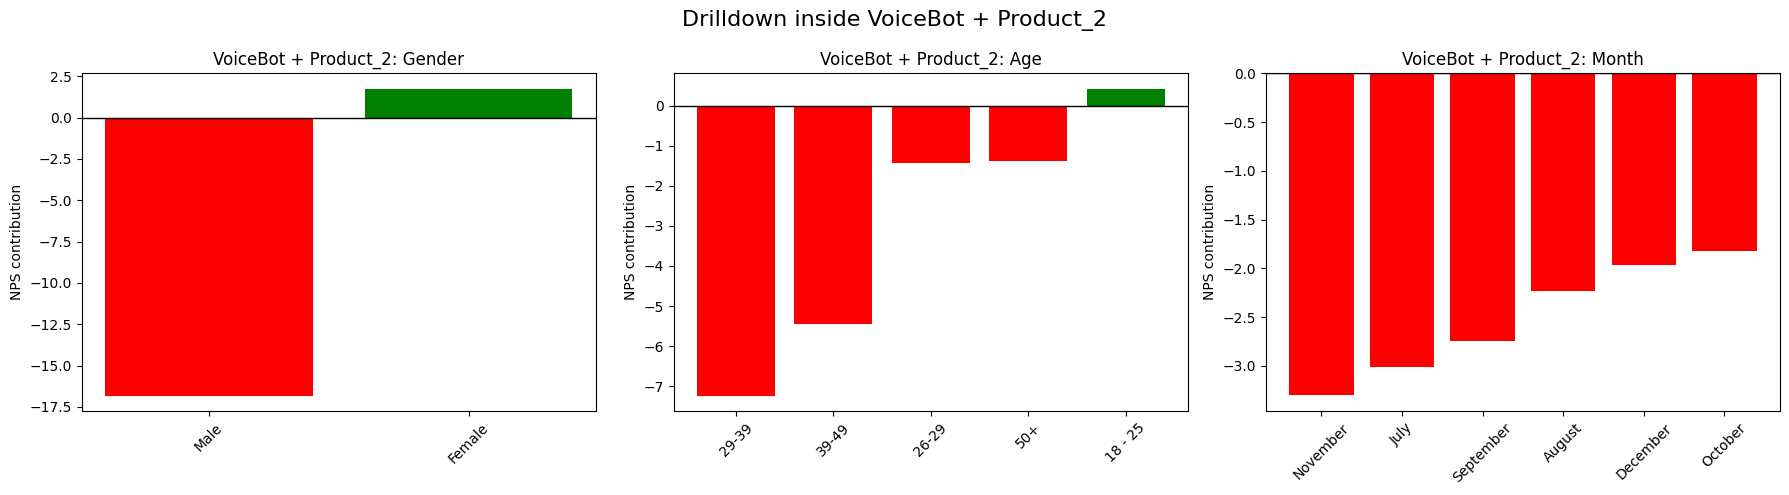

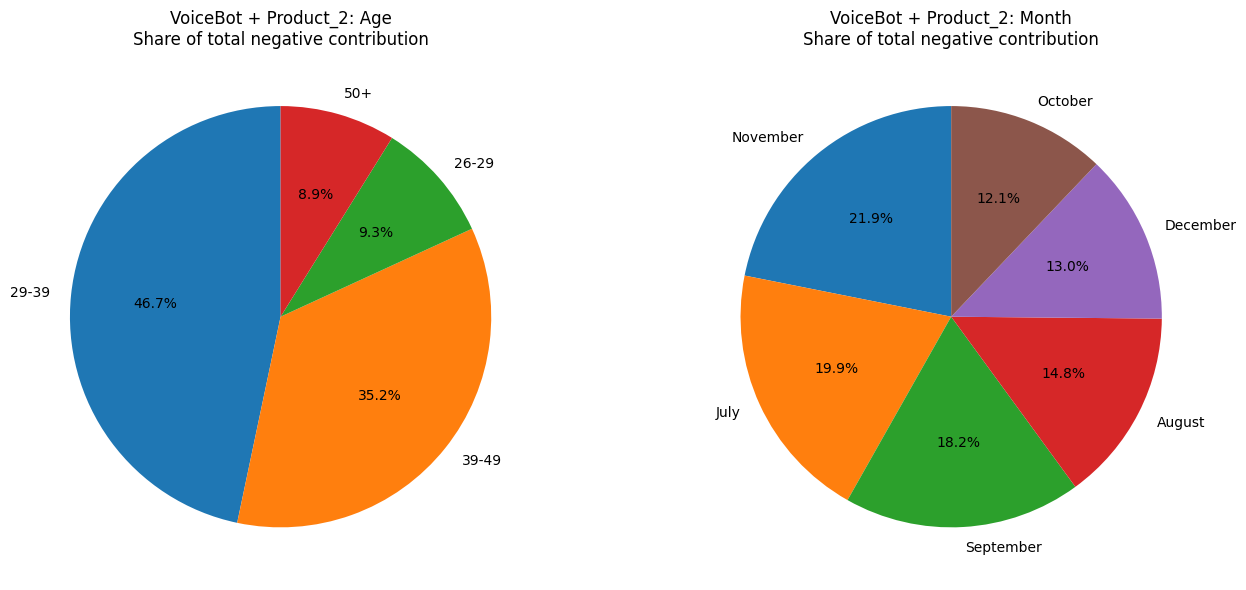

In [82]:
# --- PLOTS: 1 ряд из 3 графиков ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (dim_name, tbl) in zip(axes, vb_p_tables.items()):
    labels = tbl.index.astype(str)
    vals = tbl["nps_contribution"].values
    colors = np.where(vals >= 0, "green", "red")

    ax.bar(labels, vals, color=colors)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"VoiceBot + {top_product}: {dim_name}")
    ax.set_ylabel("NPS contribution")
    ax.tick_params(axis="x", rotation=45)

plt.suptitle(f"Drilldown inside VoiceBot + {top_product}", fontsize=16)
plt.tight_layout()
plt.show()

# --- PIE CHARTS: sorted descending ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, dim_name in zip(axes, ["Age", "Month"]):
    tbl = vb_p_tables[dim_name].copy()

    neg_tbl = tbl[tbl["nps_contribution"] < 0].copy()
    neg_tbl["negative_share"] = (
        neg_tbl["nps_contribution"].abs() / neg_tbl["nps_contribution"].abs().sum()
    )

    neg_tbl = neg_tbl.sort_values("negative_share", ascending=False)

    labels = neg_tbl.index.astype(str)
    values = neg_tbl["negative_share"].values

    ax.pie(
        values,
        labels=labels,
        autopct="%1.1f%%",
        startangle=90
    )
    ax.set_title(f"VoiceBot + {top_product}: {dim_name}\nShare of total negative contribution")

plt.tight_layout()
plt.show()

# **ПРОМЕЖУТОЧНЫЕ ВЫВОДЫ ПО ДЕКОМПОЗИЦИИ VOICEBOT + PRODUCT 2**

Основной источник падения NPS находится внутри связки VoiceBot + Product_2. Этот продукт формирует вклад −13.61 пункта в общий NPS VoiceBot. При этом его доля ответов составляет около 90.2% всех обращений (51074 из общего объёма), поэтому даже небольшое ухудшение пользовательского опыта внутри этого продукта оказывает сильное влияние на итоговый показатель.

Анализ по полу показывает, что ключевой негативный вклад формируется среди мужской аудитории. Мужчины дают вклад −16.83 пункта в NPS VoiceBot + Product_2, тогда как женщины, наоборот, дают положительный вклад +1.75. При этом мужчины составляют около 54% всех ответов. Это означает, что основная часть проблемы концентрируется именно в мужском сегменте пользователей.

Декомпозиция по возрасту показывает, что главный драйвер негативного NPS — группа 29–39 лет. Она формирует вклад −7.24 пункта, что составляет около 46.7% всего негативного вклада по возрастным сегментам. Второй по величине вклад даёт группа 39–49 лет: −5.45 пункта (около 35.2% негативного вклада). Вместе эти две группы формируют примерно 82% всего негативного влияния по возрасту. Молодая аудитория 18–25, наоборот, имеет положительный вклад +0.43, что говорит о том, что проблема сконцентрирована именно среди более взрослой аудитории.

Анализ по месяцам показывает, что негативный вклад распределён относительно равномерно по нескольким периодам, однако максимальный вклад приходится на ноябрь (−3.30 пункта, около 21.9% общего негативного вклада). Далее следуют июль (−3.01; около 19.9%), сентябрь (−2.75; около 18.2%) и август (−2.23; около 14.8%). Эти четыре месяца вместе дают около 75% всего негативного вклада. Это указывает на вероятную устойчивую проблему пользовательского опыта, а не на единичный инцидент.

Таким образом, root cause падения NPS VoiceBot локализуется внутри Product_2 и концентрируется в сегменте пользователей мужского пола в возрасте 29–49 лет. Эти сегменты формируют основную часть негативного пользовательского опыта и должны стать приоритетом для дальнейшего анализа пользовательского пути и выявления конкретных точек неудовлетворённости.

# **VOICEBOT + PRODUCT 2 DECOMPOSITION: INTERMEDIATE CONCLUSIONS**

The main source of the NPS decline is located inside the VoiceBot + Product_2 interaction. Product_2 contributes −13.61 points to the overall VoiceBot NPS. At the same time, it represents about 90.2% of all responses (51,074 answers), which means that any deterioration in user experience within this product has a significant impact on the overall NPS.

Gender analysis shows that the primary negative contribution comes from the male audience. Male users contribute −16.83 points to the VoiceBot + Product_2 NPS, while female users contribute positively with +1.75. Since male users represent about 54% of all responses, the majority of the negative impact is concentrated within this segment.

The age breakdown indicates that the largest negative driver is the 29–39 age group. This group contributes −7.24 NPS points, which corresponds to approximately 46.7% of the total negative contribution among age segments. The second largest contributor is the 39–49 group with −5.45 points (around 35.2%). Together, these two segments account for roughly 82% of the total negative impact by age. In contrast, the youngest group (18–25) contributes positively with +0.43, suggesting that dissatisfaction is concentrated among older users.

The monthly breakdown shows that the negative contribution is distributed across several months, but the largest impact occurs in November (−3.30 points, about 21.9% of the total negative contribution). It is followed by July (−3.01; about 19.9%), September (−2.75; about 18.2%), and August (−2.23; about 14.8%). These four months together account for approximately 75% of the total negative contribution, suggesting a persistent user experience issue rather than a one-time incident.

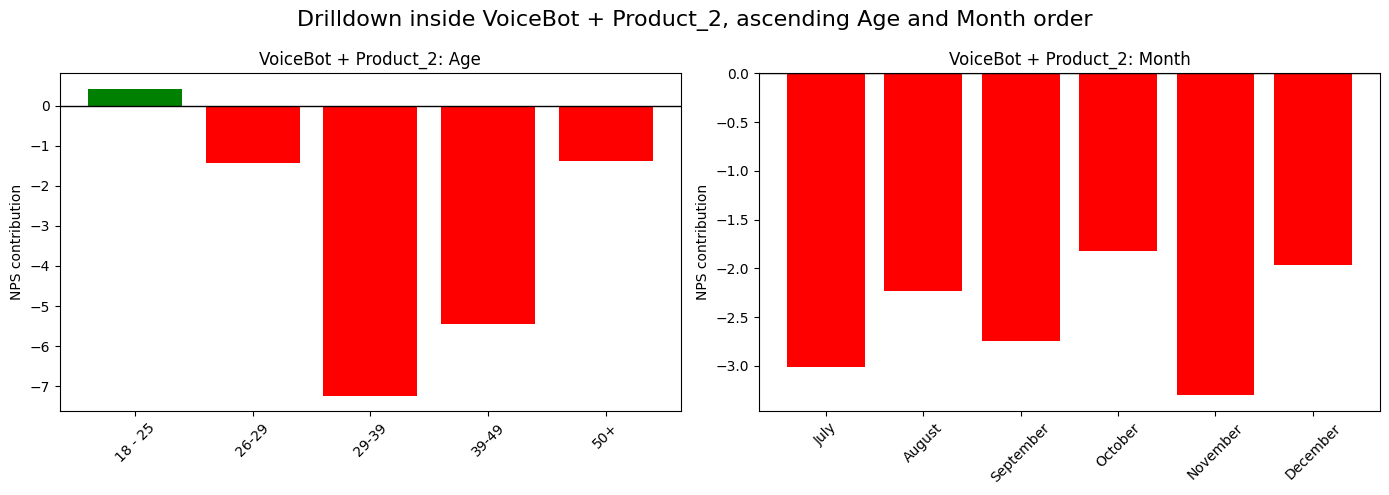

In [83]:
# --- ORDERED BAR CHARTS: Age and Month ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, dim_name in zip(axes, ["Age", "Month"]):

    tbl = vb_p_tables[dim_name].copy()

    # порядок возрастных групп
    if dim_name == "Age":
        age_order = ["18 - 25", "26-29", "29-39", "39-49", "50+"]
        tbl = tbl.reindex(age_order)

    # порядок месяцев
    if dim_name == "Month":
        month_order = [
            "January","February","March","April","May","June",
            "July","August","September","October","November","December"
        ]
        tbl = tbl.reindex(month_order).dropna()

    labels = tbl.index.astype(str)
    vals = tbl["nps_contribution"].values

    colors = np.where(vals >= 0, "green", "red")

    ax.bar(labels, vals, color=colors)

    ax.axhline(0, color="black", linewidth=1)

    ax.set_title(f"VoiceBot + {top_product}: {dim_name}")
    ax.set_ylabel("NPS contribution")

    ax.tick_params(axis="x", rotation=45)

plt.suptitle(f"Drilldown inside VoiceBot + {top_product}, ascending Age and Month order", fontsize=16)

plt.tight_layout()
plt.show()

# **Возрастная структура и временная динамика**

Анализ сегментов внутри VoiceBot + Product_2 показывает выраженную возрастную структуру негативных NPS-вкладов. Молодая аудитория (18–25) демонстрирует положительный вклад в метрику, что может указывать на более высокую адаптацию этой группы к автоматизированным каналам обслуживания. С ростом возраста вклад становится всё более отрицательным, достигая максимума в группе 29–39 лет, после чего негатив постепенно снижается в старших возрастных группах. Это указывает на то, что пользователи среднего возраста формируют основную часть негативного NPS-влияния для Product_2.

# Возможные причины возрастного эффекта

• Более высокая цифровая адаптация молодых пользователей (18–25), привыкших к чат-ботам и автоматизированным сервисам\
• Более сложные типы запросов у клиентов среднего возраста (кредиты, финансовые операции, сложные сервисные сценарии)\
• Более высокие ожидания качества обслуживания у аудитории 29–49 лет\
• Более высокий уровень занятости и временного давления у пользователей среднего возраста, что снижает терпимость к задержкам и ошибкам VoiceBot\
• Потенциальное несоответствие сценариев VoiceBot типичным задачам клиентов среднего возраста

В разрезе месяцев наблюдаются колебания NPS-вкладов, которые выглядят менее структурными и, вероятно, связаны с операционными изменениями в работе канала VoiceBot.

# Возможные причины временной динамики

• Изменения в моделях или сценариях VoiceBot (обновления NLP, диалоговых веток)\
• Изменения нагрузки на канал поддержки (маркетинговые кампании, сезонные пики обращений)\
• Изменения в типах пользовательских запросов в разные периоды\
• Изменения в логике маршрутизации обращений между каналами поддержки\
• Потенциальные технические или продуктовые изменения, влияющие на пользовательский опыт

В целом возрастной фактор выглядит более стабильным и системным драйвером негативного NPS, тогда как месячные колебания скорее отражают операционные изменения в работе сервиса.

# **Age structure and temporal dynamics**

The segment analysis within VoiceBot + Product_2 reveals a clear age-related structure in negative NPS contributions. The youngest group (18–25) generates a positive contribution, suggesting that younger users are more comfortable interacting with automated service channels. As age increases, the contribution becomes increasingly negative, reaching its strongest decline in the 29–39 age group, after which the negative impact gradually decreases for older groups. This indicates that middle-aged customers generate the largest share of negative NPS pressure for Product_2.

# Possible explanations for the age pattern

• Higher digital literacy among younger users (18–25), who are more accustomed to interacting with automated systems and chatbots\
• More complex service requests among middle-aged customers (e.g., loans, financial operations, advanced service scenarios)\
• Higher expectations regarding service quality among customers aged 29–49\
• Higher time pressure for working-age customers, reducing tolerance for delays or misunderstandings in VoiceBot interactions\
• Potential mismatch between VoiceBot scenarios and the typical needs of middle-aged customers

The monthly breakdown shows visible fluctuations in NPS contributions. These variations appear less structural and are more likely driven by operational changes in the VoiceBot channel.

# Possible explanations for the temporal dynamics

• Updates to VoiceBot models or dialogue scenarios (e.g., NLP model updates or routing logic changes)\
• Changes in support channel load due to marketing campaigns or seasonal demand patterns\
• Variation in the types of customer requests during different months\
• Changes in the routing logic between support channels\
• Potential technical or product updates affecting user experience

Overall, the age effect appears to be a more stable structural driver of negative NPS, while the monthly variation likely reflects temporary operational factors affecting the VoiceBot channel.

In [84]:
# Топ-10 комбинаций, кандидаты на root cause
print("\nTop-10 most negative combos (Gender x Age):")
display(vb_p_gender_age.head(10)[["total_answers","NPS","diff_vs_baseline","weight","nps_contribution"]])

print("\nTop-10 most negative combos (Gender x Month):")
display(vb_p_gender_month.head(10)[["total_answers","NPS","diff_vs_baseline","weight","nps_contribution"]])


Top-10 most negative combos (Gender x Age):


total_answers        NPS  diff_vs_baseline    weight  \
gender_id age_group                                                         
Male      29-39               9738 -20.671596        -37.120774  0.190665   
          39-49               9004 -17.425589        -33.874767  0.176293   
          50+                 4630  -3.196544        -19.645722  0.090653   
          26-29               2491 -14.652750        -31.101928  0.048772   
          18 - 25             1729   2.197802        -14.251376  0.033853   
Female    29-39               7646  15.354434         -1.094744  0.149704   
          26-29               2233  18.271384          1.822206  0.043721   
          50+                 4300  21.255814          4.806636  0.084192   
          39-49               7021  20.225039          3.775861  0.137467   
          18 - 25             2282  36.853637         20.404459  0.044680   

                     nps_contribution  
gender_id age_group                    
Male      29-39             -7.077615  
          39-49             -5.971892  
          50+               -1.780939  
          26-29             -1.516915  
          18 - 25           -0.482450  
Female    29-39             -0.163888  
          26-29              0.079668  
          50+                0.404678  
          39-49              0.519057  
          18 - 25            0.911677


Top-10 most negative combos (Gender x Month):


total_answers        NPS  diff_vs_baseline    weight  \
gender_id Month                                                             
Male      November            4906 -17.774154        -34.223332  0.096057   
          September           5670 -12.927690        -29.376868  0.111015   
          July                3768 -21.151805        -37.600983  0.073775   
          December            5064 -10.781991        -27.231168  0.099150   
          October             4715 -10.710498        -27.159676  0.092317   
          August              3469 -17.411358        -33.860536  0.067921   
Female    July                2906  12.353751         -4.095427  0.056898   
          November            4215  16.322657         -0.126521  0.082527   
          August              2916  17.592593          1.143415  0.057094   
          September           5099  21.592469          5.143291  0.099836   

                     nps_contribution  
gender_id Month                        
Male      November          -3.287380  
          September         -3.261284  
          July              -2.774024  
          December          -2.699977  
          October           -2.507301  
          August            -2.299843  
Female    July              -0.233021  
          November          -0.010441  
          August             0.065282  
          September          0.513483

In [85]:
# Age × Month inside VoiceBot + Product_2

vb_p_age_month = compute_driver_table(
    df_voicebot[df_voicebot["survey_product_name"] == "Product_2"],
    ["age_group", "Month"],
    baseline_nps
)

vb_p_age_month = vb_p_age_month.sort_values("nps_contribution")

print("\nTop-10 most negative combos (Age × Month):")
display(vb_p_age_month.head(10)[
    ["total_answers", "NPS", "diff_vs_baseline", "weight", "nps_contribution"]
])


Top-10 most negative combos (Age × Month):


total_answers        NPS  diff_vs_baseline    weight  \
age_group Month                                                             
29-39     November            3142  -6.938256        -23.387434  0.061519   
          September           3642  -2.855574        -19.304752  0.071308   
39-49     July                2166 -12.650046        -29.099224  0.042409   
29-39     July                2270 -11.145374        -27.594552  0.044445   
39-49     November            2755  -6.279492        -22.728670  0.053941   
29-39     December            3221  -0.962434        -17.411612  0.063065   
          October             3022  -2.051621        -18.500799  0.059169   
          August              2087  -8.193579        -24.642757  0.040862   
39-49     September           3457   2.458779        -13.990399  0.067686   
          August              2125  -3.388235        -19.837413  0.041606   

                     nps_contribution  
age_group Month                        
29-39     November          -1.438762  
          September         -1.376589  
39-49     July              -1.234071  
29-39     July              -1.226449  
39-49     November          -1.226015  
29-39     December          -1.098070  
          October           -1.094675  
          August            -1.006959  
39-49     September         -0.946956  
          August            -0.825361

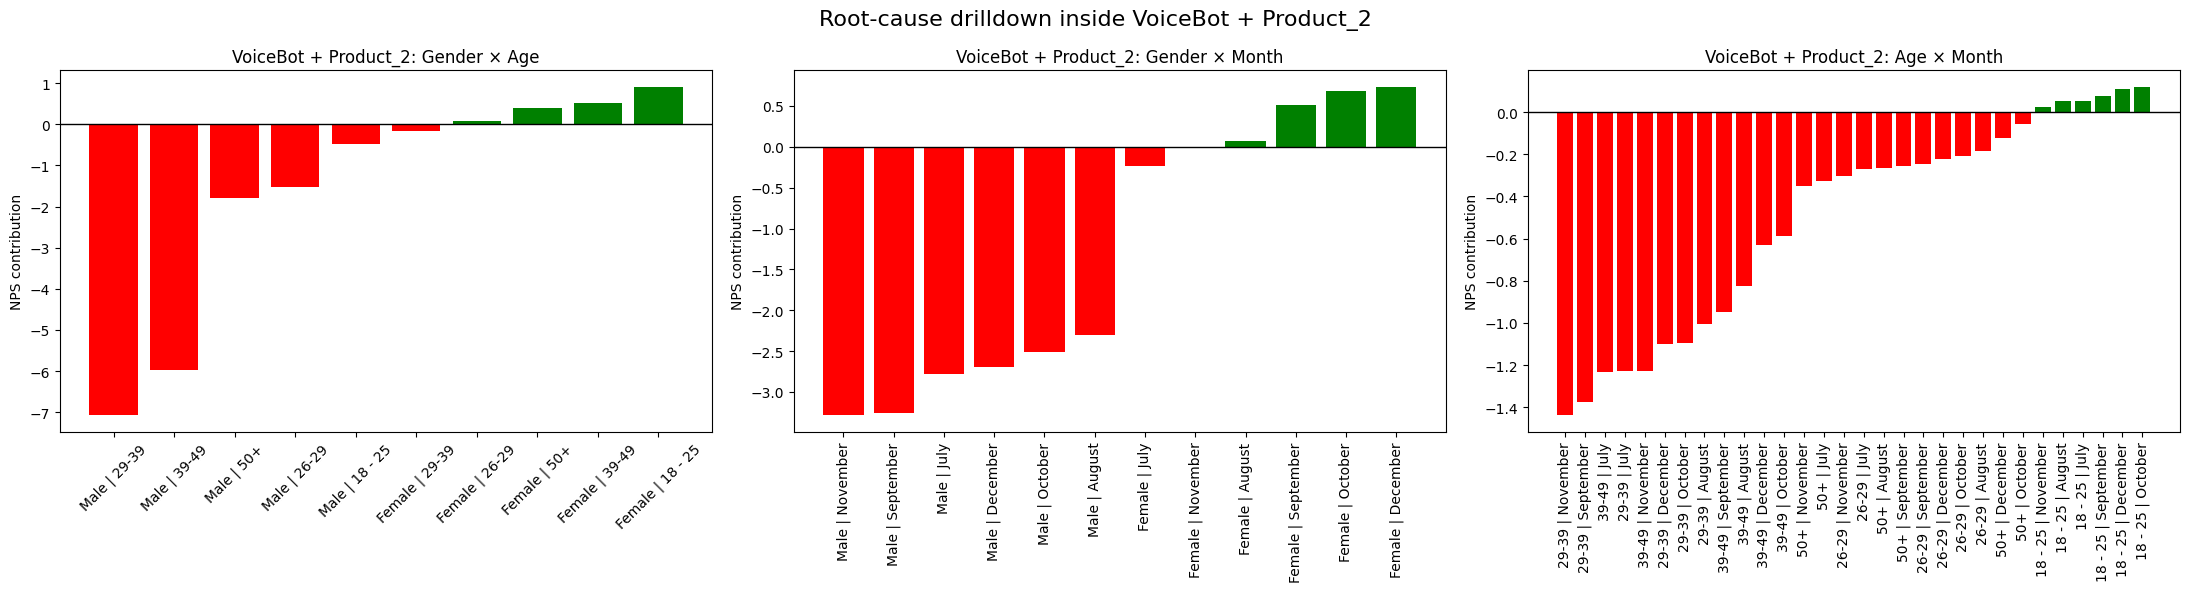

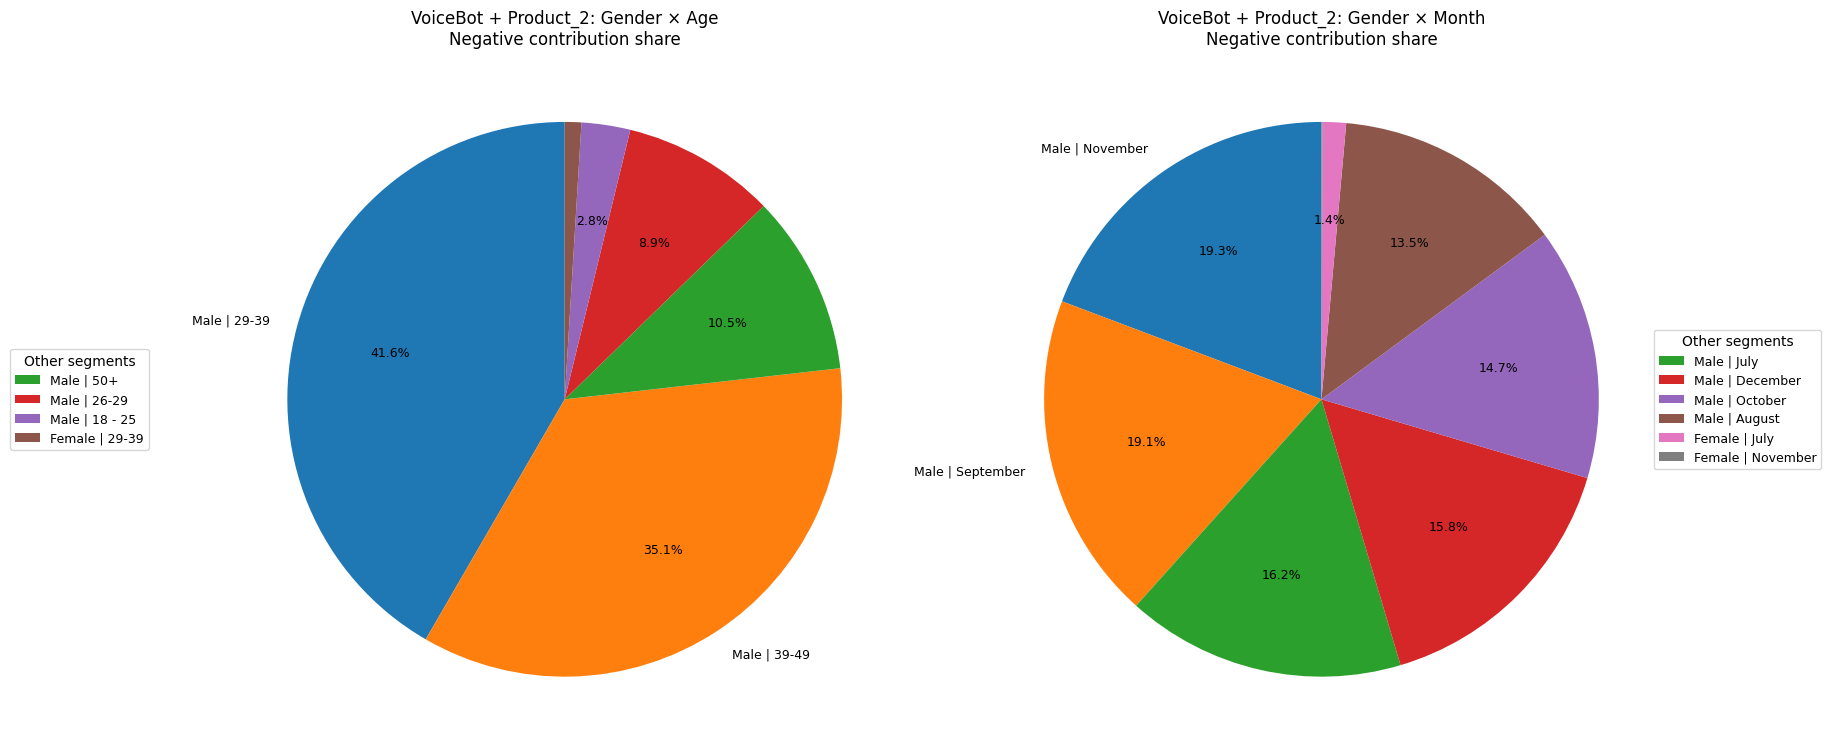

In [86]:
# --- PLOTS: 1 row of 3 bar charts for 2D root-cause tables ---

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

tables_2d = {
    "Gender × Age": vb_p_gender_age,
    "Gender × Month": vb_p_gender_month,
    "Age × Month": vb_p_age_month
}

for ax, (title, tbl) in zip(axes, tables_2d.items()):
    tbl_plot = tbl.copy()

    # если индекс MultiIndex, склеиваем его в удобные подписи
    if isinstance(tbl_plot.index, pd.MultiIndex):
        #labels = [f"{a}\n{b}" for a, b in tbl_plot.index]
        labels = [f"{idx[0]} | {idx[1]}" for idx in tbl_plot.index]
    else:
        labels = tbl_plot.index.astype(str)

    #if isinstance(tbl_plot.index, pd.MultiIndex):
      #labels = [f"{a}\n{b}" for a, b in tbl_plot.index]

    vals = tbl_plot["nps_contribution"].values
    colors = np.where(vals >= 0, "green", "red")

    ax.bar(labels, vals, color=colors)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_title(f"VoiceBot + {top_product}: {title}")
    ax.set_ylabel("NPS contribution")
    ax.tick_params(axis="x", rotation=45)
    if title == 'Age × Month' or title == 'Gender × Month':
      ax.tick_params(axis="x", rotation=90)

    #ax.tick_params(axis="x", labelsize=8)

plt.suptitle(f"Root-cause drilldown inside VoiceBot + {top_product}", fontsize=16)
plt.tight_layout()
plt.show()

# --- FINAL PIE CHARTS (top-2 labeled, others in legend) ---

import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

tables_for_pie = {
    "Gender × Age": vb_p_gender_age,
    "Gender × Month": vb_p_gender_month
}

for ax_i, (ax, (title, tbl)) in enumerate(zip(axes, tables_for_pie.items())):

    # берем только отрицательные вклады
    tbl_neg = tbl[tbl["nps_contribution"] < 0].copy()

    # считаем долю в общем негативе
    tbl_neg["negative_share"] = (
        tbl_neg["nps_contribution"].abs()
        / tbl_neg["nps_contribution"].abs().sum()
    )

    # сортировка по убыванию
    tbl_neg = tbl_neg.sort_values("negative_share", ascending=False)

    values = tbl_neg["negative_share"].values

    # подписи сегментов
    if isinstance(tbl_neg.index, tuple) or hasattr(tbl_neg.index, "levels"):
        labels_full = [f"{a} | {b}" for a, b in tbl_neg.index]
    else:
        labels_full = tbl_neg.index.astype(str).tolist()

    # два самых больших сегмента
    pie_labels = []
    legend_labels = []
    legend_idx = []

    for i, lab in enumerate(labels_full):
        if i < 2:
            pie_labels.append(lab)
        else:
            pie_labels.append("")
            legend_labels.append(lab)
            legend_idx.append(i)

    # индекс самого маленького сегмента
    min_idx = int(np.argmin(values))

    # функция для процентов
    def autopct_func(pct):
        autopct_func.counter += 1
        i = autopct_func.counter - 1
        if i == min_idx:
            return ""
        return f"{pct:.1f}%"

    autopct_func.counter = 0

    wedges, texts, autotexts = ax.pie(
        values,
        labels=pie_labels,
        autopct=autopct_func,
        startangle=90,
        labeldistance=1.1,
        pctdistance=0.65,
        textprops={"fontsize":9}
    )

    # выбираем wedges для легенды
    legend_wedges = [wedges[i] for i in legend_idx]

    # положение легенды
    if ax_i == 0:
        legend_anchor = (-0.20, 0.5)
    else:
        legend_anchor = (1.10, 0.5)

    ax.legend(
        legend_wedges,
        legend_labels,
        title="Other segments",
        loc="center",
        bbox_to_anchor=legend_anchor,
        fontsize=9
    )

    ax.set_title(
        f"VoiceBot + {top_product}: {title}\nNegative contribution share",
        fontsize=12
    )

plt.tight_layout()
plt.show()

In [98]:
df = df_filtered.copy()

# =========================================================
# MASKS
# =========================================================
mask_male_2939 = (
    (df["survey_channel"] == "VoiceBot") &
    (df["survey_product_name"] == "Product_2") &
    (df["gender_id"] == "Male") &
    (df["age_group"] == "29-39")
)

mask_male_3949 = (
    (df["survey_channel"] == "VoiceBot") &
    (df["survey_product_name"] == "Product_2") &
    (df["gender_id"] == "Male") &
    (df["age_group"] == "39-49")
)

mask_male_2949 = (
    (df["survey_channel"] == "VoiceBot") &
    (df["survey_product_name"] == "Product_2") &
    (df["gender_id"] == "Male") &
    (df["age_group"].isin(["29-39", "39-49"]))
)

mask_vb_p2_rest = (
    (df["survey_channel"] == "VoiceBot") &
    (df["survey_product_name"] == "Product_2") &
    (~mask_male_2939) &
    (~mask_male_3949)
)

mask_vb_other_products = (
    (df["survey_channel"] == "VoiceBot") &
    (df["survey_product_name"] != "Product_2")
)

mask_other_channels = (
    df["survey_channel"] != "VoiceBot"
)

# =========================================================
# TABLE 1: merged Male 29–49
# =========================================================
segments_merged = {
    "Other channels": df.loc[mask_other_channels, "detractors"].sum(),
    "VB + P2 + Rest": df.loc[mask_vb_p2_rest, "detractors"].sum(),
    "VB + P2 + Male 29–49": df.loc[mask_male_2949, "detractors"].sum(),
    "VB + Other products": df.loc[mask_vb_other_products, "detractors"].sum(),
}

table_merged = pd.DataFrame({
    "segment": list(segments_merged.keys()),
    "detractors": list(segments_merged.values())
})

total_detractors = table_merged["detractors"].sum()
table_merged["share_pct"] = table_merged["detractors"] / total_detractors * 100
table_merged = table_merged.sort_values("share_pct", ascending=False).reset_index(drop=True)

print("=== TABLE 1: merged Male 29–49 ===")
print(f"Total detractors in dataset: {total_detractors}")
display(table_merged)

# =========================================================
# TABLE 2: split Male 29–39 and 39–49
# =========================================================
segments_split = {
    "Other channels": df.loc[mask_other_channels, "detractors"].sum(),
    "VB + P2 + Rest": df.loc[mask_vb_p2_rest, "detractors"].sum(),
    "VB + P2 + Male 29–39": df.loc[mask_male_2939, "detractors"].sum(),
    "VB + P2 + Male 39–49": df.loc[mask_male_3949, "detractors"].sum(),
    "VB + Other products": df.loc[mask_vb_other_products, "detractors"].sum(),
}

table_split = pd.DataFrame({
    "segment": list(segments_split.keys()),
    "detractors": list(segments_split.values())
})

table_split["share_pct"] = table_split["detractors"] / total_detractors * 100
table_split = table_split.sort_values("share_pct", ascending=False).reset_index(drop=True)

print("=== TABLE 2: split Male 29–39 and 39–49 ===")
print(f"Total detractors in dataset: {total_detractors}")
display(table_split)

=== TABLE 1: merged Male 29–49 ===
Total detractors in dataset: 36897


,segment,detractors,share_pct
0,Other channels,14026,38.013931
1,VB + P2 + Rest,11625,31.506627
2,VB + P2 + Male 29–49,9865,26.736591
3,VB + Other products,1381,3.742852


=== TABLE 2: split Male 29–39 and 39–49 ===
Total detractors in dataset: 36897


,segment,detractors,share_pct
0,Other channels,14026,38.013931
1,VB + P2 + Rest,11625,31.506627
2,VB + P2 + Male 29–39,5140,13.930672
3,VB + P2 + Male 39–49,4725,12.805919
4,VB + Other products,1381,3.742852


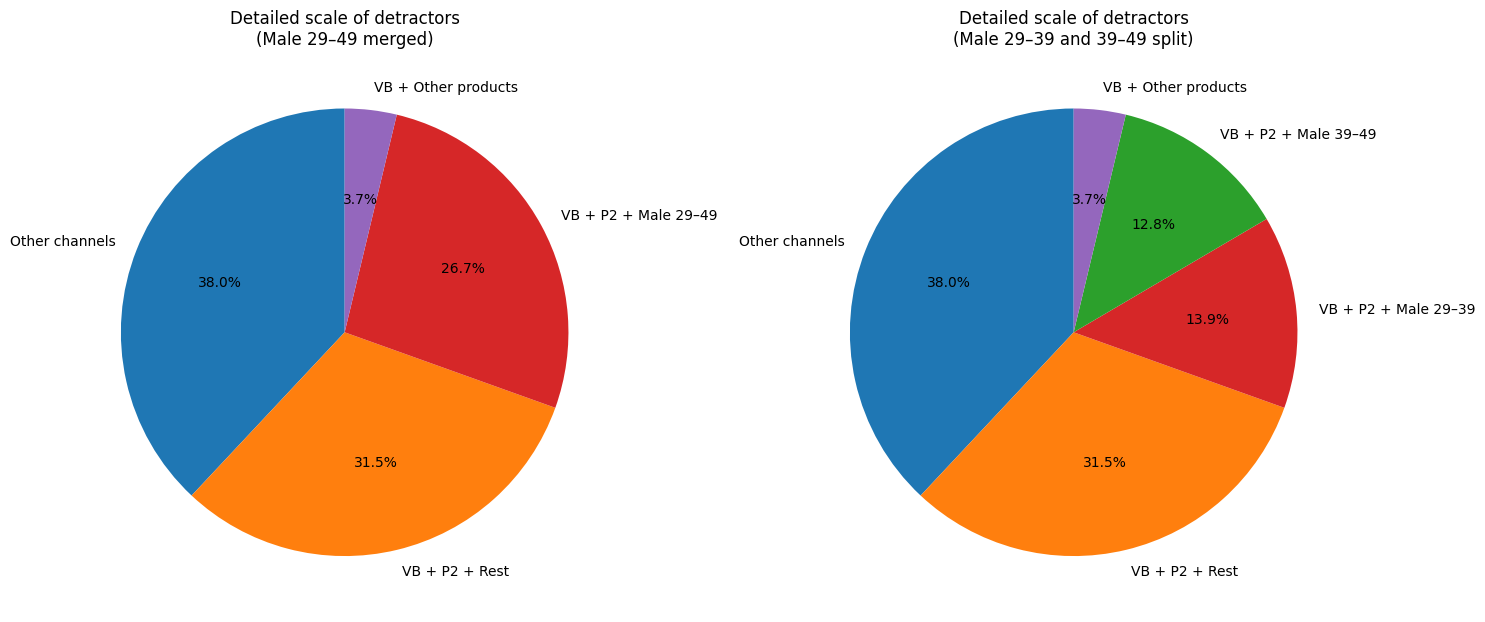

In [100]:
# =========================================================
# FIXED COLORS
# =========================================================
color_map = {
    "Other channels": "tab:blue",
    "VB + P2 + Rest": "tab:orange",
    "VB + P2 + Male 29–49": "tab:red",
    "VB + P2 + Male 29–39": "tab:red",
    "VB + P2 + Male 39–49": "tab:green",
    "VB + Other products": "tab:purple",
}

# Цвета для merged pie
colors_merged = [color_map[s] for s in table_merged["segment"]]

# Цвета для split pie
colors_split = [color_map[s] for s in table_split["segment"]]

# =========================================================
# TWO PIE CHARTS SIDE BY SIDE
# =========================================================
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# ---- Left: merged Male 29–49
axes[0].pie(
    table_merged["detractors"],
    labels=table_merged["segment"],
    colors=colors_merged,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90
)
axes[0].set_title("Detailed scale of detractors\n(Male 29–49 merged)")

# ---- Right: split Male 29–39 / 39–49
axes[1].pie(
    table_split["detractors"],
    labels=table_split["segment"],
    colors=colors_split,
    autopct=lambda p: f"{p:.1f}%",
    startangle=90
)
axes[1].set_title("Detailed scale of detractors\n(Male 29–39 and 39–49 split)")

plt.tight_layout()
plt.show()

In [104]:
import pandas as pd
import matplotlib.pyplot as plt

df = df_filtered.copy()

# =====================================================
# TOTALS
# =====================================================

total_answers = df["total_answers"].sum()
total_promoters = df["promoters"].sum()
total_detractors = df["detractors"].sum()

baseline_nps = 100 * (total_promoters - total_detractors) / total_answers

print("Baseline NPS:", round(baseline_nps,2))

# =====================================================
# MERGED SEGMENT TABLE
# =====================================================

segments_merged = {
    "Other channels": df.loc[mask_other_channels,"detractors"].sum(),
    "VB + P2 + Male 29-49": df.loc[mask_male_2949,"detractors"].sum(),
    "VB + P2 + Rest": df.loc[mask_vb_p2_rest,"detractors"].sum(),
    "VB + Other products": df.loc[mask_vb_other_products,"detractors"].sum()
}

impact_merged = {
    k: -100 * v / total_answers for k,v in segments_merged.items()
}

table_merged = pd.DataFrame({
    "segment": impact_merged.keys(),
    "nps_impact": impact_merged.values()
})

table_merged = table_merged.sort_values("nps_impact").reset_index(drop=True)

display(table_merged)

segments_split = {
    "Other channels": df.loc[mask_other_channels,"detractors"].sum(),
    "VB + P2 + Male 29-39": df.loc[mask_male_2939,"detractors"].sum(),
    "VB + P2 + Male 39-49": df.loc[mask_male_3949,"detractors"].sum(),
    "VB + P2 + Rest": df.loc[mask_vb_p2_rest,"detractors"].sum(),
    "VB + Other products": df.loc[mask_vb_other_products,"detractors"].sum()
}

impact_split = {
    k: -100 * v / total_answers for k,v in segments_split.items()
}

table_split = pd.DataFrame({
    "segment": impact_split.keys(),
    "nps_impact": impact_split.values()
})

table_split = table_split.sort_values("nps_impact").reset_index(drop=True)

display(table_split)

Baseline NPS: 16.45


,segment,nps_impact
0,Other channels,-12.468664
1,VB + P2 + Rest,-10.334252
2,VB + P2 + Male 29-49,-8.769668
3,VB + Other products,-1.227665


,segment,nps_impact
0,Other channels,-12.468664
1,VB + P2 + Rest,-10.334252
2,VB + P2 + Male 29-39,-4.569295
3,VB + P2 + Male 39-49,-4.200373
4,VB + Other products,-1.227665


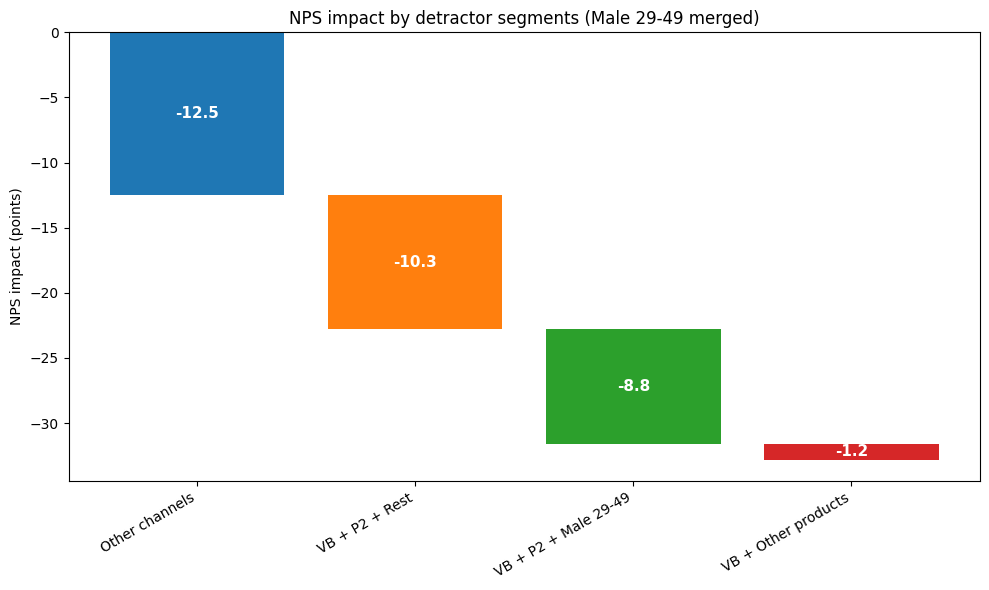

In [108]:
def plot_waterfall(table,title):

    values = table["nps_impact"].values
    labels = table["segment"].values

    fig, ax = plt.subplots(figsize=(10,6))

    cumulative = 0

    for i,val in enumerate(values):

        ax.bar(i,val,bottom=cumulative)

        # подпись на столбце
        ax.text(
            i,
            cumulative + val/2,
            f"{val:.1f}",
            ha="center",
            va="center",
            color="white",
            fontsize=11,
            fontweight="bold"
        )

        cumulative += val

    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels,rotation=30,ha="right")

    ax.set_ylabel("NPS impact (points)")
    ax.set_title(title)

    plt.tight_layout()
    plt.show()

plot_waterfall(
    table_merged,
    "NPS impact by detractor segments (Male 29-49 merged)"
)

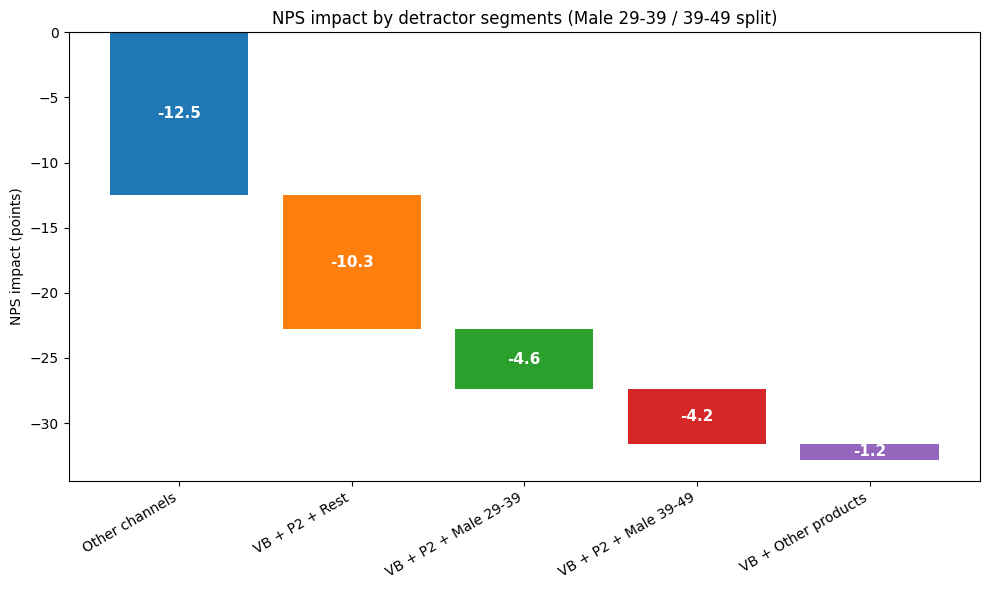

In [107]:
plot_waterfall(
    table_split,
    "NPS impact by detractor segments (Male 29-39 / 39-49 split)"
)

# **Заключение**

Анализ драйверов NPS показал, что основное снижение метрики в канале VoiceBot связано с использованием Product_2. Вклад Product_2 в отклонение NPS канала составляет −13.60 пункта относительно общего baseline.

Дальнейший drill-down внутри сегмента VoiceBot + Product_2 позволил локализовать ключевые источники негативного влияния.

Анализ сегментации Gender × Age показал, что основная часть негативного вклада формируется мужской аудиторией среднего возраста. По диаграмме негативных вкладов видно, что сегмент Male 29–39 формирует около 41.6% всего отрицательного вклада, а сегмент Male 39–49 — около 35.1%. Дополнительный вклад в негатив дают сегменты Male 50+ (около 10%) и Male 26–29 (около 8.9%), тогда как остальные сегменты оказывают значительно меньший эффект.

Таким образом, суммарно мужская аудитория возрастных групп 29–49 формирует большую часть негативного влияния на NPS внутри Product_2.

Анализ временной динамики (Gender × Month) показывает, что негатив распределён по месяцам неравномерно. Наибольший вклад в снижение метрики дают два месяца: September и November. По диаграмме долей негативного вклада видно, что November формирует около 19.3% отрицательного влияния, а September — около 19.1%. Далее следуют July (16.2%) и December (15.8%), тогда как остальные месяцы оказывают меньший вклад.

Дополнительная проверка комбинаций Age × Month показывает, что наиболее негативные комбинации сосредоточены в возрастных группах 29–39 и 39–49 в летне-осенние месяцы. Например, сегмент 29–39 в November даёт вклад около −1.44 пункта NPS, а сегмент 39–49 в July — около −1.23 пункта.

Визуализация этих результатов на бар-диаграммах и круговых диаграммах подтверждает концентрацию негативного эффекта в ограниченном наборе сегментов.

Таким образом, root cause снижения NPS локализуется в следующих сегментах:

• Пол: Male\
• Возраст: 29–39 и 39–49\
• Период: November и September.

Это указывает на структурную проблему пользовательского опыта Product_2 в канале VoiceBot для мужской аудитории среднего возраста, которая усиливается в определённые периоды времени.

# **Сonclusions**

The NPS driver analysis shows that the main decline in the VoiceBot channel is associated with Product_2. The total contribution of Product_2 to the deviation of VoiceBot NPS from the overall baseline equals −13.60 points.

A deeper drill-down inside the VoiceBot + Product_2 segment allowed us to localize the main sources of negative impact.

The Gender × Age segmentation reveals that the majority of the negative contribution is generated by middle-aged male customers. According to the negative contribution chart, the Male 29–39 segment accounts for approximately 41.6% of the total negative contribution, while the Male 39–49 segment contributes about 35.1%.

Additional negative impact comes from the Male 50+ segment (10%) and Male 26-29 (8.9%), whereas other segments contribute significantly less.

Therefore, male customers aged 29–49 generate the majority of the negative NPS pressure within Product_2.

The temporal analysis (Gender × Month) shows that the negative contribution is unevenly distributed across months. Two months generate the largest share of the decline: September and November. According to the contribution share chart, November accounts for approximately 19.3% of the negative impact, while September contributes about 19.1%. These are followed by July (16.2%) and December (15.8%), while other months have smaller contributions.

An additional Age × Month drill-down confirms that the most negative combinations are concentrated in the 29–39 and 39–49 age groups during the summer and autumn months. For example, the 29–39 segment in November contributes approximately −1.44 NPS points, while the 39–49 segment in July contributes around −1.23 points.

The bar charts and pie charts further confirm that the negative impact is concentrated within a limited set of segments.

Overall, the root cause of the NPS decline can be localized in the following segments:

• Gender: Male\
• Age groups: 29–39 and 39–49\
• Time period: November and September

This indicates a structural issue in the customer experience of Product_2 within the VoiceBot channel for middle-aged male customers, which becomes more pronounced during specific time periods.

# **РЕКОМЕНДАЦИИ**

На основе проведённого анализа можно сформулировать следующие рекомендации по улучшению NPS в канале VoiceBot для Product_2.

# **1. Сегмент Male 29–39 (≈41.6% негативного вклада)**

Этот сегмент формирует крупнейший вклад в снижение NPS внутри Product_2.

**Возможные причины:**\
• более сложные типы запросов (финансовые операции, кредиты, сервисные сценарии)\
• более высокие ожидания качества обслуживания\
• низкая терпимость к задержкам и непониманию со стороны VoiceBot

**Рекомендации:**\
• провести анализ пользовательских сценариев обращений этой возрастной группы\
• выявить наиболее частые интенты и улучшить их обработку в VoiceBot\
• добавить быстрый переход на оператора для сложных сценариев\
• протестировать отдельные диалоговые сценарии для финансовых операций

# **2. Сегмент Male 39–49 (≈35.1% негативного вклада)**

Этот сегмент также формирует значительную часть негативного NPS.

**Возможные причины:**\
• сложные сервисные запросы\
• недостаточная точность распознавания интентов\
• более высокие ожидания по скорости решения проблемы

**Рекомендации:**\
• провести анализ логов диалогов VoiceBot для этой аудитории\
• выявить сценарии с высокой долей неуспешных диалогов\
• оптимизировать routing на оператора для проблемных сценариев\
• улучшить подсказки и структуру диалогов

# **3. Периоды November и September (≈19% негативного вклада каждый)**

В эти месяцы наблюдается наибольший вклад в снижение NPS.

**Возможные причины:**\
• изменения или обновления VoiceBot\
• рост нагрузки на канал поддержки\
• изменения в типах пользовательских запросов\
• сезонные операционные факторы

**Рекомендации:**\
• проверить изменения в VoiceBot моделях или сценариях в эти периоды\
• проанализировать логи обращений и распределение интентов\
• проверить нагрузку на поддержку и долю обращений, попадающих в VoiceBot\
• провести анализ пользовательских сценариев в указанные месяцы

# **4. Общая рекомендация**

Поскольку основная проблема сосредоточена в мужской аудитории 29–49 лет, рекомендуется провести отдельный анализ пользовательского пути для этой группы:

• анализ наиболее частых типов запросов\
• анализ неуспешных диалогов\
• анализ переходов к оператору\
• пользовательские исследования (CX интервью)

Это позволит точнее определить продуктовые проблемы VoiceBot и приоритизировать улучшения.

# **RECOMMENDATIONS**

Based on the analysis, the following recommendations can be proposed to improve NPS in the VoiceBot channel for Product_2.

# **1. Segment Male 29–39 (≈41.6% of negative contribution)**

This segment generates the largest share of negative NPS impact within Product_2.

**Possible reasons:**\
• more complex customer requests (financial operations, loans, service scenarios)\
• higher expectations regarding service quality\
• lower tolerance for delays or misunderstanding by VoiceBot

**Recommendations:**\
• analyze customer interaction scenarios for this age group\
• identify the most common intents and improve their handling in VoiceBot\
• introduce faster routing to a human operator for complex cases\
• test improved dialogue scenarios for financial operations

# **2. Segment Male 39–49 (≈35.1% of negative contribution)**\

This segment also contributes significantly to the NPS decline.

**Possible reasons:**\
• complex service requests\
• insufficient intent recognition accuracy\
• higher expectations regarding problem resolution speed

**Recommendations:**\
• analyze VoiceBot dialogue logs for this audience\
• identify scenarios with high failure rates\
• optimize routing to human operators for problematic cases\
• improve dialogue prompts and conversation structure

# **3. Months November and September (≈19% negative contribution each)**

These months show the largest share of the negative impact.

**Possible reasons:**\
• VoiceBot model or scenario updates\
• increased support channel load\
• changes in the types of customer requests\
• seasonal operational factors

**Recommendations:**\
• review VoiceBot updates or configuration changes during these periods\
• analyze request logs and intent distribution\
• review support channel load and VoiceBot routing share\
• analyze customer interaction scenarios during these months

# **4. Overall recommendation**

Since the main issue is concentrated among male customers aged 29–49, it is recommended to conduct a focused analysis of the customer journey for this group:

• analysis of the most frequent request types\
• analysis of failed VoiceBot dialogues\
• analysis of handoffs to human operators\
• CX user interviews

This will help identify the key product issues in VoiceBot and prioritize improvements.